[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T01_A_business_cycle_facts.ipynb)
> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Module 1 — Business cycle facts, from the labour side

**Supplementary course · puremacro**

T01_B built the national accounts and asked what is *in* them. This lesson asks what they say about the **cycle** — and it starts from labour, because almost every business cycle fact is a statement about labour that has been rearranged.

Output per hour is the arithmetic centre of the whole subject: $Y = \dfrac{Y}{H}\cdot\dfrac{H}{E}\cdot E$. Productivity, the length of the working week, and the number of people working. Three margins, one identity, and every recession is a different mixture of the three. Get the denominator wrong — hours instead of heads, or the wrong units — and every second moment downstream is wrong with it.

### Learning Objectives
By the end of this lesson you will be able to:
1. **Measure labour input properly**, for the largest sample the accounts allow: heads and hours from the *same* accounts that measure GDP, with the coverage gaps named rather than hidden — and repair the two countries whose hours are published on the wrong time base, identifying the scale factor from the data rather than assuming it.
2. **Compute labour productivity** $Y/H$ and decompose growth into its three margins, exactly: $\Delta\log Y = \Delta\log(Y/H) + \Delta\log(H/E) + \Delta\log E$, and read what it means that two countries with the same growth rate have opposite decompositions.
3. **Separate trend from cycle** with Hodrick–Prescott and with Hamilton (2018), understand the **Slutsky-Yule spurious cycle effect** and why filter distortions corrupt DSGE/RBC structural calibration (Kydland & Prescott 1982), and find out whether the choice changes an *answer* rather than a number.
4. Compute the **canonical cycle facts** — relative volatility, comovement, persistence, spectral share — as a **distribution across 30-plus countries** rather than a property of one series, and add the two labour margins to the usual list.
5. **Take a recession apart**: decompose the peak-to-trough fall in output into the three margins, country by country, see why Germany and Spain lost the same crisis in opposite ways (*Kurzarbeit* vs. dual EPL), understand why Okun and Beveridge curves are policy-dependent reduced forms (**Lucas Critique**), and execute **Macroeconomic Experiment 1** contrasting the 2008 GFC against the 2020 COVID-19 shock alongside filter distortion stress testing.
6. Ask whether any of it was **knowable at the time**: rebuild the output gap as it stood in every monthly edition of T01_B's real-time archive, for 39 economies — deseasonalizing the archive's 11,503 editions with the same filter as T01_B §4.1 instead of dropping the 501 that arrive raw — and split the revision into the part the filter causes and the part the data cause (Orphanides & van Norden 2002).

Everything runs in pure Python on the four blocks T01_B froze, with no network.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = __import__("pathlib").Path.cwd()


def _here(p):
    # A sandboxed filesystem (iOS) raises PermissionError from .exists()
    # instead of returning False; treat unreadable as absent.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

# The four blocks of quarterly national accounts that T01_B §6 froze: 49
# countries, seasonally adjusted, already on disk. Nothing here touches the
# network.
from _datos import DATOS, gasto, mercado_laboral, volumen
from puremacro.data import hp_filter
from puremacro.cycles import hamilton_filter
from puremacro.spectral import business_cycle_band_power
from puremacro.regress import ols, add_constant

cols = _nbstyle.palette(5)          # most prominent first
HASTA = "2019-12-31"    # 2020 is not a business cycle; see §1.1

## 1. Labour input: the denominator nobody checks

"Productivity" is a ratio, and in macroeconomics the fights are almost always about the denominator. There are two candidates and they are not close substitutes:

$$ \frac{Y}{E} \quad\text{(output per worker)} \qquad\text{versus}\qquad \frac{Y}{H} \quad\text{(output per hour)}. $$

The difference between them is $H/E$, hours per worker — which is not a constant, not a slow-moving constant, and not even acyclical. It is a *margin of adjustment*, and in some countries it is the main one. Germany lost 7.3% of output in 2008–09 with employment slightly **up**; the adjustment went through hours. Measure that recession with $Y/E$ and you conclude German productivity collapsed. Measure it with $Y/H$ and you get a smaller, more honest number.

So this lesson uses **hours**, and the first job is to get them.

**Where they come from, and why it matters that it is the same place.** T01_B's `qna_panel(labor=True)` takes employment and hours from the *same* national accounts that produce GDP — the internal, domestic concept, counting jobs located in the country whether or not the worker lives there, and including the self-employed. That is what makes $Y/H$ a ratio of two things that were measured against each other. A labour force survey would answer a different question (residents in work, on a different reference week, with a different treatment of second jobs), and dividing accounts-GDP by survey-hours produces a number that is nobody's productivity.

The price of that consistency is coverage: **the flow does not cover everyone**, and two of the missing are the two most written-about economies in the field.

In [3]:
lab = mercado_laboral()
gas = gasto()
HAVE_GDP = set(gas.index.get_level_values("code"))

MIN_Q = 40          # ten years: below this the second moments are not worth much


def _long_enough(s, k=MIN_Q):
    return s.notna().sum() >= k


inv = []
for code, s in lab.groupby("code"):
    inv.append({"code": code,
                "gdp": code in HAVE_GDP,
                "heads": _long_enough(s["emp"]),
                "hours": _long_enough(s["hours"]),
                "urate": _long_enough(s["urate"])})
inv = pd.DataFrame(inv).set_index("code")

n_head = int((inv["gdp"] & inv["heads"]).sum())
n_hour = int((inv["gdp"] & inv["hours"]).sum())
n_both = int((inv["gdp"] & inv["heads"] & inv["hours"]).sum())
print(f"Of the {len(inv)} reference areas in the labour block:")
print(f"  {n_head} have GDP and employment (heads)  -> Y/E is available")
print(f"  {n_hour} have GDP and hours               -> Y/H is available")
print(f"  {n_both} have GDP, heads AND hours        -> the three margins are available")
print("\nWhat is missing, and for whom:")
print(f"  heads but no hours: {', '.join(sorted(inv.index[inv['heads'] & ~inv['hours']]))}")
print(f"  hours but no heads: {', '.join(sorted(inv.index[inv['hours'] & ~inv['heads']]))}")
print(f"  neither:            {', '.join(sorted(inv.index[~inv['heads'] & ~inv['hours']]))}")
print("\nThe United States and Japan do not appear in this flow at all. The BEA and "
      "the Cabinet Office\npublish labour input, but not inside the quarterly "
      "national accounts dataflow the OECD\nreplicates — so the country whose "
      "business cycle the literature is written about is the one\nwhere the "
      "accounts cannot tell you how many hours were worked. §1.3 says what to do "
      "about it.")

Of the 42 reference areas in the labour block:
  38 have GDP and employment (heads)  -> Y/E is available
  34 have GDP and hours               -> Y/H is available
  33 have GDP, heads AND hours        -> the three margins are available

What is missing, and for whom:
  heads but no hours: AUS, CHE, KOR, RUS, ZAF
  hours but no heads: CAN
  neither:            CYP, MLT, USA

The United States and Japan do not appear in this flow at all. The BEA and the Cabinet Office
publish labour input, but not inside the quarterly national accounts dataflow the OECD
replicates — so the country whose business cycle the literature is written about is the one
where the accounts cannot tell you how many hours were worked. §1.3 says what to do about it.


### 1.1 Two sample decisions, and both are load-bearing

**Logs.** The cycle is measured in percent, not in pesos, so everything below is $100\log x_t$. A cycle of $-2$ then means "2% below trend" in every country at once, with no exchange rate anywhere near the calculation — the same argument T01_B §2.3 makes about which statistics the exchange rate can and cannot contaminate.

**We stop at 2019Q4.** The 2020 shutdown is not a business cycle: nobody stopped buying because of an interest rate, and no filter that includes it can tell the difference. An HP filter fed 2020 splits that step between trend and cycle and contaminates both, and the damage is not confined to 2020 — the trend it draws through 2020 changes the estimated cycle for years on either side. T01_B §4.3 cuts at the same quarter for the same reason. Exercise 5 makes you take the cut off and look at what happens.

### 1.2 The unit trap: two countries whose hours are off by a factor of 13 and 4

The accounts report hours as **millions of hours worked in the quarter**. That is a claim with an arithmetic consequence: divide by employment and by the 13 weeks in a quarter and you must get a plausible working week. Most of the panel does — and two countries do not, by margins that no labour market could produce: Chile arrives at 3.2 hours a week and Costa Rica at 166.

T01_B §5.1 repairs this before freezing the block, and ships `hours_factor` alongside so the correction travels with the data. **We are not going to take that on trust.** A repair applied upstream and never checked downstream is how a wrong constant survives for years, so the cell below re-derives the factor from scratch — using only the shipped `hours` and `emp` and the arithmetic of the calendar — and asserts that it recovers what was applied.

The argument is worth following, because it is what makes this a repair rather than a fudge. A wrong time base can only be a **ratio of calendar units**: a weekly figure filed as quarterly (×13), an annual one filed as quarterly (×¼), and their inverses. That is four candidates. Requiring the repaired week to land inside a band wide enough to hold every other country in the panel leaves exactly one — the factor is *identified*, not chosen. And then there is the check nobody arranged: two unrelated countries, two different errors, two different factors, and the same 41.4-hour week at the end of it.

In [4]:
WEEKS_PER_QUARTER = 13.0
PLAUSIBLE = (25.0, 50.0)        # hours per week per worker; deliberately wide

#: A wrong time base is a ratio of calendar units, so only a few factors are
#: even candidates. Requiring the repaired week to land inside PLAUSIBLE is
#: what picks between them — the factor is identified by the data, not chosen.
CALENDAR = {13.0: "a weekly figure filed as a quarterly total",
            4.0: "a quarterly figure filed as an annual total",
            0.25: "an annual figure filed as a quarterly total",
            1 / 13.0: "a quarterly figure filed as a weekly total"}


def implied_week(hours, heads):
    """Hours per week per worker, from millions of hours and thousands of people."""
    # sort=True is concat's current default on date indexes; pandas 4 flips it.
    d = pd.concat([hours.rename("h"), heads.rename("e")], axis=1, sort=True).dropna()
    if d.empty:
        return np.nan
    return float(((d["h"] * 1e6) / (d["e"] * 1e3) / WEEKS_PER_QUARTER).median())


# What T01_B applied, and what the series looked like before it did. `hours` in
# the file is already repaired, so the raw figure is hours / hours_factor.
applied = lab["hours_factor"].groupby(level="code").first()
raw_week, now_week = {}, {}
for code in inv.index[inv["heads"] & inv["hours"]]:
    s = lab.loc[code]
    f = float(applied.get(code, 1.0))
    now_week[code] = implied_week(s["hours"], s["emp"])
    raw_week[code] = implied_week(s["hours"] / f, s["emp"])
raw_week = pd.Series(raw_week).dropna().sort_values()
now_week = pd.Series(now_week).dropna()

# Re-derive the factor from the RAW week, knowing nothing about what was applied.
rederived = {}
for code, cruda in raw_week.items():
    if PLAUSIBLE[0] <= cruda <= PLAUSIBLE[1]:
        rederived[code] = 1.0
        continue
    fits = [f for f in CALENDAR if PLAUSIBLE[0] <= cruda * f <= PLAUSIBLE[1]]
    assert len(fits) == 1, f"{code}: {len(fits)} candidate factors, not one"
    rederived[code] = fits[0]
rederived = pd.Series(rederived)

odd = raw_week[(raw_week < PLAUSIBLE[0]) | (raw_week > PLAUSIBLE[1])]
print(f"Implied hours per week per worker, {len(raw_week)} countries. "
      f"As the source published them, {len(raw_week) - len(odd)} sit inside "
      f"{PLAUSIBLE[0]:.0f}-{PLAUSIBLE[1]:.0f} h and {len(odd)} do not:")
for code, v in odd.items():
    f = rederived[code]
    print(f"  {code}: {v:7.1f} h/week  x {f:g}  ->  {v * f:.1f}   ({CALENDAR[f]})")

print(f"\nRe-derived independently, the factors agree with the ones T01_B §5.1 "
      f"applied: {dict(rederived[rederived != 1.0].round(4))} vs "
      f"{dict(applied[applied.notna() & (applied != 1.0)].round(4))}.")
print(f"After the repair the whole panel runs {now_week.min():.1f} "
      f"({now_week.idxmin()}) to {now_week.max():.1f} ({now_week.idxmax()}) "
      f"hours a week.")
print("\nAnd the check the procedure could not have arranged: two unrelated "
      "errors, two\ndifferent factors, and the same working week at the end of "
      "it — " + ", ".join(f"{c} {now_week[c]:.1f} h" for c in odd.index) + ".")

REPAIR = dict(rederived[rederived != 1.0])
assert set(REPAIR) == {"CHL", "CRI"}
# the independent re-derivation must reproduce the shipped correction exactly
assert all(abs(rederived[c] - float(applied.get(c, 1.0))) < 1e-12
           for c in rederived.index)
assert (now_week.between(*PLAUSIBLE)).all()
assert abs(now_week["CHL"] - now_week["CRI"]) < 1.0

Implied hours per week per worker, 33 countries. As the source published them, 31 sit inside 25-50 h and 2 do not:
  CHL:     3.2 h/week  x 13  ->  41.4   (a weekly figure filed as a quarterly total)
  CRI:   165.8 h/week  x 0.25  ->  41.4   (an annual figure filed as a quarterly total)

Re-derived independently, the factors agree with the ones T01_B §5.1 applied: {'CHL': np.float64(13.0), 'CRI': np.float64(0.25)} vs {'CHL': np.float64(13.0), 'CRI': np.float64(0.25)}.
After the repair the whole panel runs 27.2 (NOR) to 43.0 (MEX) hours a week.

And the check the procedure could not have arranged: two unrelated errors, two
different factors, and the same working week at the end of it — CHL 41.4 h, CRI 41.4 h.


### 1.3 What to do about the United States

Nothing honest *with this data and at this frequency*, is the short answer. It is worth stating rather than papering over, and it is also worth not leaving it there: §1.4 comes back at it from the other side and does find something.

The frozen course data does contain US labour input — `HOANBS`, hours of all persons in the **nonfarm business sector** — and it would be easy to divide `GDPC1` by it and put a US row in every table below. That number would be wrong in a specific, knowable direction: the numerator is the whole economy and the denominator is about three-quarters of it, and the quarter that is missing is the one where output is measured *as the sum of its inputs*. General government value added is, by construction in the SNA, compensation plus consumption of fixed capital — so measured productivity growth in that sector is close to zero by definition, not by finding. Splice a business-sector denominator onto a whole-economy numerator and you have quietly deleted the sector that drags the aggregate down.

So the United States and Japan sit out §2 to §5, and appear again in §5.1 and §6, where the object is GDP or unemployment and no hours are needed. The cost is worth naming precisely: the quarterly panel below is 31 countries and it is missing the two the seminar will ask about.

And the *kind* of cost is worth naming too, because §1.4 comes out of it. What fails in the splice is not that the United States lacks a denominator: it is that its denominator covers three-quarters of the economy and the panel's covers the whole of it. A mismatch between two concepts can be fixed from either side, and this section only looks at the bad one.

**How much would the splice have cost? Let us measure it.** "This would be wrong" is a claim, and claims in this course get numbers. The United States is the one country where we can put one on it, because FRED publishes *both* legs of the business-sector pair: `OUTNFB`, nonfarm business output, alongside `HOANBS`, its hours. So we can build the concept-consistent ratio `OUTNFB/HOANBS` and the tempting splice `GDPC1/HOANBS`, and compare them on the same quarters.

The cell below does it, and the answer is not a rounding error — the splice moves both things this lesson is about. It understates productivity *growth*, because the numerator gains a sector whose measured productivity growth is near zero by construction while the denominator does not. And it corrupts the *cyclicality* by far more, in the direction that matters: it would have entered the United States into §3's table as the most countercyclical economy in the panel, well past Spain, on the strength of a denominator that does not belong to its numerator.

> **The same point again, cross-country.** Because the accounts *do* give value added by industry (T01_B §1.8), you can see how big the government effect could be elsewhere. The general-government-and-adjacent branch (`va_public`: public administration, defence, education, health) is 10-22% of value added across this panel. Exercise 6 asks you to do this properly and to say why the raw cross-country correlation between government size and measured productivity growth — which is $-0.39$ here — is *not* the evidence it looks like. §1.4 does the version that is: instead of correlating government size with productivity across countries, it removes the government from each country and looks at how much that country's own number moves.

In [5]:
def _fred(series_id):
    """One frozen FRED series from data_curso, as a dated Series."""
    d = pd.read_csv(DATOS / f"{series_id}.csv", parse_dates=["observation_date"])
    return d.set_index("observation_date")[series_id].dropna()


us = pd.concat([_fred("OUTNFB").rename("business_output"),
                _fred("HOANBS").rename("business_hours"),
                _fred("GDPC1").rename("gdp")], axis=1, sort=True).dropna()

print("What splicing a business-sector denominator onto a whole-economy "
      "numerator does to\nthe United States (nonfarm business, FRED):\n")
for lo, tag in (("1947-01-01", "1947-2019 (the whole series)"),
                ("1995-01-01", "1995-2019 (this lesson's window)")):
    d = us.loc[lo:HASTA]
    y_cycle, _ = hp_filter(100.0 * np.log(d["gdp"]))
    row = []
    for label, num in (("consistent  OUTNFB/HOANBS", d["business_output"]),
                       ("spliced     GDPC1/HOANBS ", d["gdp"])):
        p_cycle, _ = hp_filter(100.0 * np.log(num / d["business_hours"]))
        row.append((label,
                    float(400 * np.log(num / d["business_hours"]).diff().mean()),
                    float(np.corrcoef(np.asarray(y_cycle),
                                      np.asarray(p_cycle))[0, 1])))
    print(f"  {tag}, n = {len(d)}")
    for label, g, c in row:
        print(f"    {label}   growth {g:+.2f}% a year   corr(Y, Y/H) {c:+.2f}")
    print(f"    -> the splice costs {row[1][1] - row[0][1]:+.2f} pp of growth "
          f"and {row[1][2] - row[0][2]:+.2f} of correlation\n")

_d = us.loc["1995-01-01":HASTA]
_yc, _ = hp_filter(100.0 * np.log(_d["gdp"]))
_ok, _ = hp_filter(100.0 * np.log(_d["business_output"] / _d["business_hours"]))
_bad, _ = hp_filter(100.0 * np.log(_d["gdp"] / _d["business_hours"]))
_corr_ok = float(np.corrcoef(np.asarray(_yc), np.asarray(_ok))[0, 1])
_corr_bad = float(np.corrcoef(np.asarray(_yc), np.asarray(_bad))[0, 1])
print(f"Read on this lesson's window, US business-sector productivity is mildly "
      f"COUNTERcyclical\n({_corr_ok:+.2f}) — which is a documented fact about the "
      f"post-1984 United States and not a\nmeasurement artefact: the same "
      f"calculation on 1947-2019 gives a firmly procyclical\nnumber. The splice "
      f"would report {_corr_bad:+.2f} instead, which is past Spain and would make "
      f"the\nUnited States the most countercyclical economy in §3's table. That "
      f"is the difference\nbetween a fact about America and a fact about a "
      f"denominator.")

# The splice is worse than the honest measure on both counts, on both samples.
assert _corr_bad < _corr_ok

What splicing a business-sector denominator onto a whole-economy numerator does to
the United States (nonfarm business, FRED):

  1947-2019 (the whole series), n = 292
    consistent  OUTNFB/HOANBS   growth +2.13% a year   corr(Y, Y/H) +0.41
    spliced     GDPC1/HOANBS    growth +1.87% a year   corr(Y, Y/H) -0.04
    -> the splice costs -0.26 pp of growth and -0.44 of correlation

  1995-2019 (this lesson's window), n = 100
    consistent  OUTNFB/HOANBS   growth +2.09% a year   corr(Y, Y/H) -0.16
    spliced     GDPC1/HOANBS    growth +1.72% a year   corr(Y, Y/H) -0.52
    -> the splice costs -0.37 pp of growth and -0.37 of correlation



Read on this lesson's window, US business-sector productivity is mildly COUNTERcyclical
(-0.16) — which is a documented fact about the post-1984 United States and not a
measurement artefact: the same calculation on 1947-2019 gives a firmly procyclical
number. The splice would report -0.52 instead, which is past Spain and would make the
United States the most countercyclical economy in §3's table. That is the difference
between a fact about America and a fact about a denominator.


### 1.4 The comparable subsample: agriculture out, government out

§1.3 diagnoses and then stops, and stopping was premature. The mismatch is not that the United States lacks a denominator — it is that its denominator is defined over three-quarters of the economy and the panel's over the whole of it. A mismatch between two concepts can be fixed from either side, and §1.3 only looked at the bad one: raising the US numerator to the aggregate. The good one is lowering the panel's. Take away from every other country the same branches the BLS takes away from the United States, and then compare market sector against market sector.

**Which branches, and why those two.** Agriculture (`A`), because nearly all of its labour is self-employed and much of its annual output is the weather. And public administration, education and health (`O–Q`), for the accounting reason §1.3 already laid out and which here turns from argument into instrument: the SNA *defines* that block's value added as compensation plus consumption of fixed capital, so its measured productivity growth sits near zero by construction and not by finding. T01_B §5.3 pulls both from the same flow employment and hours already came from — and with the same seasonal adjustment as the total, because a total adjusted at source minus a raw part is the subtraction of nothing — and writes them into the file.

**And the frequency has to change; there is no way around it.** The United States and Japan return **zero rows** in the quarterly labour flow, with the key left open in all thirteen dimensions and starting in 1990: not an absent branch, not a short sample, nothing. The OECD's annual tables do have them, on the same twelve ISIC groupings. So this is an **annual** panel, and saying so is more honest than a quarterly panel with two borrowed rows: §2 through §5 stay where they are, quarterly and without them, and what this section buys is *growth* accounting — an annual object anyway — for a sample that finally contains them.

Two mechanics, both of them T01_B's lesson applied. The aggregate comes out **by subtraction from the total**, never by summing what is kept, because Japan does not publish sections E, N, S, T or U: summing what remains drops Japan and subtracting what goes keeps it. And the volume is chain-linked here, from previous-year prices, because chain-linked volumes are not additive and an aggregate built by adding them is wrong without saying so.

In [6]:
from _datos import RAMAS_FUERA, actividad_anual, sector_mercado
from puremacro.fetch import chain_volume

ANNUAL = (1996, 2019)      # the lesson's window, in years
MIN_A = 15                 # fifteen years; below that a mean growth rate says nothing


def _prod(m, code, lo=ANNUAL[0], hi=ANNUAL[1]):
    """log(Y/H) for one country over the annual window, or empty if absent."""
    if code not in m.index.get_level_values("code"):
        return pd.Series(dtype=float)
    g = m.loc[code].loc[lo:hi].dropna(subset=["q", "h"])
    if not len(g):
        return pd.Series(dtype=float)
    # A non-positive ratio has no logarithm: it is left missing (this happens to
    # the hours of ALL persons employed in Australia, which come out negative once
    # the branches are subtracted), rather than letting numpy warn and return NaN.
    r = g["q"] / g["h"]
    return np.log(r.where(r > 0))


mkt = sector_mercado()                     # excl. A and O-Q, employee hours
mkt_all = sector_mercado(horas="hours")    # the same with hours of ALL employed
an = actividad_anual()

# The whole economy with the SAME numerator chain-linked here and the SAME
# denominator, so the difference below is the branch and not the method.
tot = pd.DataFrame({"q": chain_volume(an["va_total"], an["va_total_py"]),
                    "h": an["hours_employees"]}).sort_index()

rows = []
for code in sorted(mkt.index.get_level_values("code").unique()):
    p_mkt = _prod(mkt, code)
    if len(p_mkt) < MIN_A:
        continue
    f = {"code": code, "n": len(p_mkt),
         "g_market": float(100 * p_mkt.diff().mean())}
    p_tot = _prod(tot, code)
    if len(p_tot) >= MIN_A:
        f["g_total"] = float(100 * p_tot.diff().mean())
    p_all = _prod(mkt_all, code)
    if len(p_all) >= MIN_A:
        f["g_all_hours"] = float(100 * p_all.diff().mean())
    rows.append(f)
MARKET = pd.DataFrame(rows).set_index("code")
MARKET["government_pp"] = MARKET["g_market"] - MARKET["g_total"]
MARKET["wedge_pp"] = MARKET["g_market"] - MARKET["g_all_hours"]

print(f"Market-sector productivity — the economy less "
      f"{' and less '.join(RAMAS_FUERA)} —,\n{ANNUAL[0]}–{ANNUAL[1]}, % a year:\n")
print(MARKET.sort_values("g_market", ascending=False).round(2).to_string())

# What it is compared against: the countries §1 found with GDP, heads and hours
# quarterly at once, which are the ones §2 builds its panel from.
QUARTERLY = set(inv.index[inv["gdp"] & inv["heads"] & inv["hours"]])
_in = sorted(set(MARKET.index) - QUARTERLY)
_out = sorted(QUARTERLY - set(MARKET.index))
print(f"\n{len(MARKET)} countries. §1's quarterly inventory had "
      f"{len(QUARTERLY)}, and the matching count is just\nthat, a coincidence: "
      f"they are not the same ones. In come {', '.join(_in)}, and out go "
      f"{', '.join(_out)}\non sample length. Among those coming in are the two "
      f"the seminar will ask about.")

_g = MARKET["government_pp"].dropna()
print(f"\nRemoving the two branches RAISES measured productivity in "
      f"{int((_g > 0).sum())} of {len(_g)} countries, median\n{_g.median():+.2f} "
      f"pp and maximum {_g.max():+.2f} ({_g.idxmax()}). That it rises almost "
      f"everywhere is not any old\ncomposition effect: it is the sector whose "
      f"measured productivity growth the SNA pins near\nzero by definition, "
      f"leaving the average.")

assert {"USA", "JPN"}.issubset(MARKET.index)
assert (_g > 0).sum() > 0.7 * len(_g)

Market-sector productivity — the economy less agri and less public —,
1996–2019, % a year:

       n  g_market  g_total  g_all_hours  government_pp  wedge_pp
code                                                             
LVA   24      4.77     4.33         4.69           0.44      0.08
IRL   24      4.03     3.11         4.18           0.92     -0.15
LTU   24      3.97     3.59         4.00           0.39     -0.03
EST   20      3.96     3.55         3.80           0.42      0.17
ROU   24      3.67     2.99         3.74           0.68     -0.07
SVK   24      3.31     3.64         2.94          -0.33      0.38
POL   24      3.05     2.98         3.21           0.07     -0.16
CZE   24      2.81     2.43         2.81           0.39     -0.00
SVN   24      2.64     2.23         2.37           0.41      0.28
ISL   24      2.43     2.10         2.59           0.33     -0.16
BGR   24      2.42     2.27         2.13           0.15      0.29
USA   22      2.00     1.54          NaN          

#### Does it reproduce the concept, or only resemble it?

The above is a definition, and a definition is not a measurement until someone checks it against something that did not use it. Here you can, and for the same reason §1.3 could put a number on the splice: the United States publishes **both legs** of its nonfarm business sector itself, `OUTNFB` and `HOANBS`, built by the BLS from its own sources and its own conventions. If the market sector we have just assembled by subtracting two branches from the OECD accounts were no more than a convenient approximation, it would show against that pair.

The cell compares the two things that matter — mean growth and the year-to-year movement — and puts the whole-economy version alongside, which is the one §1.3 says is biased and in which direction. A preview of what comes out, because it is what makes the comparison useful: **only one of the two things separates the two versions**, and it is not the one you would expect.

In [7]:
_bls = us.resample("YE").mean()
_bls.index = _bls.index.year
p_bls = np.log(_bls["business_output"] / _bls["business_hours"])

# The three series over THE SAME years: if the market one starts a year later
# and is compared against a BLS mean from another window, the difference
# between the two rows below stops being the concept and becomes the calendar.
_us = pd.concat([_prod(mkt, "USA", 1970, 2100).rename("market"),
                 _prod(tot, "USA", 1970, 2100).rename("total"),
                 p_bls.rename("bls")], axis=1, sort=True).dropna()
_d = _us.diff().dropna()

print(f"The United States, annual, {int(_us.index.min())}–{int(_us.index.max())} "
      f"(n = {len(_us)}): the OECD accounts against the\nconcept-consistent BLS "
      f"pair. It is §1.3's question with the roles swapped — there we measured\n"
      f"what happens if you splice; here, whether the concept can be reproduced "
      f"from everyone else's\naccounts.\n")
print(f"  the BLS pair, OUTNFB/HOANBS          "
      f"{100 * _d['bls'].mean():+.2f}% a year")
for label, col in (("market sector (excl. A and O–Q)", "market"),
                   ("whole economy", "total")):
    print(f"  {label:<36s} {100 * _d[col].mean():+.2f}% a year   "
          f"corr(Δ) with the BLS {float(np.corrcoef(_d[col], _d['bls'])[0, 1]):+.3f}   "
          f"s.d. of the difference {100 * (_d[col] - _d['bls']).std():.2f} pp")

print(f"\nRead the table by column, because the two columns say different "
      f"things. The **correlations\nare equal**: both OECD versions track the "
      f"BLS year to year equally well "
      f"({float(np.corrcoef(_d['market'], _d['bls'])[0, 1]):+.2f} each),\nand "
      f"that already says something — removing two branches does not change the "
      f"cycle, because\ngovernment is the most acyclical thing there is and "
      f"agriculture is noise that is not cycle.\nWhat separates them is the "
      f"**level of growth**: the market sector lands "
      f"{abs(100 * (_d['market'] - _d['bls']).mean()):.2f} pp from the BLS\npair "
      f"and the whole economy sits "
      f"{abs(100 * (_d['total'] - _d['bls']).mean()):.2f} pp below it, in exactly "
      f"the direction §1.3 predicted without\nbeing able to measure it. It is the "
      f"same {float(MARKET.loc['USA', 'government_pp']):+.2f} pp as the table "
      f"above, seen now from outside the\naccounts, against a statistical "
      f"apparatus that shares neither source nor conventions with them.")

assert float(np.corrcoef(_d["market"], _d["bls"])[0, 1]) > 0.9
assert abs(100 * (_d["market"] - _d["bls"]).mean()) < 0.15
# and the whole-economy version has to come out worse, which is the claim
assert (abs((_d["market"] - _d["bls"]).mean())
        < abs((_d["total"] - _d["bls"]).mean()))

The United States, annual, 1998–2023 (n = 26): the OECD accounts against the
concept-consistent BLS pair. It is §1.3's question with the roles swapped — there we measured
what happens if you splice; here, whether the concept can be reproduced from everyone else's
accounts.

  the BLS pair, OUTNFB/HOANBS          +2.02% a year
  market sector (excl. A and O–Q)      +2.00% a year   corr(Δ) with the BLS +0.970   s.d. of the difference 0.47 pp
  whole economy                        +1.55% a year   corr(Δ) with the BLS +0.970   s.d. of the difference 0.40 pp

Read the table by column, because the two columns say different things. The **correlations
are equal**: both OECD versions track the BLS year to year equally well (+0.97 each),
and that already says something — removing two branches does not change the cycle, because
government is the most acyclical thing there is and agriculture is noise that is not cycle.
What separates them is the **level of growth**: the market sector lands 0.01 pp

#### The price, with its number

There is a substitution hidden in all of the above, and it is worth bringing into the light before someone else finds it. The labour input above is **employee hours**, not hours of all employed persons, and that was not a methodological choice: it is the only thing the United States and Japan publish by branch. The United States gives hours of all employed persons for the whole economy only, and Japan does not give them at all.

The substitution is not harmless, and exactly why is known: the numerator still contains the output of the self-employed and the denominator has stopped counting their hours. In **levels** that inflates $Y/H$ by the self-employment share. But this section does not read levels, and in **growth rates** the level differences away: what is left is the *drift* of that share, a much smaller object and, above all, a measurable one, because most of the panel publishes both series and it is enough to compute the same table twice.

It is §1.2's move again. A fix that is never checked downstream is how a wrong constant survives for years.

In [8]:
wedge = MARKET.dropna(subset=["wedge_pp"])
print(f"What measuring with employee hours costs. The {len(wedge)} countries "
      f"that publish both, over the\nsame subsample and the same years:\n")
print(f"  median {wedge['wedge_pp'].median():+.2f} pp, interquartile "
      f"{wedge['wedge_pp'].quantile(.25):+.2f} to "
      f"{wedge['wedge_pp'].quantile(.75):+.2f}, correlation between the two "
      f"measures {wedge['g_market'].corr(wedge['g_all_hours']):.3f}")
_worst = wedge["wedge_pp"].abs().sort_values(ascending=False).head(3).index
print("  the three largest: "
      + ", ".join(f"{c} {wedge.loc[c, 'wedge_pp']:+.2f}" for c in _worst))

_share = (100.0 * an["emp_selfemp"] / an["emp"]).dropna()
_drift = {}
for code in wedge.index:
    if code not in _share.index.get_level_values("code"):
        continue
    s = _share.loc[code].loc[ANNUAL[0]:ANNUAL[1]]
    if len(s) >= MIN_A:
        _drift[code] = float(s.iloc[-1] - s.iloc[0])
_drift = pd.Series(_drift)
_r = float(wedge["wedge_pp"].reindex(_drift.index).corr(_drift))
print(f"\nAnd where it comes from is known, with the right sign. Against the "
      f"change in the self-employment\nshare between {ANNUAL[0]} and "
      f"{ANNUAL[1]}, corr = {_r:+.2f} over {len(_drift)} countries: if the share "
      f"falls, employee hours\ngrow faster than everyone's, productivity "
      f"measured with them grows less, and the wedge comes\nout negative — "
      f"exactly what the algebra predicts. Where the share barely moves, the "
      f"substitution\ndifferences away. Greece moves it "
      f"{_drift.get('GRC', float('nan')):+.1f} points and is the worst in the "
      f"table, which is the\ncoincidence you want to see when you claim to know "
      f"the mechanism.")

assert wedge["wedge_pp"].abs().median() < 0.25
assert wedge["g_market"].corr(wedge["g_all_hours"]) > 0.95

What measuring with employee hours costs. The 30 countries that publish both, over the
same subsample and the same years:

  median -0.07 pp, interquartile -0.16 to +0.02, correlation between the two measures 0.988
  the three largest: GRC -0.89, MEX -0.39, SVK +0.38

And where it comes from is known, with the right sign. Against the change in the self-employment
share between 1996 and 2019, corr = +0.59 over 30 countries: if the share falls, employee hours
grow faster than everyone's, productivity measured with them grows less, and the wedge comes
out negative — exactly what the algebra predicts. Where the share barely moves, the substitution
differences away. Greece moves it -13.7 points and is the worst in the table, which is the
coincidence you want to see when you claim to know the mechanism.


#### What §1.4 buys and what it does not

**It buys growth accounting with the United States and Japan inside**, measured on the same concept as everyone else rather than a borrowed one, and with the check that the concept is the one the United States publishes for itself. It also buys the honest version of §1.3's argument: the government effect stops being a claim about an SNA convention and becomes a shift measured country by country, each country against itself, which is the comparison exercise 6 asks for and the raw cross-country correlation is not.

**It does not buy the cycle, and there is a hint as to why in the validation itself**: the two US versions — market sector and whole economy — track the BLS pair year to year exactly as well as each other, and separate only in the level of growth. A composition change that moves a mean a lot can leave a cyclical correlation untouched, because the branches removed weigh little in the variance of the cycle. §3 and §4 would be measured here on twenty-five annual observations, and a cyclical correlation estimated from twenty-five points with an HP filter is not a fact, it is an anecdote with a standard deviation. So §2 to §5 stay quarterly and stay without Japan, which has no quarterly labour input by any route. The United States *could* now enter there with the BLS pair, since we know its concept is the panel's; exercise 14 asks you to do it and to decide whether the fact that comes out — its mildly countercyclical productivity — survives the panel being measured the way it is.

And one more thing worth looking at twice. That the US market-sector figure matches the BLS **does not validate anyone else's level**: it validates the procedure in the one country where there is something to check it against. The others inherit the validation by construction, not by verification, and that is exactly as much confidence as it sounds.

## 2. Productivity, and the three margins of output

With hours in hand the identity is exact and worth writing out:

$$ Y \;=\; \underbrace{\frac{Y}{H}}_{\text{productivity}} \times \underbrace{\frac{H}{E}}_{\text{hours per worker}} \times \underbrace{E}_{\text{employment}}, \qquad \Delta\log Y = \Delta\log\frac{Y}{H} + \Delta\log\frac{H}{E} + \Delta\log E. $$

It is an identity, so it holds to machine precision, and the cell below checks that rather than asserting it — the same discipline T01_B applies to $Y = C + I + G + NX$. What is *not* an identity is the economics: the same $\Delta\log Y$ can be produced by any mixture of the three, and which mixture a country uses is one of the most persistent things about it.

In [9]:
def labour_frame(code, hasta=HASTA):
    """Output, hours and heads for one country, on one index, repaired."""
    if code not in HAVE_GDP or code not in lab.index.get_level_values("code"):
        return pd.DataFrame()
    s = lab.loc[code]
    d = pd.concat([
        volumen("gdp", code).rename("y"),
        volumen("cons_hh", code).rename("c"),
        volumen("inv", code).rename("i"),
        s["hours"].rename("h"),          # already on hours-per-quarter: §1.2
        s["emp"].rename("e"),
    ], axis=1, sort=True)
    if hasta:
        d = d.loc[:hasta]
    return d


_built = {c: labour_frame(c).dropna(subset=["y", "h", "e"])
          for c in sorted(HAVE_GDP & set(lab.index.get_level_values("code")))}
PANEL = {c: d for c, d in _built.items() if len(d) >= MIN_Q}
CODES = sorted(PANEL)

# Who did not make it, and why. A country that silently vanishes between one
# section and the next is how a panel quietly becomes a convenience sample.
_thin = {c: len(d) for c, d in _built.items() if 0 < len(d) < MIN_Q}
_none = [c for c, d in _built.items() if len(d) == 0]
print(f"Cycle panel: {len(PANEL)} countries with output, hours and heads on a "
      f"common index of at least {MIN_Q} quarters to {HASTA[:4]}Q4.")
if _thin:
    print("  too short once the 2019Q4 cut is applied: "
          + ", ".join(f"{c} ({n}q)" for c, n in sorted(_thin.items())))
    print("  — Costa Rica is the one to notice: §1.2 repaired it on its full "
          "63-quarter\n    sample, and it is the 2019Q4 cut, not the repair, "
          "that takes it out of the cycle panel.")
if _none:
    print(f"  no overlapping hours and heads at all: {', '.join(_none)}")

rows = []
for c in CODES:
    d = PANEL[c]
    ly, lh, le = np.log(d["y"]), np.log(d["h"]), np.log(d["e"])
    rows.append({
        "code": c, "n": len(d),
        "from": d.index[0].to_period("Q"), "to": d.index[-1].to_period("Q"),
        "g_y": float(400 * ly.diff().mean()),
        "g_prod": float(400 * (ly - lh).diff().mean()),
        "g_hours": float(400 * (lh - le).diff().mean()),
        "g_emp": float(400 * le.diff().mean()),
        "h_per_week": implied_week(d["h"], d["e"]),
    })
growth = pd.DataFrame(rows).set_index("code")
growth["residual"] = (growth["g_prod"] + growth["g_hours"] + growth["g_emp"]
                      - growth["g_y"])

print(f"Growth accounting, {len(growth)} countries, % a year, to "
      f"{growth['to'].max()}:")
# 'from' and 'to' are quarters (Period): round only the numeric columns.
_table = growth.drop(columns="residual").sort_values("g_y", ascending=False)
print(_table.round({c: 2 for c in _table.select_dtypes("number")}).to_string())
print(f"\nThe identity closes to {growth['residual'].abs().max():.1e} — it is "
      f"arithmetic, not a regression.")
assert growth["residual"].abs().max() < 1e-9

Cycle panel: 31 countries with output, hours and heads on a common index of at least 40 quarters to 2019Q4.
  too short once the 2019Q4 cut is applied: CHL (28q), CRI (38q)
  — Costa Rica is the one to notice: §1.2 repaired it on its full 63-quarter
    sample, and it is the 2019Q4 cut, not the repair, that takes it out of the cycle panel.
  no overlapping hours and heads at all: AUS, CAN, CHE, KOR, RUS, USA, ZAF


Growth accounting, 31 countries, % a year, to 2019Q4:
        n    from      to   g_y  g_prod  g_hours  g_emp  h_per_week
code                                                               
IRL   100  1995Q1  2019Q4  5.47    4.11    -0.57   1.92       34.17
LTU   100  1995Q1  2019Q4  4.23    4.25     0.24  -0.26       36.13
POL   100  1995Q1  2019Q4  4.09    3.69    -0.15   0.54       39.84
ISR   100  1995Q1  2019Q4  3.78    1.57    -0.29   2.50       37.82
EST    82  1998Q2  2019Q4  3.75    4.10    -0.79   0.43       36.75
LVA   100  1995Q1  2019Q4  3.71    4.16    -0.48   0.02       39.35
SVK   100  1995Q1  2019Q4  3.63    3.41    -0.42   0.63       34.20
ISL   100  1995Q1  2019Q4  3.22    2.30    -0.68   1.60       30.62
LUX   100  1995Q1  2019Q4  3.19    0.33    -0.31   3.17       30.16
NZL    44  2009Q1  2019Q4  3.08    1.15    -0.10   2.02       33.20
ROU   100  1995Q1  2019Q4  2.92    4.07    -0.06  -1.08       35.19
SVN    96  1996Q1  2019Q4  2.66    2.43    -0.37   0.60       

### Reading the decomposition

**The same growth rate is not the same event.** Mexico grew 1.7% a year over 2005-2019 with productivity growth of $-0.2\%$: all of it, and slightly more than all of it, came from putting more people to work. Czechia grew 2.6% with productivity growth of 2.5% and essentially no employment growth. These are opposite economies wearing the same headline number, and no amount of staring at $\Delta\log Y$ would tell them apart.

**Hours per worker fall almost everywhere.** The middle column is negative in most of the panel: the working week has been shortening for thirty years, at a few tenths of a percent a year. It is small, it is slow, and it is exactly the term that $Y/E$ mistakes for productivity.

**Some countries grew while shedding workers.** Romania's employment fell 1.1% a year while its output rose 2.9% — emigration and demography running against a strong catch-up in productivity. Bulgaria and Lithuania are in the same position. When you see productivity growth above output growth, that is what it means.

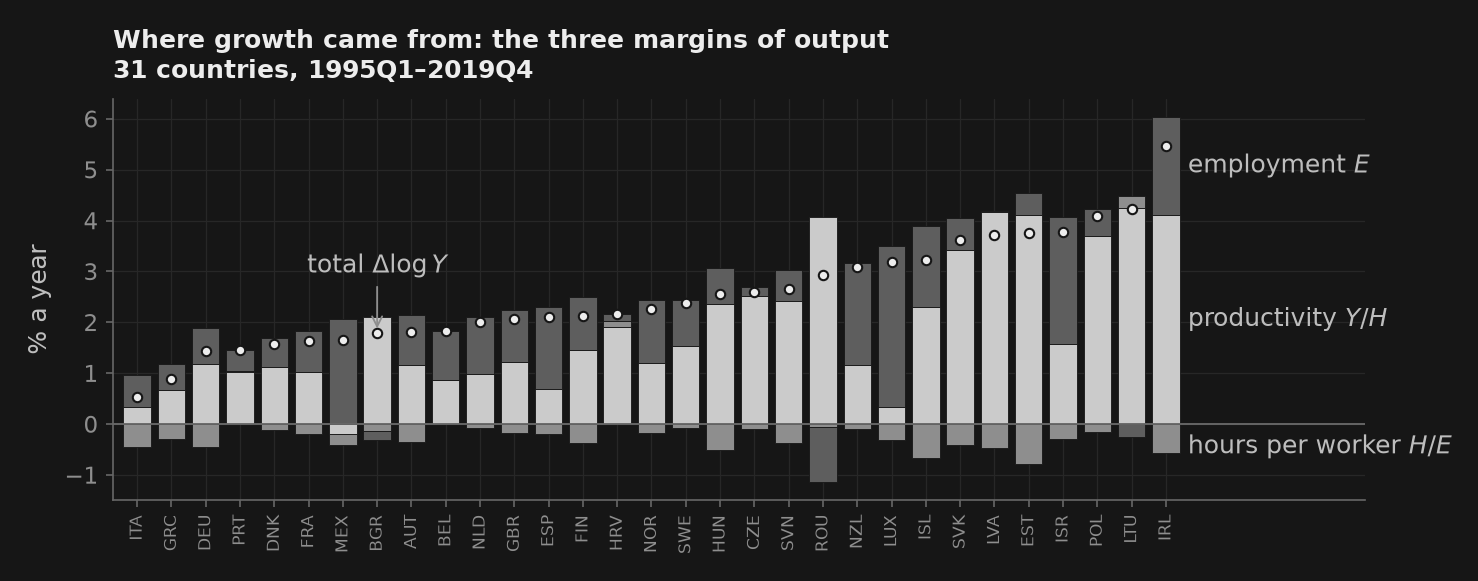

In [10]:
fig, ax = _nbstyle.figura(figsize="ancho")
g = growth.sort_values("g_y")
x = np.arange(len(g))
bottom_pos = np.zeros(len(g))
bottom_neg = np.zeros(len(g))
PARTS = (("g_prod", "productivity $Y/H$", _nbstyle.BARRA_COLORES[0]),
         ("g_hours", "hours per worker $H/E$", _nbstyle.BARRA_COLORES[1]),
         ("g_emp", "employment $E$", _nbstyle.BARRA_COLORES[2]))
centres = {}                      # the centre of each segment in the last bar
for key, label, col in PARTS:
    v = g[key].to_numpy()
    base = np.where(v >= 0, bottom_pos, bottom_neg)
    ax.bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    centres[label] = base[-1] + v[-1] / 2.0
    bottom_pos = bottom_pos + np.where(v >= 0, v, 0.0)
    bottom_neg = bottom_neg + np.where(v < 0, v, 0.0)
ax.plot(x, g["g_y"].to_numpy(), "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=4.5, zorder=5)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(g.index, rotation=90, fontsize=8.4)
ax.set_ylabel("% a year")
ax.set_title("Where growth came from: the three margins of output\n"
             f"{len(g)} countries, {g['from'].min()}–{g['to'].max()}")
# The names next to the segments of the last bar (the tallest) and next to one
# dot, instead of a legend.
ax.set_xlim(-0.7, len(g) + 4.8)
for label, y in centres.items():
    # A negative segment hangs below the zero line: its name goes down with it.
    ax.annotate(label, xy=(x[-1] + 0.4, y), xytext=(4, 0 if y >= 0 else -4),
                textcoords="offset points", ha="left", va="center", color=_nbstyle.TEXTO)
i = len(g) // 4
ax.annotate("total $\\Delta\\log Y$", xy=(x[i], g["g_y"].iloc[i]), xytext=(0, 26),
            textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TEXTO,
            arrowprops=_nbstyle.FLECHA)
plt.show()


### 2.1 Fifty years of growth, twenty-five of cycle

The accounting above covers twenty-five years, because that is the span the current national accounts tables publish. It is long enough to measure a growth rate and much too short to see an economy change.

Two countries in this panel have an archived history that reaches further, and they are the two whose postwar records are most worth having. Spain's quarterly accounts go back to **1970**, Japan's to **1960** — not in today's tables, but in editions of the OECD's archive that were current once. Rebuilding those series is one operation: the older edition and the newer one overlap for a few years, their ratio over the overlap is the constant that reconciles two price bases and two methodologies, and applying it carries the old vintage's **growth rates** onto the current vintage's levels. `ratio_splice` does it and reports how nearly constant that ratio actually was, which is the warranty on the join.

**What that buys, and what it does not.** It buys the trend. Two editions of the same fifteen Spanish years agree on cumulative growth to within half a percentage point, so an archived vintage is a dependable witness to where an economy went. It does **not** buy the cycle: those same two editions disagree about quarterly volatility by a factor of about 1.8, and their quarter-to-quarter movements correlate around one half. Second moments are the first thing a statistical office revises and the last thing it settles, so the volatility of an old edition is partly a property of the edition. Everything below is therefore about **growth over decades**, and the statistics of §3, §4 and §5 stay on the twenty-five years where one vintage covers every country at once.

In [11]:
from puremacro.fetch.longpanel import ratio_splice

ARCHIVE = DATOS / "oecd_stes_vintages_gdp.csv.gz"
LARGO = {"ESP": "Spain", "JPN": "Japan"}

_arch = pd.read_csv(ARCHIVE, dtype={"edition": str})
_arch["date"] = pd.PeriodIndex(_arch["date"].astype(str), freq="Q").to_timestamp()


def long_real_gdp(code):
    """Real GDP as far back as the archive reaches, in one splice.

    Spine: the newest edition, whose levels are kept exactly. Older segment:
    the edition whose series starts earliest — the deepest history the OECD
    ever published for this country. `ratio_splice` refuses a join it cannot
    estimate, so a returned series is one whose seam was checked.
    """
    d = _arch[_arch["code"] == code]
    piv = d.pivot_table(index="date", columns="edition", values="value").sort_index()
    starts = {e: piv[e].dropna().index.min() for e in piv.columns}
    newest = max(piv.columns)
    deepest = min(starts, key=lambda e: (starts[e], e))
    return ratio_splice([(newest, piv[newest].dropna()),
                         (deepest, piv[deepest].dropna())])


gdp_long, seam_long = {}, []
for code in LARGO:
    res = long_real_gdp(code)
    gdp_long[code] = res.series.loc[:HASTA]
    for s in res.seams:
        seam_long.append({"code": code, "older": s.older, "newer": s.newer,
                          "seam": s.date.to_period("Q"), "overlap": s.overlap_n,
                          "drift %": 100.0 * s.ratio_drift, "stable": s.stable})

print("Real GDP, spliced back to the deepest edition the archive holds:\n")
print(pd.DataFrame(seam_long).to_string(index=False,
                                        float_format=lambda v: f"{v:.3f}"))
for code, s in gdp_long.items():
    print(f"  {LARGO[code]:6s} {s.index.min().to_period('Q')}-"
          f"{s.index.max().to_period('Q')}, {len(s)} quarters "
          f"({len(s) - 100} more than the common panel)")
assert all(r["stable"] for r in seam_long)

Real GDP, spliced back to the deepest edition the archive holds:

code  older  newer   seam  overlap  drift %  stable
 ESP 199907 202608 1995Q1       16    0.329    True
 JPN 199907 202608 1994Q1       21    1.042    True
  Spain  1970Q1-2019Q4, 200 quarters (100 more than the common panel)
  Japan  1960Q1-2019Q4, 240 quarters (140 more than the common panel)


### The two facts a long sample gives you

**Japan did not slow down. It stopped, twice.** Average growth by decade runs 9.7%, 4.7%, 3.8%, 1.4%, 0.5%, 1.0%. The first number and the fifth differ by a factor of eighteen, and no part of that is visible in a sample beginning in 1995 — which contains only the last two. Split the history where the data want it split, by the least-squares criterion that picks the break minimising residual variance around two means, and it lands on **1973Q2**: the oil shock, chosen by the series rather than imposed on it. Before it, 9.1% a year; after it, 1.9%. Japan ends the sample eight times its 1960 size, and well over half of that multiple was earned in the thirteen years before the break.

**Spain's growth is nearly all in the past.** Its decades run 3.5%, 2.8%, 2.5%, 2.4%, 1.1% — a gentler decline, and one that hides the real structure. The same break search puts Spain's discontinuity at **2008Q1**, and the arithmetic on either side is stark: three-quarters of the sample lies before that quarter and carries almost all of the growth. Spain's economy is a little over three times its 1970 size, and it reached almost all of that multiple before the financial crisis.

Neither fact is a business cycle statistic. Both are the sort of thing a course that measures cycles on twenty-five years of data should know it cannot see.

In [12]:
rows = []
for code, s in gdp_long.items():
    g = 400.0 * np.log(s).diff().dropna()
    by_dec = g.groupby((g.index.year // 10) * 10).mean()
    rows.append(pd.Series(by_dec, name=LARGO[code]))
decades = pd.DataFrame(rows).sort_index(axis=1)
print("Mean annualised quarterly growth, % a year, by decade:\n")
print(decades.round(1).to_string())


def quandt(g, min_side=40):
    """The break minimising the residual variance around two means."""
    best, arg = np.inf, None
    for i in range(min_side, len(g) - min_side):
        a, b = g.iloc[:i], g.iloc[i:]
        ssr = float(((a - a.mean()) ** 2).sum() + ((b - b.mean()) ** 2).sum())
        if ssr < best:
            best, arg = ssr, i
    return arg


print("\nWhere the series itself puts the break:\n")
for code, s in gdp_long.items():
    g = 400.0 * np.log(s).diff().dropna()
    k = quandt(g)
    before, after = g.iloc[:k], g.iloc[k:]
    tot = float(np.log(s.iloc[-1] / s.iloc[0]))
    pre = float(np.log(s.loc[g.index[k]] / s.iloc[0]))
    print(f"  {LARGO[code]}: {g.index[k].to_period('Q')} — "
          f"{before.mean():.1f}% a year before ({len(before)} quarters), "
          f"{after.mean():.1f}% after ({len(after)} quarters)")
    print(f"     the economy ends {np.exp(tot):.2f}x its "
          f"{s.index.min().year} size, and {100 * pre / tot:.0f}% of that was "
          f"reached before the break")

assert decades.loc["Japan"].iloc[0] > 3 * decades.loc["Japan"].iloc[-1]

Mean annualised quarterly growth, % a year, by decade:

date   1960  1970  1980  1990  2000  2010
Spain   NaN   3.5   2.8   2.5   2.4   1.1
Japan   9.7   4.7   3.8   1.4   0.5   1.0

Where the series itself puts the break:

  Spain: 2008Q1 — 3.1% a year before (151 quarters), 0.6% after (48 quarters)
     the economy ends 3.41x its 1970 size, and 94% of that was reached before the break
  Japan: 1973Q2 — 9.1% a year before (52 quarters), 1.9% after (187 quarters)
     the economy ends 8.02x its 1960 size, and 57% of that was reached before the break


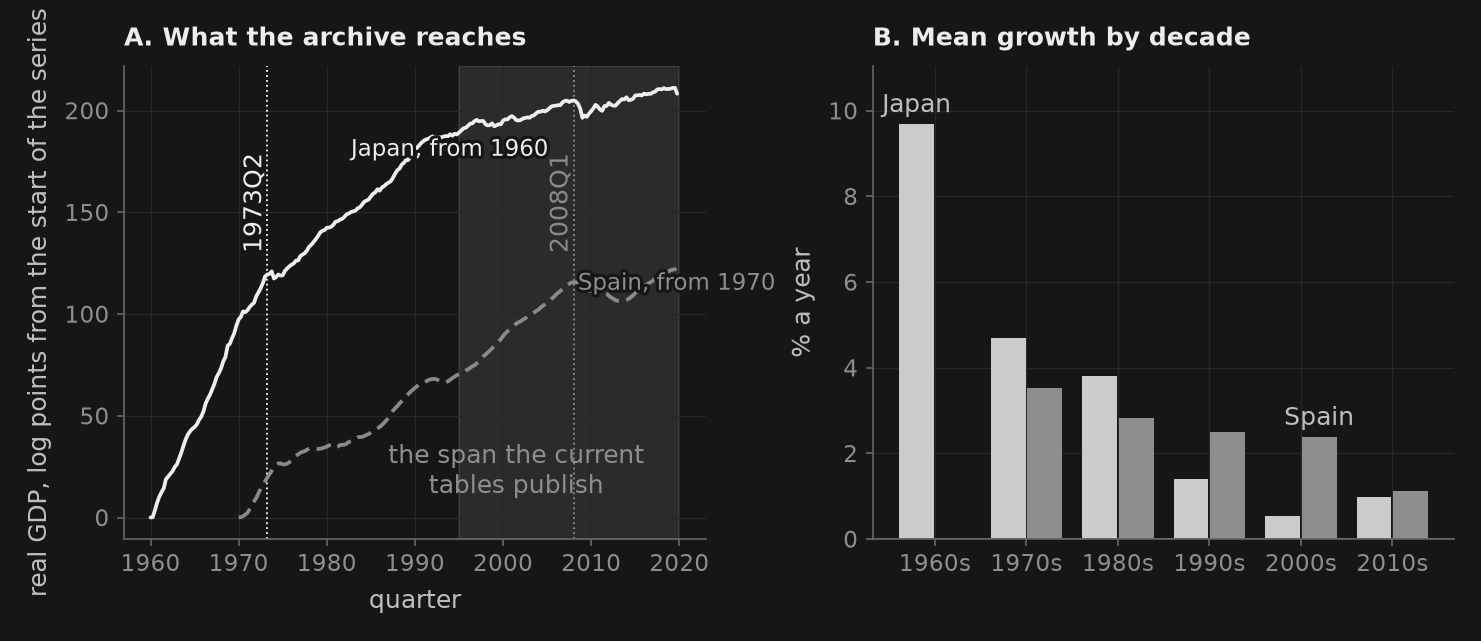

In [13]:
fig, (axL, axR) = _nbstyle.figura(1, 2)

for code, col, ls in (("JPN", cols[0], "-"), ("ESP", cols[3], (0, (4, 2)))):
    s = gdp_long[code]
    axL.plot(s.index, 100.0 * np.log(s / s.iloc[0]), color=col, lw=1.8, ls=ls,
             label=f"{LARGO[code]}, from {s.index.min().year}")
axL.axvspan(pd.Timestamp("1995-01-01"), pd.Timestamp(HASTA), color=_nbstyle.RECESION, zorder=0)
axL.annotate("the span the current\ntables publish",
             xy=(pd.Timestamp("2001-07-01"), 12), color=_nbstyle.NOTA, ha="center")
for code, col in (("JPN", cols[0]), ("ESP", cols[3])):
    g = np.log(gdp_long[code]).diff().dropna()
    b = g.index[quandt(400.0 * g)]
    axL.axvline(b, color=col, lw=0.9, ls=":", zorder=1)
    # The break date above both series and left of its line: lower down it
    # crossed Spain's series and the note on the published span.
    axL.annotate(f"{b.to_period('Q')}", xy=(b, 130), color=col,
                 ha="right", rotation=90, va="bottom")
axL.set_ylabel("real GDP, log points from the start of the series")
axL.set_xlabel("quarter")
axL.set_title("A. What the archive reaches")

w = decades.T
x = np.arange(len(w))
axR.bar(x - 0.2, w["Japan"], 0.38, color=_nbstyle.BARRA_COLORES[0])
axR.bar(x + 0.2, w["Spain"], 0.38, color=_nbstyle.BARRA_COLORES[1])
axR.axhline(0, color=_nbstyle.SPINE, lw=0.9)
axR.set_axisbelow(True)
axR.set_xticks(x); axR.set_xticklabels([f"{int(d)}s" for d in w.index])
axR.set_ylabel("% a year")
axR.set_title("B. Mean growth by decade")
axR.margins(y=0.14); axR.set_ylim(bottom=0)
# Each country's name above one of its bars: Japan above its first decade,
# Spain above the decade where it stands out most.
i_j = int(np.flatnonzero(w["Japan"].notna())[0])
i_s = int(np.nanargmax((w["Spain"] - w["Japan"]).to_numpy()))
for country, dx, i in (("Japan", -0.2, i_j), ("Spain", 0.2, i_s)):
    axR.annotate(country, xy=(x[i] + dx, w[country].iloc[i]), xytext=(0, 3),
                 textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TEXTO)
_nbstyle.etiquetar(axL)
plt.show()


## 3. Trend and cycle — and whether the filter changes an answer

A macro series $y_t$ mixes a slow **trend** $\tau_t$ and a **cycle** $c_t = y_t - \tau_t$. Cycle analysis is about $c_t$: its volatility, its comovement, its persistence. The hard part is defining $\tau_t$, and there is no agreed answer.

- **Hodrick–Prescott:** pick $\tau_t$ to trade off fit against smoothness, governed by $\lambda$ (1600 for quarterly data).
- **Hamilton (2018):** regress $y_{t+h}$ on its own recent lags; the residual is the cycle. Hamilton's paper is called "Why You Should Never Use the Hodrick-Prescott Filter", and his charge is specific: HP manufactures cyclical dynamics that are not in the data, so facts derived from it can be artefacts of the filter.
- **First differences:** no trend model at all. Crude, and free of both critiques.

### Why filter choice matters: The Slutsky-Yule effect and DSGE structural calibration
Why does this econometric dispute matter so deeply for macroeconomics?
1. **The Slutsky-Yule Spurious Cycle Effect:** Eugen Slutsky (1937) and Udny Yule (1927) proved that applying linear filters (such as moving averages or differences) to serially uncorrelated white noise or random walks endogenously generates periodic, sinusoidal fluctuations — creating "spurious cycles" out of uncyclical noise. Cogley and Nason (1995) demonstrated that the HP filter's transfer function $|H(e^{-i\omega})|^2$ artificially concentrates spectral power at business-cycle frequencies (6 to 32 quarters) when applied to difference-stationary $I(1)$ processes like log GDP. A pure unit root process with drift filtered by HP mimics a genuine economic cycle!
2. **Corrupted Structural Calibration in RBC and DSGE Models:** Ever since Kydland and Prescott (1982), the standard methodology in quantitative macroeconomics has been moment matching: researchers calibrate structural parameters (the Frisch elasticity of labor supply $\nu$, consumption habit persistence $b$, or capital adjustment costs $\kappa$) so that simulated model variables match the second moments of HP-filtered empirical data ($\sigma_c/\sigma_y$, autocorrelation, lead-lag covariances). If the two-sided HP filter imparts artificial persistence or shifts phase relationships, structural parameters will be tuned to fit *filtering artifacts* rather than true economic propagation mechanisms.

The usual way to present this is to plot two cycles that look slightly different and move on. That settles nothing. The honest test is whether the filter changes an **answer**, so we pick a fact that has one — *is productivity procyclical?* — and ask all three filters, in every country.

It matters because the answer is a claim about the world. Procyclical measured productivity is the observation behind labour hoarding, variable capacity utilisation, and a good part of the case for and against technology-driven cycles: if productivity rises in booms, either technology is causing the boom, or firms are holding idle workers in slumps and measured productivity is picking up the slack rather than the technology.

In [14]:
def three_filters(s):
    """(HP, Hamilton, first difference) cycles of one log series."""
    s = s.dropna()
    hp, _ = hp_filter(s)
    ham, _ = hamilton_filter(s)
    return (pd.Series(np.asarray(hp), index=s.index),
            pd.Series(np.asarray(ham), index=s.index),
            s.diff())


def cyclicality(code):
    """corr(cycle of output, cycle of productivity) under each filter."""
    d = PANEL[code]
    ly = 100.0 * np.log(d["y"])
    lp = ly - 100.0 * np.log(d["h"])
    out = {"code": code, "n": len(d)}
    for name, fy, fp in zip(("HP", "Hamilton", "difference"),
                            three_filters(ly), three_filters(lp)):
        j = pd.concat([fy.rename("y"), fp.rename("p")], axis=1, sort=True).dropna()
        out[name] = float(j["y"].corr(j["p"])) if len(j) > 8 else np.nan
    return out


cyc = pd.DataFrame([cyclicality(c) for c in CODES]).set_index("code")
F3 = ["HP", "Hamilton", "difference"]
cyc["spread"] = cyc[F3].max(axis=1) - cyc[F3].min(axis=1)

all_pos = (cyc[F3] > 0).all(axis=1)
all_neg = (cyc[F3] < 0).all(axis=1)
flips = ~(all_pos | all_neg)
print("Is measured productivity procyclical? corr(cycle of Y, cycle of Y/H)\n")
print(cyc.sort_values("HP").round(2).to_string())
print(f"\nmedian: " + ", ".join(f"{k} {cyc[k].median():+.2f}" for k in F3))
print(f"positive under ALL three filters: {int(all_pos.sum())} of {len(cyc)}")
print(f"negative under ALL three filters: {int(all_neg.sum())} "
      f"({', '.join(cyc.index[all_neg])})")
print(f"sign depends on the filter:       {int(flips.sum())} "
      f"({', '.join(cyc.index[flips])})")
print(f"largest spread across filters:    {cyc['spread'].max():.2f} "
      f"({cyc['spread'].idxmax()}); median spread {cyc['spread'].median():.2f}")

assert int(all_pos.sum()) > 0.8 * len(cyc)

Is measured productivity procyclical? corr(cycle of Y, cycle of Y/H)

        n    HP  Hamilton  difference  spread
code                                         
ESP   100 -0.26     -0.32       -0.14    0.18
PRT   100  0.14     -0.01        0.16    0.17
NZL    44  0.36     -0.24        0.29    0.59
NOR   100  0.36      0.18        0.76    0.57
EST    82  0.37      0.63        0.46    0.27
POL   100  0.38      0.22        0.70    0.48
ISL   100  0.43      0.38        0.73    0.34
DNK   100  0.46      0.60        0.49    0.14
ISR   100  0.52      0.53        0.24    0.29
NLD    96  0.56      0.55        0.48    0.08
LVA   100  0.58      0.73        0.63    0.15
AUT   100  0.62      0.70        0.29    0.41
ITA    96  0.63      0.44        0.44    0.18
FRA   100  0.63      0.59        0.81    0.22
BEL   100  0.65      0.55        0.65    0.11
SWE   100  0.69      0.62        0.72    0.10
LTU   100  0.70      0.80        0.60    0.20
GBR   100  0.71      0.68        0.59    0.12
IRL   100 

### The verdict on the filter, and on Spain

**Hamilton is right about the number and wrong about the worry.** The three filters disagree by a median of 0.18 and by as much as 0.59 in the worst case, so anyone quoting `corr` to two decimals is quoting the filter as much as the data. But the *sign* — which is what the fact actually is — survives in 29 of 31 countries — 28 positive and Spain negative — and only two countries change their answer depending on how you detrend. Procyclical productivity is not an HP artefact.

**Spain is the exception, and it is not a filter artefact either**: negative under all three. That is a real and famous property of the Spanish cycle, and §5 explains it in one line — Spain adjusts on employment more violently than any other country in the panel, and the jobs it destroys first are the least productive ones. Measured productivity therefore *rises* in Spanish recessions, for a reason that has nothing to do with technology and everything to do with composition. Hold on to it: it is the cleanest available warning that "productivity" measured as a ratio is a statement about the denominator too.

#### The two countries that "depend on the filter", resolved

Leaving Portugal and New Zealand labelled *the filter decides* would be a shrug where a diagnosis is available, and they turn out to be two different situations wearing the same label.

**Portugal is not a flip.** All three filters put the correlation within $0.16$ of zero. Nothing changes sign in any meaningful way; a point estimate sitting on zero crosses it when you nudge it, and reporting that as "the answer depends on the filter" dresses up a country whose measured productivity is simply **acyclical** as a methodological controversy. The honest statement is $\mathrm{corr} \approx 0$.

**New Zealand is a data problem, and it announces itself.** Not on any single diagnostic — Romania and Estonia have noisier hours by the raw standard deviation — but on the combination of three, all computed below. Its labour sample is the **shortest in the panel**: 44 quarters starting in 2009, so it contains one expansion and no recession, and a cyclicality estimated without a downturn is estimated on nothing. Its hours are $2.3\times$ the panel's median volatility, with 16% of quarters moving more than 3%. And its first autocorrelation of $\Delta\log H$ is $-0.51$, the **most negative in the panel** — the signature of measurement error in the *level* of a series, because an error that is transient in levels becomes a sawtooth in differences, up one quarter and back the next. Real labour input does not behave like that.

So the spread of $0.59$ across filters is not three methods disagreeing about New Zealand. It is an estimate with nothing behind it, moving when you touch it. That is a finding, and the right thing to report — but only for this country: across the panel as a whole the correlation between how noisy a country's hours are and how much its answer moves with the filter is only $0.19$, so **noise is New Zealand's explanation, not a general law**. Two of thirty-one countries cannot be answered from these data, and thirty-one minus two is still the fact.

In [15]:
_noise = []
for code in CODES:
    dh = (100.0 * np.log(PANEL[code]["h"])).diff().dropna()
    _noise.append({"code": code, "n": len(PANEL[code]),
                   "sd(dlog H)": float(dh.std(ddof=1)),
                   "AR(1) of dlog H": float(dh.autocorr(1)),
                   "|dlog H| > 3%": float((dh.abs() > 3.0).mean()),
                   "filter spread": float(cyc.loc[code, "spread"])})
noise = pd.DataFrame(_noise).set_index("code")
print("How well measured is each country's hours series?\n")
print(noise.sort_values("sd(dlog H)", ascending=False).head(6).round(2).to_string())
print("  ...")
print(noise.sort_values("sd(dlog H)").head(3).round(2).to_string())
print(f"\npanel median sd(dlog H) = {noise['sd(dlog H)'].median():.2f}. New "
      f"Zealand's is {noise.loc['NZL', 'sd(dlog H)']:.2f} "
      f"({noise.loc['NZL', 'sd(dlog H)'] / noise['sd(dlog H)'].median():.1f}x), "
      f"{noise.loc['NZL', '|dlog H| > 3%']:.0%} of its quarters move more than "
      f"3%, its AR(1) of {noise.loc['NZL', 'AR(1) of dlog H']:+.2f} is the most "
      f"negative in the panel, and its {int(noise.loc['NZL', 'n'])} quarters are "
      f"the fewest. No single record; the combination.")
print(f"Portugal's three correlations: "
      + ", ".join(f"{k} {cyc.loc['PRT', k]:+.2f}" for k in F3)
      + " — all within 0.16 of zero, which is one answer and not three.")
print(f"\nAcross the panel, though, corr(filter spread, sd of dlog H) is only "
      f"{noise['filter spread'].corr(noise['sd(dlog H)']):.2f}: noisy hours "
      f"explain New Zealand, not the general size of the spread.")

assert noise.loc["NZL", "AR(1) of dlog H"] < -0.3
assert noise["AR(1) of dlog H"].idxmin() == "NZL"
assert noise["n"].idxmin() == "NZL"
assert cyc.loc["PRT", F3].abs().max() < 0.2

How well measured is each country's hours series?

        n  sd(dlog H)  AR(1) of dlog H  |dlog H| > 3%  filter spread
code                                                                
ROU   100        2.58            -0.39           0.13           0.13
EST    82        2.54             0.02           0.17           0.27
NZL    44        2.40            -0.51           0.16           0.59
ISL   100        2.23            -0.15           0.15           0.34
LVA   100        2.04             0.14           0.12           0.15
IRL   100        1.80            -0.12           0.08           0.22
  ...
        n  sd(dlog H)  AR(1) of dlog H  |dlog H| > 3%  filter spread
code                                                                
FRA   100        0.31             0.70            0.0           0.22
BEL   100        0.44            -0.04            0.0           0.11
DEU   100        0.50             0.18            0.0           0.04

panel median sd(dlog H) = 1.05. New Zealand's

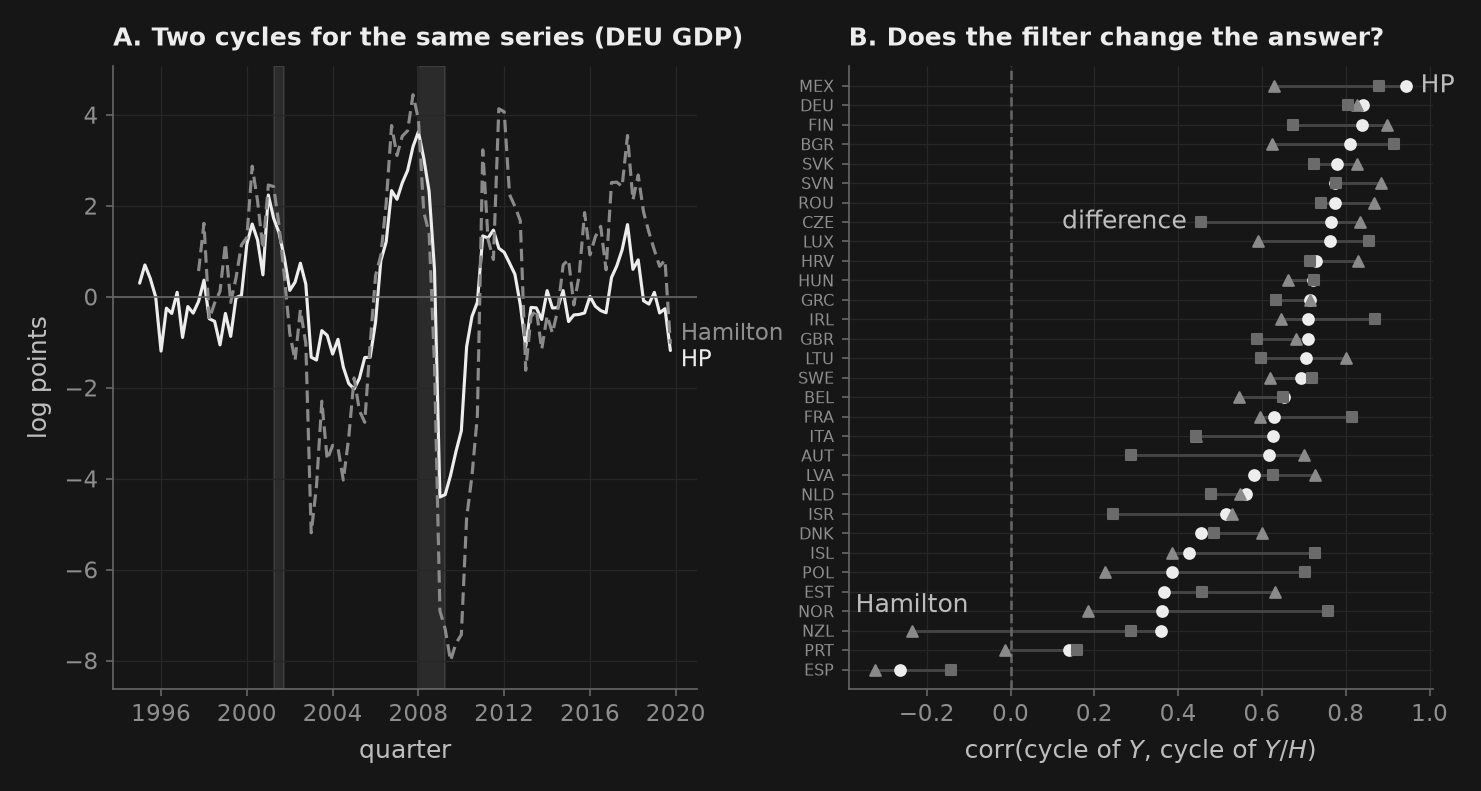

In [16]:
EJEMPLO = "DEU"
d_ej = PANEL[EJEMPLO]
ly_ej = 100.0 * np.log(d_ej["y"])
hp_c, ham_c, dif_c = three_filters(ly_ej)

fig, (axL, axR) = _nbstyle.figura(1, 2, alto=True)

for ini, fin in (("2001-04-01", "2001-10-01"), ("2008-01-01", "2009-04-01")):
    axL.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color=_nbstyle.RECESION, zorder=0)
axL.plot(hp_c.index, hp_c.to_numpy(), color=cols[0], lw=1.5,
         label="HP")
axL.plot(ham_c.index, ham_c.to_numpy(), color=cols[3], lw=1.5, ls=(0, (4, 2)),
         label="Hamilton")
axL.axhline(0, color=_nbstyle.SPINE, lw=0.8)
axL.set_ylabel("log points"); axL.set_xlabel("quarter")
axL.set_title(f"A. Two cycles for the same series ({EJEMPLO} GDP)")

order = cyc.sort_values("HP").index
yy = np.arange(len(order))
MK = {"HP": ("o", cols[0]), "Hamilton": ("^", cols[3]), "difference": ("s", cols[4])}
for name, (mk, col) in MK.items():
    axR.scatter(cyc.loc[order, name], yy, s=26, marker=mk, color=col, zorder=3)
for i, code in enumerate(order):
    lo, hi = cyc.loc[code, F3].min(), cyc.loc[code, F3].max()
    axR.plot([lo, hi], [i, i], color=_nbstyle.tono(0.25), lw=1.4, ls="-", zorder=1)
axR.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.2)
axR.set_yticks(yy); axR.set_yticklabels(order, fontsize=7.6)
axR.set_ylim(-1, len(order))
axR.set_xlabel("corr(cycle of $Y$, cycle of $Y/H$)")
axR.set_title("B. Does the filter change the answer?")
# Each marker's name next to a country where it sits far from the other two.
for name, code, dxy, ha, va in (("HP", "MEX", (7, 0), "left", "center"),
                                ("Hamilton", "NZL", (0, 6), "center", "bottom"),
                                ("difference", "CZE", (-7, 0), "right", "center")):
    if code in order:
        i = int(np.where(order == code)[0][0])
        axR.annotate(name, xy=(cyc.loc[code, name], i), xytext=dxy,
                     textcoords="offset points", ha=ha, va=va, color=_nbstyle.TEXTO)
_nbstyle.etiquetar(axL, donde="fin", fuera=True)
plt.show()


## 4. The cycle facts, as a distribution

The canonical facts are usually taught as a short list of numbers for the United States. With T01_B's panel on disk they become what a model actually has to reproduce: a **distribution over countries**, with a median, a spread, and named exceptions.

We compute, on the HP cycle of each series: relative volatility $\sigma(x)/\sigma(y)$, comovement $\mathrm{corr}(x, y)$, persistence $\mathrm{corr}(y_t, y_{t-1})$, and the share of the cycle's variance that actually falls in the 6-32 quarter band. To the usual $C$ and $I$ we add the three margins from §2, because they are the point of this lesson.

In [17]:
SERIES = {"c": "consumption", "i": "investment", "h": "hours",
          "e": "employment", "prod": "productivity $Y/H$",
          "hpe": "hours per worker"}
WELCH_SEG = 64          # Welch segment for the spectral share, in quarters


def cycle_facts(code):
    # NOT PANEL[code]: that frame is dropped to the quarters where hours and
    # heads both exist, and consumption does not need either. Truncating C to
    # the labour sample would put Mexico's sigma(c)/sigma(y) at 1.06 on
    # 2005-2019 instead of 0.96 on 1995-2019 — a different number for the same
    # country under the same declared convention, which is exactly the mistake
    # the course's measurement notes forbid. Each ratio below is computed on
    # the sample its own pair shares, and `n` reports the shortest one.
    d = labour_frame(code)
    L = {k: 100.0 * np.log(d[k]) for k in ("y", "c", "i", "h", "e")}
    L["prod"] = L["y"] - L["h"]
    L["hpe"] = L["h"] - L["e"]
    cy = {}
    for k, s in L.items():
        s = s.dropna()
        if len(s) < MIN_Q:
            continue
        c, _ = hp_filter(s)
        cy[k] = pd.Series(np.asarray(c), index=s.index)
    y = cy["y"]
    n_lab = int(len(PANEL[code]))
    # The spectral share needs Welch's 64-quarter segment, and a sample
    # shorter than that cannot support it: shrinking the segment does return
    # a number, but a number whose frequency resolution is so coarse that it
    # is not comparable with the others (New Zealand's 44 quarters give 0.47
    # against a panel median near 0.79, and the gap is the segment length,
    # not New Zealand). Report NaN and say how many, rather than tabulate a
    # statistic next to others it cannot be compared with.
    out = {"code": code, "n": len(y), "n(lab)": n_lab,
           "sd(y)": float(y.std(ddof=1)),
           "AR(1)": float(y.autocorr(1)),
           "band 6-32": (float(business_cycle_band_power(y.to_numpy()))
                         if len(y) >= WELCH_SEG else np.nan)}
    for k in SERIES:
        if k not in cy:
            continue
        j = pd.concat([y.rename("y"), cy[k].rename("x")], axis=1, sort=True).dropna()
        out[f"sd({k})/sd(y)"] = float(j["x"].std(ddof=1) / j["y"].std(ddof=1))
        out[f"corr({k},y)"] = float(j["y"].corr(j["x"]))
    return out


facts = pd.DataFrame([cycle_facts(c) for c in CODES]).set_index("code")
print(f"Business cycle facts, HP filter, {len(facts)} countries "
      f"(to {HASTA[:4]}Q4):\n")
print(facts.round(2).to_string())

med = facts.median(numeric_only=True)
print("\n--- the panel median, which is what a model has to hit ---")
print(f"  investment is {med['sd(i)/sd(y)']:.1f}x as volatile as output; "
      f"more volatile in {int((facts['sd(i)/sd(y)'] > 1).sum())}/{len(facts)} countries")
print(f"  consumption {med['sd(c)/sd(y)']:.2f}x, and ABOVE one in "
      f"{int((facts['sd(c)/sd(y)'] > 1).sum())} of {len(facts)} — the split "
      f"T01_B §4.3 tries to explain")
print(f"  hours {med['sd(h)/sd(y)']:.2f}x vs employment "
      f"{med['sd(e)/sd(y)']:.2f}x: the intensive margin adds "
      f"{100*(med['sd(h)/sd(y)']/med['sd(e)/sd(y)']-1):.0f}% more volatility "
      f"than counting heads alone")
print(f"  productivity {med['sd(prod)/sd(y)']:.2f}x and procyclical "
      f"(median corr {med['corr(prod,y)']:+.2f})")
_short = facts.index[facts["band 6-32"].isna()]
print(f"  persistence {med['AR(1)']:.2f}; "
      f"{med['band 6-32']:.0%} of the cycle's variance sits in the 6-32 quarter "
      f"band (over the {int(facts['band 6-32'].notna().sum())} countries with at "
      f"least {WELCH_SEG} quarters"
      + (f"; not {', '.join(_short)})" if len(_short) else ")"))

assert (facts["sd(i)/sd(y)"] > 1.0).all()
assert facts["band 6-32"].min() > 0.5

Business cycle facts, HP filter, 31 countries (to 2019Q4):

        n  n(lab)  sd(y)  AR(1)  band 6-32  sd(c)/sd(y)  corr(c,y)  sd(i)/sd(y)  corr(i,y)  sd(h)/sd(y)  corr(h,y)  sd(e)/sd(y)  corr(e,y)  sd(prod)/sd(y)  corr(prod,y)  sd(hpe)/sd(y)  corr(hpe,y)
code                                                                                                                                                                                                
AUT   100     100   1.16   0.86       0.89         0.60       0.43         2.00       0.71         0.81       0.63         0.39       0.80            0.80          0.62           0.68         0.29
BEL   100     100   0.91   0.86       0.92         0.68       0.43         3.24       0.67         0.78       0.61         0.54       0.43            0.81          0.65           0.52         0.45
BGR    96      96   2.66   0.64       0.60         2.47       0.62         6.07      -0.30         0.67       0.38         0.55       0.44            1.

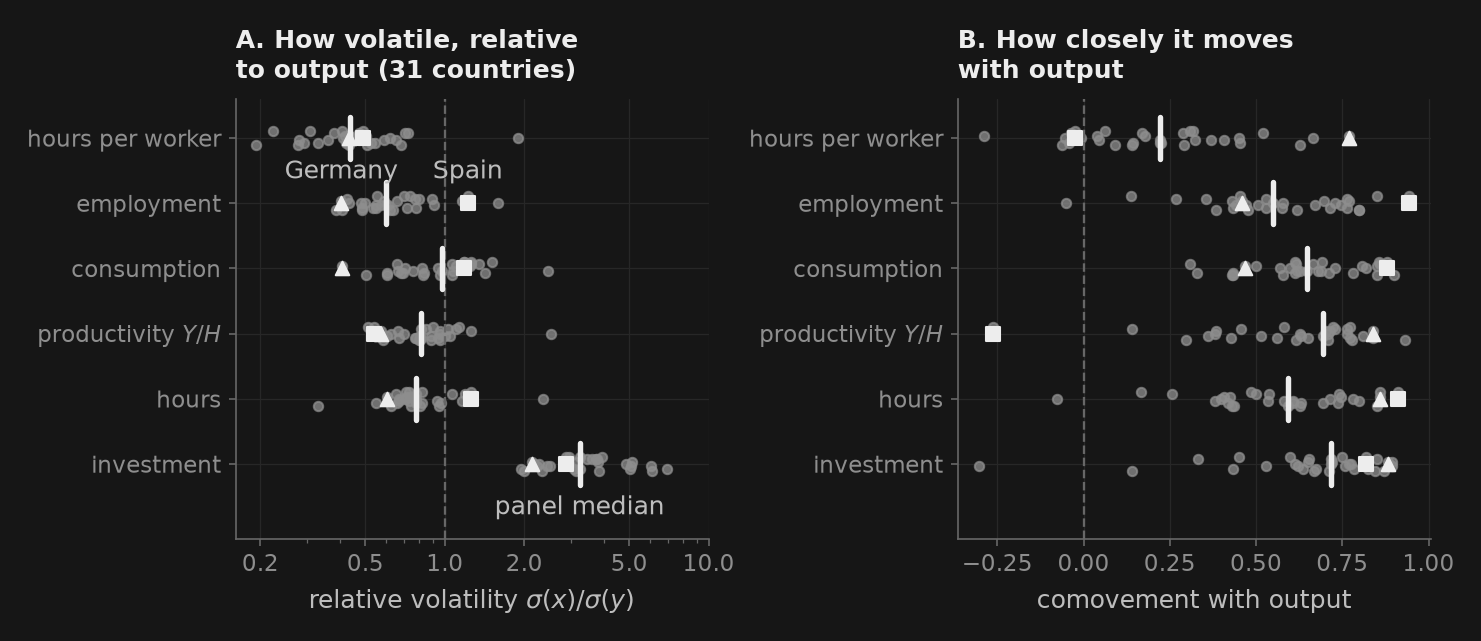

In [18]:
fig, (axV, axC) = _nbstyle.figura(1, 2)
ORDER = ["i", "h", "prod", "c", "e", "hpe"]

for ax, kind, xlabel, ref in (
        (axV, "sd({})/sd(y)", "relative volatility $\\sigma(x)/\\sigma(y)$", 1.0),
        (axC, "corr({},y)", "comovement with output", 0.0)):
    for j, k in enumerate(ORDER):
        v = facts[kind.format(k)].dropna()
        jitter = (np.arange(len(v)) % 7 - 3) * 0.035
        ax.scatter(v, np.full(len(v), j) + jitter, s=20, color=_nbstyle.NOTA,
                   alpha=0.75, zorder=2)
        ax.plot([v.median(), v.median()], [j - 0.32, j + 0.32], color=cols[0],
                lw=2.6, ls="-", zorder=3)
        for code, mk in (("DEU", "^"), ("ESP", "s")):
            if code in v.index:
                ax.scatter([v.loc[code]], [j], s=42, marker=mk, color=cols[0],
                           zorder=4)
    ax.axvline(ref, color=_nbstyle.SPINE, ls="--", lw=1.1)
    ax.set_yticks(range(len(ORDER)))
    ax.set_yticklabels([SERIES[k] for k in ORDER])
    ax.set_ylim(-1.15, len(ORDER) - 0.4)
    ax.set_xlabel(xlabel)
axV.set_xscale("log")
axV.set_xticks([0.2, 0.5, 1, 2, 5, 10])
axV.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
axV.set_title(f"A. How volatile, relative\nto output ({len(facts)} countries)")
axC.set_title("B. How closely it moves\nwith output")
# The two highlighted countries, named above their markers in the employment row
# (where they sit apart), and the median below its tick in the investment row.
j = ORDER.index("e")
v = facts["sd(e)/sd(y)"].dropna()
for code, name in (("DEU", "Germany"), ("ESP", "Spain")):
    if code in v.index:
        axV.annotate(name, xy=(v.loc[code], j), xytext=(0, 9), textcoords="offset points",
                     ha="center", va="bottom", color=_nbstyle.TEXTO)
j = ORDER.index("i")
v = facts["sd(i)/sd(y)"].dropna()
axV.annotate("panel median", xy=(v.median(), j - 0.32), xytext=(0, -5),
             textcoords="offset points", ha="center", va="top", color=_nbstyle.TEXTO)
plt.show()


## 5. The anatomy of a recession

The facts in §4 are unconditional moments — they average over every quarter, boom and slump alike. But the question anyone actually asks about a recession is *where did the adjustment go*, and the §2 identity answers it directly. Take each country's own peak and its own trough, and split the fall in output into the three margins:

$$ \underbrace{\Delta\log Y}_{\text{the recession}} = \underbrace{\Delta\log(Y/H)}_{\text{productivity}} + \underbrace{\Delta\log(H/E)}_{\text{shorter weeks (intensive)}} + \underbrace{\Delta\log E}_{\text{lost jobs (extensive)}}. $$

We date the peak and trough per country rather than imposing common dates, because 2008-09 was not one event on one timetable: Ireland peaked in 2007Q1 and Romania in 2008Q4, and Greece's trough came four and a half years after its peak.

### Labor market institutions: Kurzarbeit vs. dual-track EPL
Why does one economy take the hit in hours while another takes it in jobs?
The adjustment margin is an endogenous equilibrium choice dictated by labor market institutions:
- **Germany and *Kurzarbeit*:** German labor institutions combine firm-level working-time accounts (*Arbeitszeitkonten*) with state-subsidized short-time work (*Kurzarbeit*). The state covers 60% to 67% of lost net wages when firms cut hours rather than dismiss workers. Because industrial employers face steep search, screening, and firm-specific training costs (match capital, Mortensen & Pissarides 1994), they hoard labor. Output falls, hours per worker collapse, and measured productivity plummets — yet employment remains intact.
- **Spain and Employment Protection Duality:** In sharp contrast, Spain's labor market was historically bifurcated by extreme Employment Protection Legislation (EPL) duality (Bentolila, Dolado & Jimeno 2012, 2020). Permanent workers enjoyed high firing costs (up to 45 days' severance pay per year of service), while more than 30% of workers were trapped on temporary fixed-term contracts with minimal severance costs. When the 2008 financial and construction crisis struck, firms took the path of legal least resistance: they did not reduce hours, but rather terminated temporary contracts en masse. Employment collapsed violently along the extensive margin.
- **The Measured Productivity Paradox:** Furthermore, because the terminated temporary workers were disproportionately low-tenure, low-skilled workers in construction and services with below-average productivity, their expulsion mechanically raised average output per remaining worker! Measured Spanish labor productivity *rose* (+7.2 log points) during a catastrophic recession — a dramatic composition effect with zero relation to technological progress.

In [19]:
def anatomy(code, lo="2007-01-01", hi="2011-12-31", peak_by="2008-12-31"):
    """Peak-to-trough decomposition of one country's recession."""
    d = labour_frame(code, hasta=None).dropna(subset=["y", "h", "e"]).loc[lo:hi]
    if len(d) < 12:
        return None
    ly = 100.0 * np.log(d["y"])
    head = ly.loc[:peak_by]
    if head.empty:
        return None
    pk = head.idxmax()
    tr = ly.loc[pk:].idxmin()
    if tr == pk:
        return None
    a, b = d.loc[pk], d.loc[tr]
    dy = 100.0 * np.log(b["y"] / a["y"])
    dh = 100.0 * np.log(b["h"] / a["h"])
    de = 100.0 * np.log(b["e"] / a["e"])
    return {"code": code, "peak": pk.to_period("Q"), "trough": tr.to_period("Q"),
            "quarters": int(round((tr - pk).days / 91.31)),
            "d_y": dy, "d_prod": dy - dh, "d_hpe": dh - de, "d_emp": de}


rec = pd.DataFrame([r for r in (anatomy(c) for c in CODES) if r]).set_index("code")
rec["residual"] = rec.d_prod + rec.d_hpe + rec.d_emp - rec.d_y
rec = rec.sort_values("d_y")
print("The Great Recession, peak to trough, in log points:\n")
# 'peak' and 'trough' are quarters (Period): round only the numeric columns.
_table = rec.drop(columns="residual")
print(_table.round({c: 2 for c in _table.select_dtypes("number")}).to_string())
assert rec["residual"].abs().max() < 1e-9

fell = rec[rec["d_y"] < -0.5]
print(f"\n{len(fell)} of {len(rec)} countries had a fall of more than half a "
      f"log point. Of that fall, the median country lost:")
for k, lbl in (("d_prod", "productivity"), ("d_hpe", "hours per worker"),
               ("d_emp", "employment")):
    print(f"  {(fell[k] / fell['d_y']).median():5.0%} through {lbl}")
up = rec[(rec["d_y"] < -0.5) & (rec["d_prod"] > 0)]
_up = ", ".join("{} ({:+.1f})".format(c, rec.loc[c, "d_prod"]) for c in up.index)
print(f"\nAnd in {len(up)} countries measured productivity ROSE during the "
      f"recession: {_up}")

The Great Recession, peak to trough, in log points:

        peak  trough  quarters    d_y  d_prod  d_hpe  d_emp
code                                                       
LVA   2007Q3  2010Q3        12 -26.65    1.09  -5.19 -22.55
GRC   2007Q2  2011Q4        18 -26.53  -14.42  -3.14  -8.97
EST   2007Q3  2009Q3         8 -22.36   -0.75  -9.57 -12.05
LTU   2008Q2  2009Q4         6 -18.23   -3.85  -2.39 -11.98
ISL   2007Q4  2010Q1         9 -16.58   -6.12   0.18 -10.64
ROU   2008Q4  2010Q3         7 -14.62   -8.45   1.26  -7.42
IRL   2007Q1  2009Q4        11 -13.12    4.55  -6.71 -10.96
HRV   2008Q2  2011Q1        11 -10.49   -6.22   1.16  -5.43
SVK   2008Q4  2009Q1         1 -10.25   -6.62  -2.58  -1.05
FIN   2007Q4  2009Q2         6  -9.89   -6.67  -1.79  -1.43
SVN   2008Q2  2009Q2         4  -9.76   -7.64  -0.88  -1.24
MEX   2008Q3  2009Q2         3  -9.66   -9.00  -0.84   0.19
LUX   2008Q1  2009Q1         4  -8.39   -7.36  -3.33   2.30
HUN   2008Q2  2009Q4         6  -8.22   -3.22  

### Three countries, three different recessions

**Germany** lost 7.3 log points of output with employment **up** 0.6. The whole adjustment ran through productivity ($-5.1$) and shorter weeks ($-2.8$). That is *Kurzarbeit* in two numbers: the state paid firms to cut hours instead of jobs, so the match between worker and firm survived the recession and the labour hoarding shows up as a productivity collapse that was never a technology shock.

**Spain** lost 5.7 log points of output — less than Germany — and 12.9 log points of **employment**. Measured productivity *rose* 7.2 points. Nothing good happened to Spanish technology in 2008-2011; what happened is that the construction sector, with productivity far below the national average, was deleted, and deleting your least productive jobs raises the average. This is §3's negative correlation, and it is a composition effect wearing the clothes of a productivity boom.

**Latvia** lost 26.7 log points, of which 22.6 was employment and 5.2 was hours per worker, with productivity essentially flat. A collapse with no adjustment mechanism at all except the door.

The lesson generalises past these three. The median country lost more of its recession through **productivity** than through jobs — which is the labour-hoarding fact, visible in 29 countries at once — and the countries that did *not* hoard are exactly the ones where employment did the work.

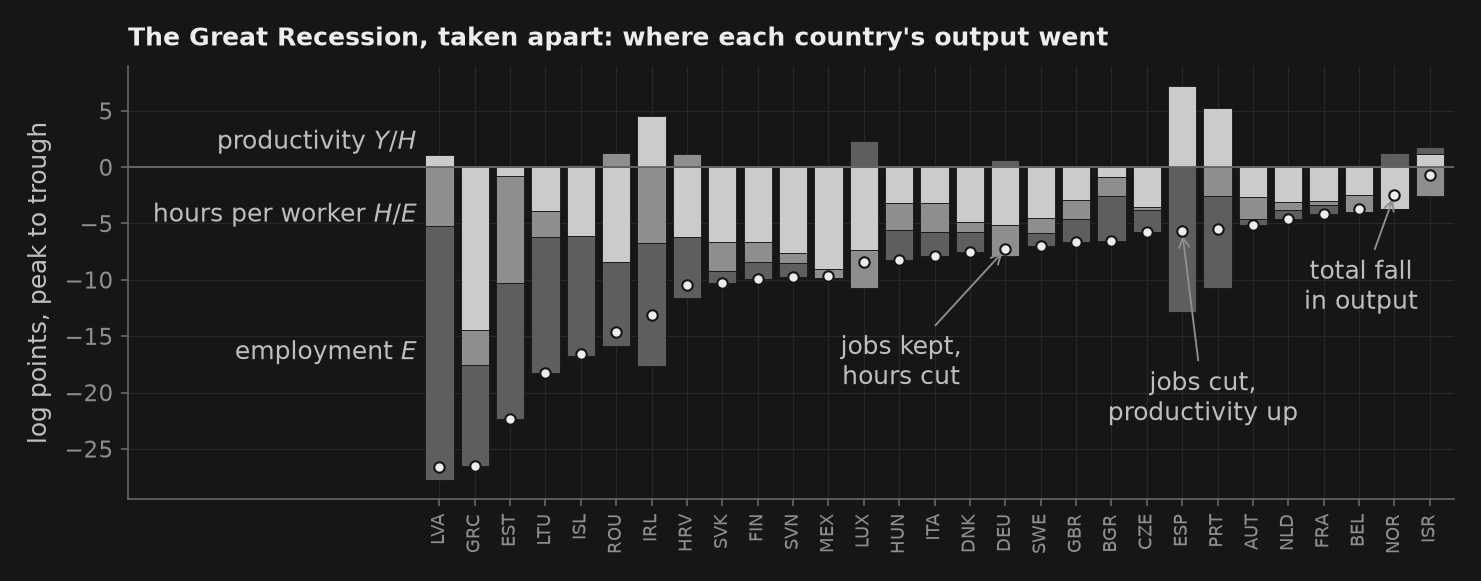

In [20]:
fig, ax = _nbstyle.figura(figsize="ancho")
r = rec.sort_values("d_y")
x = np.arange(len(r))
bp = np.zeros(len(r)); bn = np.zeros(len(r))
centres = {}                      # the centre of each segment in the first bar
for key, label, col in (("d_prod", "productivity $Y/H$", _nbstyle.BARRA_COLORES[0]),
                        ("d_hpe", "hours per worker $H/E$", _nbstyle.BARRA_COLORES[1]),
                        ("d_emp", "employment $E$", _nbstyle.BARRA_COLORES[2])):
    v = r[key].to_numpy()
    base = np.where(v >= 0, bp, bn)
    ax.bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    centres[label] = base[0] + v[0] / 2.0
    bp = bp + np.where(v >= 0, v, 0.0)
    bn = bn + np.where(v < 0, v, 0.0)
ax.plot(x, r["d_y"].to_numpy(), "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=5, zorder=5)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(r.index, rotation=90, fontsize=8.6)
ax.set_ylabel("log points, peak to trough")
ax.set_title("The Great Recession, taken apart: where each country's output went")
# The names next to the segments of the first bar (the deepest fall) and next to
# its dot, instead of a legend.
ax.set_xlim(-8.8, len(r) - 0.3)
for (label, y), va in zip(centres.items(), ("bottom", "top", "center")):
    ax.annotate(label, xy=(x[0] - 0.4, y), xytext=(-4, 3 if va == "bottom" else -3 if va == "top" else 0),
                textcoords="offset points", ha="right", va=va, color=_nbstyle.TEXTO)
i = int(np.where(r.index == "NOR")[0][0]) if "NOR" in r.index else len(r) - 2
ax.annotate("total fall\nin output", xy=(x[i], r["d_y"].iloc[i]), xytext=(-16, -30),
            textcoords="offset points", ha="center", va="top", color=_nbstyle.TEXTO,
            arrowprops=_nbstyle.FLECHA)
for code, note, dxy in (("DEU", "jobs kept,\nhours cut", (-50, -40)),
                        ("ESP", "jobs cut,\nproductivity up", (10, -66))):
    if code in r.index:
        i = int(np.where(r.index == code)[0][0])
        ax.annotate(note, xy=(i, r.loc[code, "d_y"]), xytext=dxy,
                    textcoords="offset points", ha="center", va="top",
                    color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
plt.show()


### 5.1 Okun's law: §4's margin mix, compressed into one number

The decomposition above is about *where* the adjustment went. Okun's law is what the outside world sees when it goes there: how much unemployment a given shortfall of output buys. We estimate it in gap form on the HP cycles,

$$ \tilde{u}_t \;=\; \alpha + \beta\,\tilde{y}_t + \varepsilon_t, $$

and the interesting part is not the median — it is the **spread**, and the fact that §4 already told us what would produce it.

### The Lucas Critique in the labor market: Okun and Beveridge are reduced forms
This institutional divergence is a textbook empirical demonstration of the **Lucas Critique** (Lucas 1976):
Okun's parameter $\beta$ and the Beveridge matching elasticity are **reduced-form statistical correlations, not structural invariants**.
When a government alters labor market institutions — such as Germany refining *Kurzarbeit*, or Spain passing the 2012 labor reform (which reduced severance pay and eased internal working-hour adjustments) — firm hiring, firing, and hours decisions respond endogenously.
If an economic policymaker treats Okun's $\beta$ as an unalterable natural law when designing stabilization policy, the forecast will fail: in an economy with subsidized short-time work, $\beta$ will be nearly zero (Germany $-0.18$); in an economy with extreme dual EPL, $\beta$ will be violently steep (Spain $-0.91$). The slope is an institutional choice.

**A note on the data, because it is the reason this is a section and not a footnote.** The unemployment rate that travels in T01_B's labour block comes from the Beveridge-curve build, so it is limited by the *vacancy* series and starts in 2008–2010 for most countries: ten years and one cycle, which is not enough to estimate anything. `oecd_urate_q.csv` carries the same concept — the OECD harmonised rate, quarterly and seasonally adjusted — from FRED's replication of it, back to 1983 where it exists. That takes the median country from 40 usable quarters to 100, and it is the whole difference between a weak exercise and a fact.

It also does something §1–§5 could not: **it brings back the United States and Japan.** An unemployment rate is a household survey, and every country runs one; hours inside the national accounts are a different matter. So the two economies the accounts could not tell us about appear here, and the US lands almost exactly on Okun's own coefficient.

In [21]:
URATE_LONG = DATOS / "oecd_urate_q.csv"
if not _here(URATE_LONG):
    raise RuntimeError(f"No {URATE_LONG.name}: it travels in data_curso/.")
u_long = pd.read_csv(URATE_LONG, parse_dates=["date"])


def okun(code, urate):
    """Gap-form Okun: the HP cycle of u on the HP cycle of log output."""
    y = volumen("gdp", code).dropna()
    # u starts before GDP, so the index union has to be ordered: sort=True is
    # concat's current default, but pandas 4 flips it.
    d = pd.concat([y.rename("y"), urate.rename("u")],
                  axis=1, sort=True).dropna().loc[:HASTA]
    if len(d) < MIN_Q:
        return None
    yc, _ = hp_filter(100.0 * np.log(d["y"]))
    uc, _ = hp_filter(d["u"])
    yc, uc = np.asarray(yc), np.asarray(uc)
    res_ok = ols(uc, add_constant(yc))
    out = {"code": code, "n": len(d), "from": d.index[0].year,
           "beta": float(res_ok.params[1]), "se": float(res_ok.bse[1]),
           "R2": float(res_ok.rsquared)}
    if code in facts.index:
        out["sd(E)/sd(Y)"] = float(facts.loc[code, "sd(e)/sd(y)"])
    return out


ok = pd.DataFrame([r for r in (okun(c, g.set_index("date")["urate"])
                               for c, g in u_long.groupby("code")
                               if c in HAVE_GDP) if r]).set_index("code")
print(f"Okun's law, gap form, {len(ok)} countries, median "
      f"{int(ok['n'].median())} quarters:\n")
print(ok.sort_values("beta").round(2).to_string())

_extra = sorted(set(ok.index) - set(CODES))
print(f"\nbeta is negative in {int((ok['beta'] < 0).sum())} of {len(ok)} "
      f"countries; median {ok['beta'].median():+.2f}, median R2 "
      f"{ok['R2'].median():.2f}.")
print(f"  Spain {ok.loc['ESP', 'beta']:+.2f} — a point of output costs almost a "
      f"point of unemployment — against Japan {ok.loc['JPN', 'beta']:+.2f} and "
      f"Germany {ok.loc['DEU', 'beta']:+.2f}.")
print(f"  The United States is at {ok.loc['USA', 'beta']:+.2f}, which is Okun's "
      f"own 1962 coefficient to within a rounding error.")
print(f"  {len(_extra)} of these countries are NOT in the productivity panel "
      f"({', '.join(_extra)}):\n  an unemployment rate is a household survey and "
      f"everyone runs one; hours inside the\n  national accounts are a different "
      f"matter.")

_j = ok.dropna(subset=["sd(E)/sd(Y)"])
print(f"\nAnd §4 predicted the spread: corr(beta, sd(E)/sd(Y)) = "
      f"{_j['beta'].corr(_j['sd(E)/sd(Y)']):.2f} over the {len(_j)} countries "
      f"with both.\nCountries that adjust on employment convert a given output "
      f"shortfall into more unemployment.\nIt is *almost* a tautology — and "
      f"exercise 7 asks you for the part that is not.")

assert (ok["beta"] < 0).all()
assert ok["n"].median() > 80

Okun's law, gap form, 34 countries, median 100 quarters:

        n  from  beta    se    R2  sd(E)/sd(Y)
code                                          
ESP   100  1995 -0.91  0.05  0.80         1.22
USA   100  1995 -0.59  0.03  0.75          NaN
GRC    87  1998 -0.50  0.04  0.64         0.66
PRT   100  1995 -0.50  0.05  0.53         0.90
POL    92  1997 -0.50  0.10  0.21         1.16
EST    92  1997 -0.40  0.03  0.64         0.63
NLD    96  1996 -0.37  0.04  0.54         0.72
CAN   100  1995 -0.36  0.02  0.75          NaN
SVK    88  1998 -0.34  0.04  0.43         0.49
KOR   100  1995 -0.32  0.02  0.65          NaN
CHL    96  1996 -0.32  0.03  0.51          NaN
DNK   100  1995 -0.31  0.03  0.46         0.77
BEL   100  1995 -0.30  0.05  0.26         0.54
TUR    60  2005 -0.28  0.03  0.65          NaN
CZE   100  1995 -0.27  0.03  0.40         0.50
ITA    96  1996 -0.25  0.03  0.43         0.48
GBR   100  1995 -0.25  0.02  0.61         0.44
FRA   100  1995 -0.25  0.04  0.33         0.57
SW

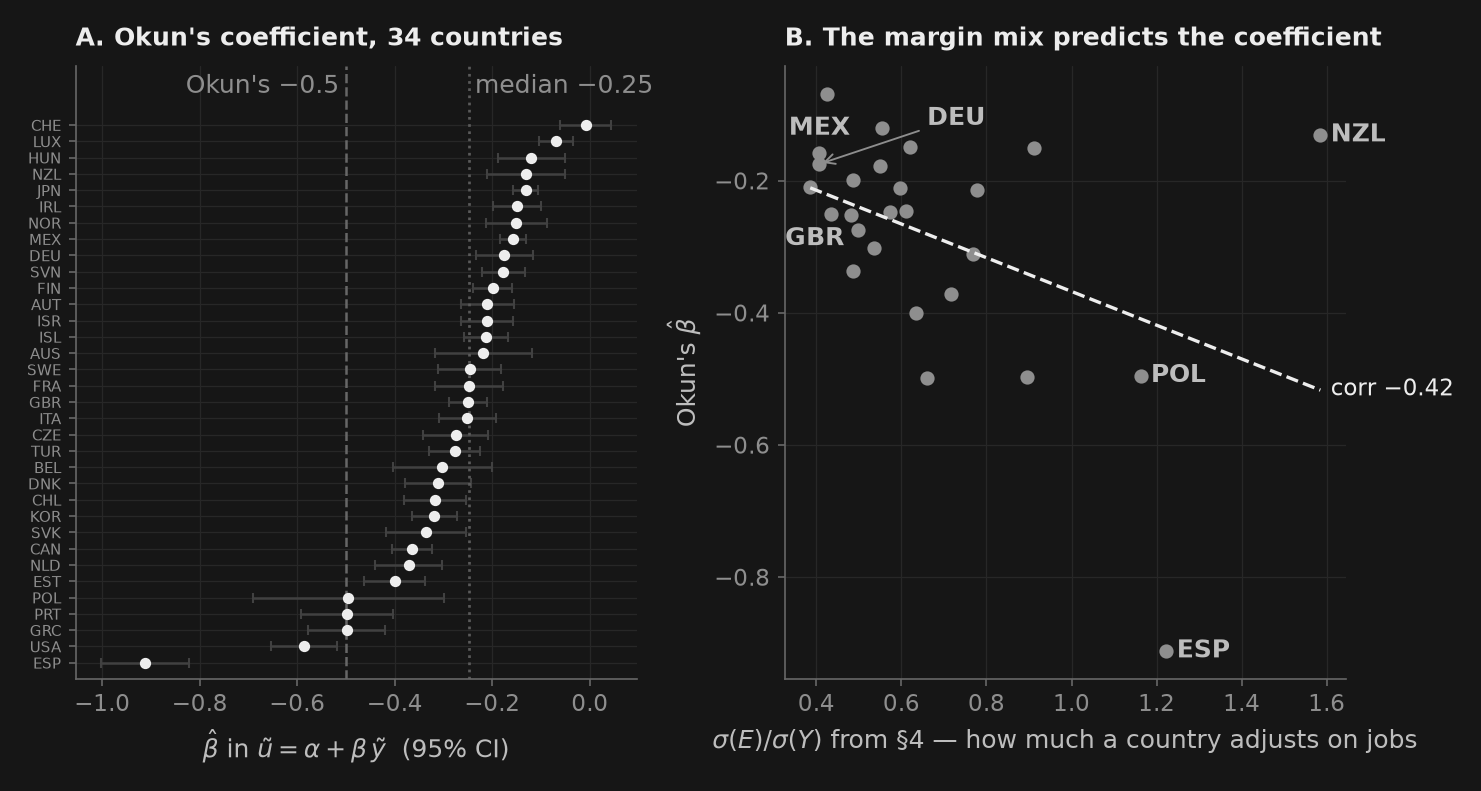

In [22]:
fig, (axO, axM) = _nbstyle.figura(1, 2, alto=True)

o = ok.sort_values("beta")
yy = np.arange(len(o))
axO.errorbar(o["beta"], yy, xerr=1.96 * o["se"], fmt="o", color=cols[0],
             ecolor=_nbstyle.gris("0.7"), elinewidth=1.2, capsize=2.5, ms=4.4, lw=0)
med = float(o["beta"].median())
axO.axvline(med, color=_nbstyle.gris("0.55"), ls=":", lw=1.3)
axO.axvline(-0.5, color=_nbstyle.SPINE, ls="--", lw=1.2)
axO.set_yticks(yy); axO.set_yticklabels(o.index, fontsize=7.4)
axO.set_ylim(-1, len(o) + 2.6)
axO.set_xlabel("$\\hat{\\beta}$ in $\\tilde{u} = \\alpha + \\beta\\,\\tilde{y}$  (95% CI)")
axO.set_title(f"A. Okun's coefficient, {len(o)} countries")
# The two lines, named at their upper end instead of in a legend.
axO.annotate(f"median ${med:+.2f}$", xy=(med, len(o) + 0.6), xytext=(3, 0),
             textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
axO.annotate("Okun's $-0.5$", xy=(-0.5, len(o) + 0.6), xytext=(-3, 0),
             textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)

j = ok.dropna(subset=["sd(E)/sd(Y)"])
axM.scatter(j["sd(E)/sd(Y)"], j["beta"], s=34, color=_nbstyle.NOTA, zorder=2)
# The left corner is crowded: MEX goes above its dot, GBR below its own, and
# DEU -- boxed in between the two -- out in the clear, with a leader back to it.
for code, dxy, ha, va in (("ESP", (5, -3), "left", "baseline"),
                          ("DEU", (52, 16), "left", "bottom"),
                          ("NZL", (5, -3), "left", "baseline"),
                          ("MEX", (0, 6), "center", "bottom"),
                          ("GBR", (-8, -6), "center", "top"),
                          ("POL", (5, -3), "left", "baseline")):
    if code in j.index:
        axM.annotate(code, (j.loc[code, "sd(E)/sd(Y)"], j.loc[code, "beta"]),
                     xytext=dxy, textcoords="offset points", fontweight="bold",
                     ha=ha, va=va, color=_nbstyle.TEXTO,
                     arrowprops=_nbstyle.FLECHA if code == "DEU" else None)
_b = np.polyfit(j["sd(E)/sd(Y)"], j["beta"], 1)
_x = np.linspace(j["sd(E)/sd(Y)"].min(), j["sd(E)/sd(Y)"].max(), 20)
axM.plot(_x, np.polyval(_b, _x), color=cols[0], lw=1.6, ls="--",
         label=f"corr ${j['beta'].corr(j['sd(E)/sd(Y)']):.2f}$")
axM.set_xlabel("$\\sigma(E)/\\sigma(Y)$ from §4 — how much a country adjusts on jobs")
axM.set_ylabel("Okun's $\\hat{\\beta}$")
axM.set_title("B. The margin mix predicts the coefficient")
_nbstyle.etiquetar(axM, donde="fin")
plt.show()


### 5.2 The Beveridge curve: how the labour market delivers the unemployment Okun counts

Okun's law counts the unemployment; it does not say how it is produced. The mechanism is the Beveridge curve: when output falls firms stop posting vacancies, matching slows down and unemployment rises *along* a downward-sloping curve in the $(u, v)$ plane. T01_B §5.2 fitted that curve — $\log v = a + b\log u$ before 2020 — and measured how far it shifted after 2021. We do not fit it again here: we ask it three questions, and then we ask what it says about Okun.

**How much it moves.** Tightness $\theta = v/u$ is the state variable of every search model, and Shimer (2005) showed that in the United States it is about twenty times as volatile as productivity when the model with Nash-bargained wages delivers a number near one. That is the *Shimer puzzle*, and here we measure it as a distribution, $\sigma(\tilde\theta)/\sigma(\tilde y)$ country by country: 11 times in the median country, between 6.7 (Ireland) and 22.0 (Czechia), with the United States at 21.1. Shimer's number is the high end of a distribution whose centre sits at 10–16, not a number apart.

**Which side moves.** $\log\theta = \log v - \log u$, so the elasticity of tightness to the output cycle splits *exactly* into the elasticity of vacancies and that of unemployment, and Okun only sees the second. 1% of output moves $\theta$ by 6.8% in the median country: 4.5 is vacancies disappearing and 2.0 is unemployed workers appearing, two thirds of the movement on the vacancy side. Vacancies are the elastic side in 14 of 20 countries; the United States is the symmetric one, $+9.2$ and $-10.0$, which is Shimer's fact.

**Who moves first.** If vacancies fall before unemployment rises, $\mathrm{corr}(\tilde v_t, \tilde u_{t+k})$ reaches its minimum at $k>0$ and the path in the $(u,v)$ plane turns counterclockwise. The median correlation bottoms out at $k=+1$, and in 16 of 20 countries the correlation with *next* quarter's unemployment is more negative than with last quarter's. Vacancies lead by one quarter.

**And what that says about Okun**, in the second cell. The slope $b$ of the curve does not predict Okun's coefficient: corr $0.07$ over 16 countries, because $\beta$ depends on how far vacancies fall *and* on the slope at once. What the slope does do is rank the elasticity of unemployment once it is given that of vacancies — corr $0.67$ — but it overpredicts, $-5.5$ against an observed $-2.1$, because the market does not walk the curve point by point but in a loop. §4's employment margin predicts Okun in points ($-0.73$ over the 14 countries with all three, $-0.51$ without Spain; §5.1 gave $-0.42$ over 26) and not the volatility of tightness ($0.11$ over 18); the tempting explanation — the level of unemployment — is Spain, not the panel, and it stays an open question with its negative test. And the 2020–23 loop, which here *is* the object, was the same counterclockwise loop as always at another scale: tightness hit 3.1 times its 2010–19 median in the median country, and the countries that raised it most were not the ones with the steepest Okun (corr $+0.36$, the wrong sign for that conjecture) but the ones with the most elastic vacancies in normal times ($0.53$).

**A note on the data, because once again it decides the answer.** The $u$ and $v$ are those of T01_B's labour block, and they are limited by the vacancy series: they start in 2008–2010 for almost every country, and with the cut at 2019Q4 requiring `MIN_Q = 40` leaves **20 countries** with output and vacancies at once out of the 30 that have $u$ and $v$: Cyprus and Malta have no GDP in the expenditure block; Belgium, Finland, Greece, Croatia, Italy and Portugal have between 16 and 28 quarters, and Germany and France fall three and five short of the minimum. That is ten years and one cycle per country, and an HP cycle on 40 quarters is a loose estimate: what holds the section up is not any one country's coefficient but the median and the count over the 20, with the United States (from 2000) and the United Kingdom (from 2001) as the two long controls. JOLTS and Eurostat vacancy levels are not comparable (T01_B warns of it); only cycles, elasticities and within-country ratios enter here, and those are immune to scale. Every cyclical moment cuts at 2019Q4; 2020–23 appears only in the last block, and only because there the episode is the object.

In [23]:
def _elasticity(x, y):
    """OLS of y on x with a constant: slope, standard error."""
    res = ols(y, add_constant(x))
    return float(res.params[1]), float(res.bse[1])


LEADS = range(-4, 5)


def beveridge_cycle(code):
    """HP cycles of log theta, log v, log u for one country against the output cycle.

    All before 2020 (HASTA). Returns None without MIN_Q quarters of output
    and vacancies at once; ten of the 30 countries with u and v drop out:
    Cyprus and Malta have no GDP in the expenditure block, six have between
    16 and 28 quarters, and Germany (37) and France (35) fall three and five short.
    """
    if code not in HAVE_GDP:
        return None
    s = lab.loc[code][["urate", "vrate", "theta"]]
    d = pd.concat([volumen("gdp", code).rename("y"), s],
                  axis=1, sort=True).dropna()
    pre = d.loc[:HASTA]
    if len(pre) < MIN_Q:
        return None
    cy = {k: np.asarray(hp_filter(100.0 * np.log(pre[k]))[0])
          for k in ("y", "theta", "vrate", "urate")}
    out = {"code": code, "n": len(pre), "from": pre.index[0].year,
           "sd(theta)/sd(y)": float(cy["theta"].std(ddof=1) / cy["y"].std(ddof=1)),
           "corr(theta,y)": float(np.corrcoef(cy["y"], cy["theta"])[0, 1])}
    for k, lbl in (("theta", "theta"), ("vrate", "v"), ("urate", "u")):
        out[f"el({lbl})"], out[f"se({lbl})"] = _elasticity(cy["y"], cy[k])
    # The Beveridge slope as T01_B §5.2 fitted it: log v on log u in levels,
    # before 2020.
    out["b"], _ = _elasticity(np.log(pre["urate"].to_numpy()),
                              np.log(pre["vrate"].to_numpy()))
    # Timing: corr(v_t, u_{t+k}). If the minimum falls at k > 0, vacancies
    # move BEFORE unemployment.
    v, u = pd.Series(cy["vrate"]), pd.Series(cy["urate"])
    xc = {k: float(v.corr(u.shift(-k))) for k in LEADS}
    out["v lead"] = int(min(xc, key=xc.get))
    out.update({f"xc{k:+d}": xc[k] for k in LEADS})
    # The 2020-23 episode, which here is the object: the peak of tightness in
    # 2021-23 against its 2010-19 median, and T01_B's shift.
    post, ref = d.loc["2021-01-01":"2023-12-31"], d.loc["2010-01-01":HASTA]
    if len(post) >= 8:
        out["theta peak 21-23 / med 10-19"] = float(post["theta"].max()
                                                    / ref["theta"].median())
        out["u min 21-23 / med 10-19"] = float(post["urate"].min()
                                               / ref["urate"].median())
        a = np.log(pre["vrate"]).mean() - out["b"] * np.log(pre["urate"]).mean()
        out["shift"] = float((np.log(post["vrate"])
                              - (a + out["b"] * np.log(post["urate"]))).mean())
    return out


bv = pd.DataFrame([r for r in (beveridge_cycle(c) for c in
                               sorted(set(lab.index.get_level_values("code"))))
                   if r]).set_index("code")
XC = bv[[f"xc{k:+d}" for k in LEADS]]
XC.columns = list(LEADS)

_out = {}
_with_uv = set(lab[["urate", "vrate"]].dropna().index.get_level_values("code"))
for c in sorted(_with_uv - set(bv.index)):
    if c not in HAVE_GDP:
        _out[c] = "no GDP"
    else:
        _out[c] = str(len(pd.concat([volumen("gdp", c).rename("y"),
                                      lab.loc[c][["urate", "vrate"]]],
                                     axis=1, sort=True).dropna().loc[:HASTA]))

print(f"Tightness theta = v/u against output, HP cycles, {len(bv)} countries, "
      f"{int(bv['n'].min())}-{int(bv['n'].max())} quarters to "
      f"{HASTA[:4]}Q4 (median {int(bv['n'].median())}).")
print(f"Out below MIN_Q = {MIN_Q}: "
      + ", ".join(f"{c} ({v})" for c, v in _out.items()) + ".\n")
print(bv[["n", "from", "sd(theta)/sd(y)", "corr(theta,y)", "el(theta)",
          "se(theta)", "el(v)", "el(u)", "b", "v lead"]]
      .sort_values("el(theta)", ascending=False).round(2).to_string())

r = bv["sd(theta)/sd(y)"]
print(f"\n(a) The Shimer puzzle, as a distribution. Tightness is "
      f"{r.median():.0f}x as volatile as output\n    in the median country "
      f"(interquartile range {r.quantile(.25):.0f}-{r.quantile(.75):.0f}x; "
      f"minimum {r.min():.1f}x {r.idxmin()}, maximum {r.max():.1f}x {r.idxmax()}; "
      f"United States {r['USA']:.1f}x).")
t = bv["el(theta)"] / bv["se(theta)"]
print(f"    1% of output moves theta by {bv['el(theta)'].median():.1f}% "
      f"(median elasticity); positive in "
      f"{int((bv['el(theta)'] > 0).sum())} of {len(bv)} countries and with t > 2 in "
      f"{int((t > 2).sum())}.\n    United States: {bv.loc['USA', 'el(theta)']:.1f} "
      f"over {int(bv.loc['USA', 'n'])} quarters. The exception is Norway "
      f"({bv.loc['NOR', 'el(theta)']:+.1f}, corr {bv.loc['NOR', 'corr(theta,y)']:+.2f}).")

v_side = bv["el(v)"] > -bv["el(u)"]
v_share = (bv["el(v)"] / bv["el(theta)"]).median()
print(f"\n(b) Which side moves. el(theta) = el(v) - el(u): vacancies "
      f"{bv['el(v)'].median():+.1f} against unemployment {bv['el(u)'].median():+.1f}; "
      f"the median vacancy share of el(theta) is {v_share:.2f}.\n"
      f"    Vacancies are the elastic side in {int(v_side.sum())} of {len(bv)} "
      f"countries; unemployment only in {', '.join(sorted(bv.index[~v_side]))}.\n"
      f"    The United States is symmetric ({bv.loc['USA', 'el(v)']:+.1f} and "
      f"{bv.loc['USA', 'el(u)']:+.1f}), which is Shimer's (2005) fact.")

xc_med = XC.median()
k_med = int(xc_med.idxmin())
asym = bv["xc+1"] - bv["xc-1"]
print(f"\n(c) Who moves first. Median corr(v_t, u_(t+k)): "
      + ", ".join(f"k={k:+d}: {xc_med[k]:+.2f}" for k in (-2, -1, 0, 1, 2))
      + f".\n    The minimum falls at k = {k_med:+d}: vacancies lead unemployment "
      f"by one quarter. Modal lead {int(bv['v lead'].mode()[0])}, "
      f"median {bv['v lead'].median():.0f};\n    corr(v_t, u_(t+1)) is more "
      f"negative than corr(v_t, u_(t-1)) in {int((asym < 0).sum())} of {len(bv)} "
      f"countries (not in {', '.join(sorted(bv.index[asym >= 0]))}).\n    With v "
      f"leading, the loop in the (u, v) plane turns counterclockwise: v falls, "
      f"u rises, v recovers, u falls.")

assert 8 < r.median() < 14
assert (bv["el(theta)"] > 0).sum() >= len(bv) - 2
assert v_side.sum() >= 13 and 0.55 < v_share < 0.75
assert k_med == 1 and (asym < 0).sum() >= 14          # one quarter, not "some"
assert len(bv) == 20 and len(_out) == 10

Tightness theta = v/u against output, HP cycles, 20 countries, 40-77 quarters to 2019Q4 (median 48).
Out below MIN_Q = 40: BEL (28), CYP (no GDP), DEU (37), FIN (28), FRA (35), GRC (24), HRV (28), ITA (16), MLT (no GDP), PRT (24).

       n  from  sd(theta)/sd(y)  corr(theta,y)  el(theta)  se(theta)  el(v)  el(u)     b  v lead
code                                                                                            
USA   77  2000            21.12           0.91      19.25       1.00   9.21 -10.04 -0.69       0
CZE   48  2008            21.96           0.69      15.05       2.36   9.88  -5.18 -1.57       0
NLD   48  2008            15.34           0.87      13.28       1.13   9.96  -3.32 -1.25       2
AUT   40  2010            14.72           0.76      11.16       1.56   7.18  -3.98 -0.75       4
EST   48  2008            10.63           0.94       9.96       0.55   4.85  -5.11 -0.58       0
GBR   75  2001            10.47           0.86       8.99       0.63   4.94  -4.05 -0.61 

In [24]:
# What does all this say about Okun? Cross with 'ok' (§5.1) and 'facts' (§4).
j = bv.join(ok[["beta"]], how="inner")
jn = j[j["b"] < 0]
print(f"(d) The Beveridge slope and Okun's coefficient, {len(j)} countries "
      f"with both (Okun over {int(ok.loc[j.index, 'n'].median())} quarters):")
print(f"    corr(beta, b) = {j['beta'].corr(j['b']):+.2f}. The slope does NOT predict "
      f"Okun.\n    corr(beta, 1/|b|) = {jn['beta'].corr(1 / jn['b'].abs()):+.2f} "
      f"over the {len(jn)} with b < 0 — but without Spain it is "
      f"{jn.drop('ESP')['beta'].corr(1 / jn.drop('ESP')['b'].abs()):+.2f}: "
      f"one country, not a fact.")
c_ok = j["beta"].corr(j["el(u)"])
bn = bv[bv["b"] < 0]
pred = bn["el(v)"] / bn["b"]
print(f"    What the slope does do is rank how much unemployment a fall in "
      f"vacancies buys: if the economy\n    moved along the curve, "
      f"el(u) = el(v)/b. corr(el(u), el(v)/b) = {bn['el(u)'].corr(pred):+.2f} "
      f"over {len(bn)} countries,\n    but the prediction is {pred.median():+.1f} "
      f"against a median el(u) of {bn['el(u)'].median():+.1f}: unemployment moves "
      f"less than half of what\n    the slope says, because the curve is walked "
      f"with a one-quarter lag and in a loop, not point by point.")
print(f"    And §5.1's Okun in points and the unemployment elasticity here "
      f"only half agree: corr(beta, el(u)) = {c_ok:+.2f}.")

h = bv.join(facts[["sd(e)/sd(y)"]], how="inner")
u_mean = pd.Series({c: float(lab.loc[c]["urate"].dropna().loc[:HASTA].mean())
                    for c in h.index})
hb = h.join(ok[["beta"]], how="inner")
_no_esp = hb.drop("ESP")
print(f"\n(e) Does §4's employment margin predict the volatility of tightness? "
      f"No: corr(sd(E)/sd(Y), sd(theta)/sd(y)) = "
      f"{h['sd(e)/sd(y)'].corr(h['sd(theta)/sd(y)']):+.2f}\n    over {len(h)} "
      f"countries, and not the log elasticity of unemployment either "
      f"({h['sd(e)/sd(y)'].corr(h['el(u)']):+.2f}). What it predicts is Okun "
      f"in POINTS:\n    corr(sd(E)/sd(Y), beta) = "
      f"{hb['sd(e)/sd(y)'].corr(hb['beta']):+.2f} over {len(hb)} countries, and "
      f"{_no_esp['sd(e)/sd(y)'].corr(_no_esp['beta']):+.2f} without Spain: that one is a fact.")
print(f"    The tempting explanation is the level of unemployment — corr(mean u, beta) = "
      f"{u_mean.loc[hb.index].corr(hb['beta']):+.2f} — but without Spain it falls to "
      f"{u_mean.loc[_no_esp.index].corr(_no_esp['beta']):+.2f}.\n    A country with "
      f"{u_mean['ESP']:.0f}% unemployment converts the same proportional fall in its "
      f"market into many more points, and that country is\n    one: Spain. Why §4 "
      f"predicts the points and not the proportion stays an open question with its "
      f"negative test.")

post = bv.dropna(subset=["shift"])
pk = post["theta peak 21-23 / med 10-19"]
jp = post.join(ok[["beta"]], how="inner")
print(f"\n(f) The 2020-23 loop, which here is the object ({len(post)} countries "
      f"with data to 2023; not GBR).\n    Tightness peaked at "
      f"{pk.median():.1f}x its 2010-19 median in the median country "
      f"(minimum {pk.min():.1f}x {pk.idxmin()}, maximum {pk.max():.1f}x {pk.idxmax()}),\n"
      f"    more than double in {int((pk > 2).sum())} of {len(post)}, and unemployment fell "
      f"below its 2010-19 median in {int((post['u min 21-23 / med 10-19'] < 1).sum())} "
      f"of {len(post)}.\n    Outward shift in "
      f"{int((post['shift'] > 0).sum())} of {len(post)}, median "
      f"{post['shift'].median():+.2f} log points (T01_B §5.2).")
print(f"    Did the countries with the steepest Okun shift the curve most? No: "
      f"corr(beta, shift) = {jp['beta'].corr(jp['shift']):+.2f} over "
      f"{len(jp)} — the sign\n    opposite to the conjecture — and corr(beta, theta "
      f"peak) = {jp['beta'].corr(jp[pk.name]):+.2f}. What does rank the peak "
      f"is the elasticity of\n    vacancies in normal times: corr(el(v), "
      f"theta peak) = {post['el(v)'].corr(pk):+.2f}. It stays an open question "
      f"with its negative test.")

assert abs(j["beta"].corr(j["b"])) < 0.3
assert bn["el(u)"].corr(pred) > 0.5
assert abs(h["sd(e)/sd(y)"].corr(h["sd(theta)/sd(y)"])) < 0.4
assert hb["sd(e)/sd(y)"].corr(hb["beta"]) < -0.5
assert _no_esp["sd(e)/sd(y)"].corr(_no_esp["beta"]) < -0.4
assert pk.median() > 2 and (post["u min 21-23 / med 10-19"] < 1).all()
assert jp["beta"].corr(jp["shift"]) > 0 and post["el(v)"].corr(pk) > 0.4   # the wrong sign, and the one that does rank

(d) The Beveridge slope and Okun's coefficient, 16 countries with both (Okun over 100 quarters):
    corr(beta, b) = +0.07. The slope does NOT predict Okun.
    corr(beta, 1/|b|) = -0.68 over the 15 with b < 0 — but without Spain it is -0.18: one country, not a fact.
    What the slope does do is rank how much unemployment a fall in vacancies buys: if the economy
    moved along the curve, el(u) = el(v)/b. corr(el(u), el(v)/b) = +0.67 over 19 countries,
    but the prediction is -5.5 against a median el(u) of -2.1: unemployment moves less than half of what
    the slope says, because the curve is walked with a one-quarter lag and in a loop, not point by point.
    And §5.1's Okun in points and the unemployment elasticity here only half agree: corr(beta, el(u)) = +0.58.

(e) Does §4's employment margin predict the volatility of tightness? No: corr(sd(E)/sd(Y), sd(theta)/sd(y)) = +0.11
    over 18 countries, and not the log elasticity of unemployment either (-0.03). What it predicts is O

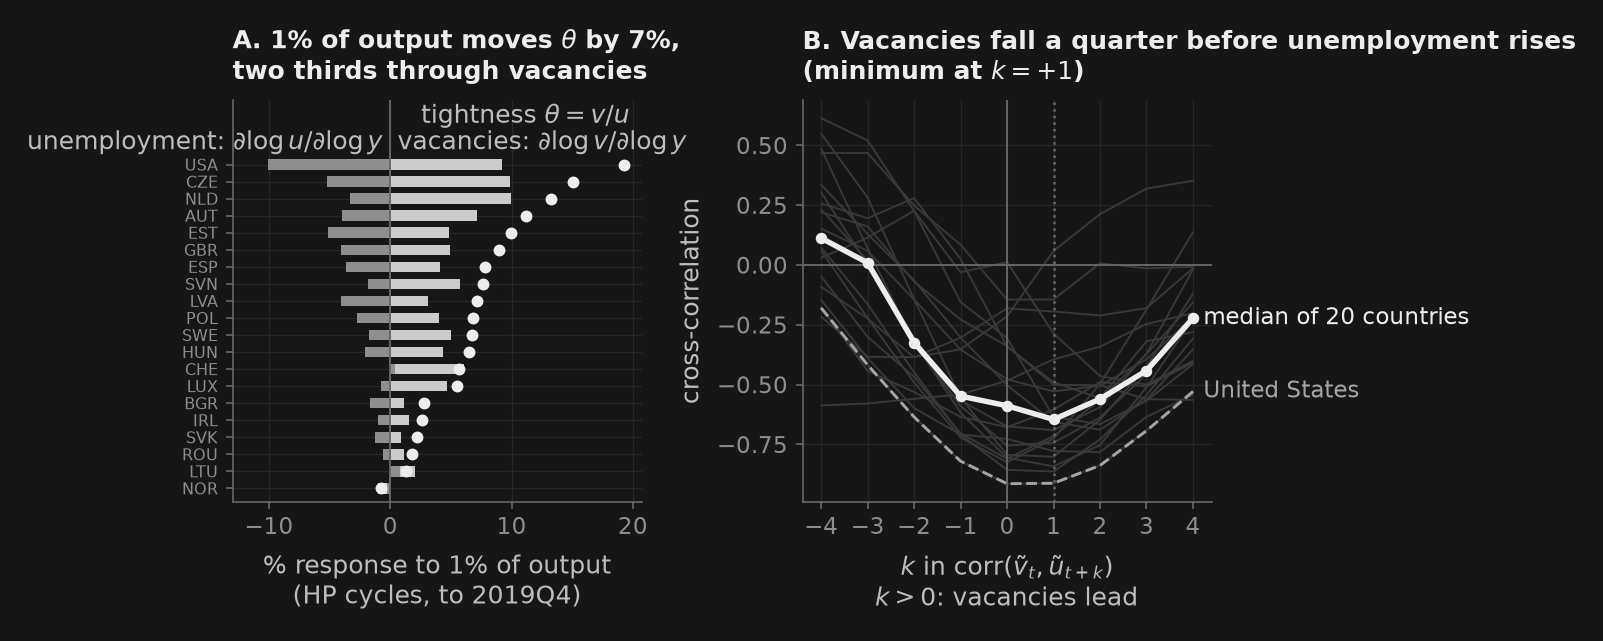

In [25]:
fig, (axE, axX) = _nbstyle.figura(1, 2)

o = bv.sort_values("el(theta)")
yy = np.arange(len(o))
axE.barh(yy, o["el(v)"], color=_nbstyle.BARRA_COLORES[0], height=0.62)
axE.barh(yy, o["el(u)"], color=_nbstyle.BARRA_COLORES[1], height=0.62)
axE.scatter(o["el(theta)"], yy, s=22, color=_nbstyle.TINTA, zorder=4)
axE.axvline(0, color=_nbstyle.SPINE, lw=0.9)
axE.set_axisbelow(True)
axE.set_yticks(yy); axE.set_yticklabels(o.index, fontsize=7.6)
axE.set_ylim(-0.8, len(o) + 2.8)
axE.set_xlim(left=-13.0)
axE.set_xlabel("% response to 1% of output\n(HP cycles, to 2019Q4)")
axE.set_title(f"A. 1% of output moves $\\theta$ by "
              f"{bv['el(theta)'].median():.0f}%,\ntwo thirds through vacancies")
# The three names above the top row, each over what it names, instead of a legend.
top = yy[-1] + 0.55
axE.annotate("unemployment: $\\partial \\log u / \\partial \\log y$", xy=(-0.6, top),
             ha="right", va="bottom", color=_nbstyle.TEXTO)
axE.annotate("vacancies: $\\partial \\log v / \\partial \\log y$", xy=(0.6, top),
             ha="left", va="bottom", color=_nbstyle.TEXTO)
axE.annotate("tightness $\\theta = v/u$", xy=(o["el(theta)"].iloc[-1], top + 1.5),
             xytext=(3, 0), textcoords="offset points", ha="right", va="bottom",
             color=_nbstyle.TEXTO)

for code in XC.index:
    axX.plot(list(LEADS), XC.loc[code], color=_nbstyle.gris("0.75"), lw=0.9, ls="-", zorder=1)
axX.plot(list(LEADS), xc_med, color=cols[0], lw=2.6, ls="-", marker="o", ms=4.5,
         zorder=3, label=f"median of {len(XC)} countries")
axX.plot(list(LEADS), XC.loc["USA"], color=_nbstyle.S2["color"], lw=1.4, ls="--",
         zorder=2, label="United States")
axX.axvline(0, color=_nbstyle.SPINE, lw=0.9); axX.axhline(0, color=_nbstyle.SPINE, lw=0.9)
axX.axvline(k_med, color=_nbstyle.SPINE, ls=":", lw=1.2)
axX.set_xticks(list(LEADS))
axX.set_xlabel("$k$ in $\\mathrm{corr}(\\tilde v_t, \\tilde u_{t+k})$\n"
               "$k>0$: vacancies lead")
axX.set_ylabel("cross-correlation")
axX.set_title(f"B. Vacancies fall a quarter before unemployment rises\n"
              f"(minimum at $k={k_med:+d}$)")
_nbstyle.etiquetar(axX, donde="fin")
plt.show()


### 5.3 The Phillips curve: what that unemployment buys in prices

§5.1 said how much unemployment an output shortfall buys and §5.2 how the market delivers it. This section asks what that unemployment buys in prices, and the answer has two parts that are best not mixed: the Phillips curve the textbooks carry and the one that is in the 1995–2019 data.

The textbook one is the accelerationist curve, with adaptive expectations: $\pi_t - \bar\pi_{t-1..t-4} = \alpha + \kappa\,\tilde u_t$, where $\bar\pi$ is the mean of the previous four quarters and $\tilde u_t$ is **the same HP cycle of unemployment that Okun estimated in §5.1** — the cell checks it by re-estimating $\beta$ with it, to the last bit. Over 34 countries and 1995Q1–2019Q4 that curve is not there: $\kappa<0$ in 14 of 34, median $+0.10$. The fault is not unemployment's but the expectations term's. If instead of imposing that past inflation enters with a coefficient of 1 we estimate it, $\pi_t = \alpha + \rho\,\bar\pi + \kappa\,\tilde u_t$, $\rho$ has a median of $0.36$, a maximum of $0.77$ (Hungary), and is below 1 at the 5% level in 33 of 34 countries. That is what "anchored expectations" means written as a number, and with $\rho$ that far from 1 the curve to look at is the **level** one, $\pi_t = \alpha + \kappa\,\tilde u_t$: $\kappa<0$ in 30 of 34, median $-0.55$, negative at 5% in 10. Japan ($-1.94$) and Australia ($-1.47$) are steep and precise; the United States ($-0.21$) and Germany ($-0.38$) are flat; Mexico is the steepest ($-2.74$) with the largest standard error ($1.76$), and Hungary, Portugal, Norway and Switzerland have the wrong sign. A point of cyclical unemployment is worth half a point of inflation in the median country, and almost nothing in the United States or in Phillips's own United Kingdom ($-0.24$).

**A note on the data, because it decides two things.** Inflation comes out of the *same* accounts as everything else in this lesson: $\pi_t = 400\,\Delta\log P_t$ with $P$ the implicit deflator of household consumption from `gasto()`, seasonally adjusted and chained. That is **not the CPI**: the CPI is a fixed basket of out-of-pocket purchases, monthly, in many countries not seasonally adjusted, with a different treatment of owner-occupied housing, and it is what central banks target; the deflator is what the accounts say households paid for what the accounts say they consumed. In the United States the two year-on-year series correlate $0.97$ and their means are $2.2$ and $1.8$ — the usual substitution gap — and exercise 12 asks you to measure how much that moves $\kappa$. The second decision is a rule for high inflation: a quarter with $|\pi_t|>25$ annualised is not a business cycle, it is treated as missing and drags the next four with it because $\bar\pi$ uses them. It removes 32 country-quarters: the four of Mexico's Tequila (1995Q2–1996Q1), 21 Turkish ones, two in Hungary and two in Iceland, one each in Estonia, Poland and Slovakia. Twenty of the 21 Turkish ones — and Estonia's, Poland's and one of Hungary's — fall before the country's unemployment rate exists; the Turkish one that remains, 2018Q4, the lira crisis, costs Turkey five quarters, 60 to 55, because it drags the next four with it. In all the rule costs the estimation 27 country-quarters, and it decides Mexico's $\kappa$ ($-1.36$ without it), not the panel median, which does not move.

Three more questions, in the second cell. **Did it flatten?** The same level curve on 1995–2007 and on 2010–2019 over 31 countries: the median goes from $-0.55$ to $-0.19$ and the median change within each country is $+0.20$, but 18 of 31 flatten and 13 steepen — Japan, Luxembourg and Germany are steeper afterwards — and without the 25-point rule the count is 16 of 31. The median flattens; the panel does not do it unanimously, and it stays an open question with its test. **What does disinflation cost?** Okun and Phillips together give $\pi - \pi^* = \kappa\beta\,\tilde y$, so one point-year of inflation below the anchor costs $1/(\kappa\beta)$ point-years of output gap: median 5.3 over the 30 countries with $\kappa<0$, Spain 2.6 — the steepest Okun in the panel — the United States 8.0, Luxembourg 47.9. The product of the two medians gives 6.5 and not 5.3: the median commutes with $1/x$, which is monotone, but not with the product of two different variables, and $\mathrm{corr}(\kappa,\beta)=-0.37$ says that whoever has the steep Okun does not have the steep Phillips. (The textbook accelerationist ratio, $1/(4\kappa\beta)$ point-years per *permanent* point, exists only for the 14 countries with $\kappa<0$ in that form, and the $\rho$ above says that model is not the one in these data; exercise 13 asks you for the factor it is missing.) **And 2021–2024?** It is outside the estimation window on purpose: the episode is the object, not a second moment. For the 28 countries with $\theta = v/u$ from the labour block (27 reach 2021–24; the United Kingdom does not), in deviations from each country's mean in each window, 2021–24 inflation responds to labour-market tightness and responds more to $\theta$ than to $u$: $+1.30$ points per standard deviation of $\log\theta$ against $-0.80$ per standard deviation of $u$, $R^2$ of 0.071 against 0.027, with $\theta>1$ in 16% of quarters against 2% in 2010–19 (Benigno and Eggertsson 2023). In 2010–19 neither had a slope. But the slope is not the big thing: with country fixed effects only, a 2021–24 constant adds 3.2 points of inflation that $\theta$ does not explain, and 3.4 that $u$ does not explain. The curve steepened in $\theta$ *and also* shifted, and the shift is most of the episode. With the GDP deflator instead of the consumption deflator, the level curve survives ($\kappa<0$ in 29 of 34, median $-0.48$) and the median sacrifice ratio goes from 5.3 to 5.7; the accelerationist count goes from 14 to 18 of 34 with median $-0.04$ — around half with either deflator, which is not a curve — and the flattening count moves by one country, 19 of 31. What moves with the deflator is what already sat on the 50% edge; the 2021–24 regression is not repeated with it.

**And the two countries, in one figure.** The last cell of the section puts the three curves together for the United States and Spain; in each cloud the first quarters are drawn in faint grey and the last in full ink, so that it reads as a path, and the 2020–23 loop is dotted because it is the episode, not the cycle.

In [26]:
PI_CAP = 25.0      # |pi| above this (annualised) is not a cycle: treated as missing
BW_NW = 4          # Newey-West lags: the four-lag mean leaves an MA(4) in the error


def inflation(code, defl="cons_hh_defl", cap=PI_CAP):
    """pi_t = 400·Δlog P_t of the accounts' deflator, annualised; |pi| > cap is set missing."""
    P = gas.loc[code, defl].dropna()
    pi = 400.0 * np.log(P).diff()
    return pi.where(pi.abs() <= cap) if cap else pi


def u_cycle(code, urate):
    """The same ũ as okun(): HP cycle of u on the joint sample with GDP, to HASTA."""
    y = volumen("gdp", code).dropna()
    d = pd.concat([y.rename("y"), urate.rename("u")],
                  axis=1, sort=True).dropna().loc[:HASTA]
    uc, _ = hp_filter(d["u"])
    return pd.Series(np.asarray(uc), index=d.index)


def ols_nw(y, X, bw=BW_NW):
    res = ols(y, X, cov_type="HAC", cov_kwds={"maxlags": bw})
    return np.asarray(res.params), np.asarray(res.bse), float(res.rsquared)


def phillips_sample(code, urate, defl="cons_hh_defl", lo=None, hi=HASTA, cap=PI_CAP):
    """pi, its four-lag mean and §5.1's ũ on the SAME sample: where pi_e is
    missing the observation is missing, in all three forms alike."""
    pi = inflation(code, defl, cap)
    pi_e = pi.shift(1).rolling(4).mean()
    return pd.concat([pi.rename("pi"), pi_e.rename("pi_e"),
                      u_cycle(code, urate).rename("u")],
                     axis=1, sort=True).dropna().loc[lo:hi]


def phillips(code, urate, form="level", defl="cons_hh_defl", lo=None, hi=HASTA,
             minq=MIN_Q, cap=PI_CAP):
    """Three forms of the same curve on the same ũ:
    accel  : pi_t - mean(pi_{t-1..t-4}) = a + k·ũ_t          (adaptive expectations)
    nested : pi_t = a + rho·mean(pi_{t-1..t-4}) + k·ũ_t      (rho = 1 recovers the one above)
    level  : pi_t = a + k·ũ_t                                 (anchored expectations: rho = 0)
    """
    d = phillips_sample(code, urate, defl, lo, hi, cap)
    if len(d) < minq:
        return None
    y = (d["pi"] - d["pi_e"] if form == "accel" else d["pi"]).to_numpy()
    X = [np.ones(len(d)), d["u"].to_numpy()]
    if form == "nested":
        X.append(d["pi_e"].to_numpy())
    b, se, R2 = ols_nw(y, np.column_stack(X))
    out = {"code": code, "n": len(d), "from": d.index[0].year,
           "kappa": float(b[1]), "se": float(se[1]), "R2": R2}
    if form == "nested":
        out["rho"], out["se(rho)"] = float(b[2]), float(se[2])
    return out


URATE = {c: g.set_index("date")["urate"] for c, g in u_long.groupby("code")
         if c in ok.index}


def phillips_table(form, **kw):
    return pd.DataFrame([r for r in (phillips(c, URATE[c], form, **kw)
                                     for c in ok.index) if r]).set_index("code")


# The ũ here is §5.1's: re-estimating Okun with it returns its beta to the last bit.
_d = pd.concat([volumen("gdp", "ESP").dropna().rename("y"), URATE["ESP"].rename("u")],
               axis=1, sort=True).dropna().loc[:HASTA]
_yc, _ = hp_filter(100.0 * np.log(_d["y"]))
assert abs(np.polyfit(np.asarray(_yc), u_cycle("ESP", URATE["ESP"]).to_numpy(), 1)[0]
           - ok.loc["ESP", "beta"]) < 1e-9

acc = phillips_table("accel")
nest = phillips_table("nested")
lev = phillips_table("level")
ph = lev.join(acc[["kappa"]].rename(columns={"kappa": "kappa(accel)"})) \
        .join(nest[["rho", "se(rho)"]])
ph["t"] = ph["kappa"] / ph["se"]
print(f"Phillips curve on §5.1's ũ, {len(ph)} countries, 1995Q1-{HASTA[:4]}Q4, "
      f"household consumption deflator,\nNewey-West({BW_NW}) standard errors; "
      f"kappa = slope on ũ in the LEVEL form, kappa(accel) in the accelerationist, "
      f"rho = weight of pi_{{t-1..t-4}} in the nested:\n")
print(ph.sort_values("kappa").round(2).to_string())

n_acc = int((acc["kappa"] < 0).sum())
print(f"\n1. The accelerationist curve, as the textbooks write it, is not there: "
      f"kappa < 0 in {n_acc} of {len(acc)} countries,\n   median {acc['kappa'].median():+.2f}, "
      f"median R2 {acc['R2'].median():.2f}.")
_sig_rho = int((((1.0 - nest["rho"]) / nest["se(rho)"]) > 1.96).sum())
print(f"2. The fault is the expectations term's, not unemployment's: in the nested form rho has "
      f"median {nest['rho'].median():.2f},\n   maximum {nest['rho'].max():.2f} "
      f"({nest['rho'].idxmax()}), and is below 1 at the 5% level in {_sig_rho} of {len(nest)} countries. "
      f"Expectations are anchored,\n   and with rho = 0 the curve to look at is the level one.")
n_lev = int((lev["kappa"] < 0).sum())
_sig = int((ph["t"] < -1.96).sum())
print(f"3. In levels: kappa < 0 in {n_lev} of {len(lev)}, median {lev['kappa'].median():+.2f}, "
      f"negative at 5% in {_sig}; median R2 {lev['R2'].median():.2f}.")
_o = ph.sort_values("kappa")
_e = _o[_o["t"] < -1.96]
print(f"   Steep and precise: {', '.join(f'{c} {_e.loc[c, 'kappa']:+.2f} (t {_e.loc[c, 't']:+.1f})' for c in _e.index[:3])}; "
      f"Mexico {ph.loc['MEX', 'kappa']:+.2f} is the steepest but with se {ph.loc['MEX', 'se']:.2f}.\n"
      f"   Flat: United States {ph.loc['USA', 'kappa']:+.2f}, United Kingdom {ph.loc['GBR', 'kappa']:+.2f}, "
      f"Germany {ph.loc['DEU', 'kappa']:+.2f}; with a positive sign {', '.join(_o.index[_o['kappa'] > 0])}.")
_mex0 = phillips("MEX", URATE["MEX"], "level", defl="cons_hh_defl")
_mex1 = phillips_table("level", cap=None)
# What the rule removes, country by country: the quarters with |pi| > cap, how many fall
# before the country's unemployment rate exists, and how many observations the estimation
# loses (each removed quarter drags the next four with it via pi_e).
_high = {c: s.index[s.abs() > PI_CAP]
         for c, s in ((c, inflation(c, cap=None).loc[:HASTA]) for c in ok.index)}
_high = {c: i for c, i in sorted(_high.items(), key=lambda kv: -len(kv[1])) if len(i)}
_before = {c: int((i < URATE[c].dropna().index.min()).sum()) for c, i in _high.items()}
_cost = {c: int(_mex1.loc[c, "n"] - lev.loc[c, "n"]) for c in _high}
_tur = _high["TUR"][_high["TUR"] >= URATE["TUR"].dropna().index.min()]
_tq = lambda d: f"{d.year}Q{d.quarter}"
print(f"4. The |pi| > {PI_CAP:.0f} rule: removes {sum(len(i) for i in _high.values())} country-quarters: "
      + ", ".join(f"{c} {len(i)}" for c, i in _high.items())
      + f" (MEX {_tq(_high['MEX'][0])}-{_tq(_high['MEX'][-1])}, the Tequila).\n"
      f"   Fall before the country's unemployment rate exists: "
      + ", ".join(f"{c} {_before[c]} of {len(_high[c])}" for c in _high if _before[c])
      + f". The Turkish one that remains, {_tq(_tur[0])}, drags the next four with it:\n"
      f"   Turkey's n {int(_mex1.loc['TUR', 'n'])} -> {int(lev.loc['TUR', 'n'])}. Observations the estimation loses: "
      + ", ".join(f"{c} {_cost[c]}" for c in _high) + f" = {sum(_cost.values())}.\n"
      f"   Without the rule Mexico's kappa would be {_mex1.loc['MEX', 'kappa']:+.2f} instead of {_mex0['kappa']:+.2f}, "
      f"and the panel median\n   {_mex1['kappa'].median():+.3f} without the rule against {lev['kappa'].median():+.3f} with it: "
      f"the rule decides one country, not the fact.")
# The deflator is not the CPI: for the United States, where the course freezes
# CPIAUCSL, the two year-on-year inflation rates over the section's window.
_cpi = _fred("CPIAUCSL").resample("QS").mean()
_cpi_usa = (100.0 * np.log(_cpi).diff(4)).rename("cpi")
_defl_usa = (100.0 * np.log(gas.loc["USA", "cons_hh_defl"].dropna()).diff(4)).rename("deflator")
_two = pd.concat([_cpi_usa, _defl_usa], axis=1, sort=True).dropna().loc["1996-01-01":HASTA]
print(f"5. The deflator is not the CPI. United States, year-on-year inflation 1996-{HASTA[:4]}: "
      f"corr(CPI, consumption deflator) = {_two['cpi'].corr(_two['deflator']):.2f},\n   means "
      f"{_two['cpi'].mean():.1f} against {_two['deflator'].mean():.1f} — the usual substitution "
      f"gap. Exercise 12 measures what it does to kappa.")

assert (acc["kappa"] < 0).mean() < 0.5           # the accelerationist form fails
assert nest["rho"].median() < 0.6 and nest["rho"].max() < 1.0
assert (lev["kappa"] < 0).mean() > 0.8            # the level form survives
assert abs(lev["kappa"].median() - _mex1["kappa"].median()) < 0.05
assert sum(len(i) for i in _high.values()) == 32 and len(_high["MEX"]) == 4 and len(_high["TUR"]) == 21
assert _before["TUR"] == 20 and len(_tur) == 1 and _cost["TUR"] == 5
assert _two["cpi"].corr(_two["deflator"]) > 0.9 and _two["cpi"].mean() > _two["deflator"].mean()

Phillips curve on §5.1's ũ, 34 countries, 1995Q1-2019Q4, household consumption deflator,
Newey-West(4) standard errors; kappa = slope on ũ in the LEVEL form, kappa(accel) in the accelerationist, rho = weight of pi_{t-1..t-4} in the nested:

       n  from  kappa    se    R2  kappa(accel)   rho  se(rho)     t
code                                                                
MEX   91  1997  -2.74  1.76  0.06          1.64  0.60     0.12 -1.56
JPN   95  1996  -1.94  0.45  0.10          0.25  0.32     0.18 -4.31
AUS   95  1996  -1.47  0.70  0.11         -1.24  0.42     0.11 -2.11
ISL   61  2003  -1.22  0.64  0.06         -1.35 -0.04     0.13 -1.91
TUR   55  2005  -1.16  0.57  0.03         -0.45 -0.59     0.35 -2.03
ISR   95  1996  -1.03  0.77  0.02         -0.44  0.45     0.16 -1.34
NZL   95  1996  -1.01  0.44  0.07         -0.75  0.14     0.16 -2.29
FIN   95  1996  -0.98  0.30  0.13         -0.02  0.42     0.12 -3.27
CHL   91  1997  -0.85  0.74  0.04         -0.43  0.05     0.30 -1.15


4. The |pi| > 25 rule: removes 32 country-quarters: TUR 21, MEX 4, HUN 2, ISL 2, EST 1, POL 1, SVK 1 (MEX 1995Q2-1996Q1, the Tequila).
   Fall before the country's unemployment rate exists: TUR 20 of 21, HUN 1 of 2, EST 1 of 1, POL 1 of 1. The Turkish one that remains, 2018Q4, drags the next four with it:
   Turkey's n 60 -> 55. Observations the estimation loses: TUR 5, MEX 4, HUN 4, ISL 7, EST 1, POL 1, SVK 5 = 27.
   Without the rule Mexico's kappa would be -1.36 instead of -2.74, and the panel median
   -0.555 without the rule against -0.555 with it: the rule decides one country, not the fact.
5. The deflator is not the CPI. United States, year-on-year inflation 1996-2019: corr(CPI, consumption deflator) = 0.97,
   means 2.2 against 1.8 — the usual substitution gap. Exercise 12 measures what it does to kappa.


In [27]:
# --- (a) Did it flatten? The same level curve on two windows, on the same ũ.
MIN_WIN = 32        # eight years per window; leaves out the late starters (ISL, TUR, CHE)
before = phillips_table("level", hi="2007-12-31", minq=MIN_WIN)
after = phillips_table("level", lo="2010-01-01", minq=MIN_WIN)
win = before[["kappa"]].join(after[["kappa"]], lsuffix="_95_07", rsuffix="_10_19", how="inner")
win["change"] = win["kappa_10_19"] - win["kappa_95_07"]
n_flat = int((win["change"] > 0).sum())
print(f"(a) Flattening, {len(win)} countries with >= {MIN_WIN} quarters in each window:")
print(f"    median kappa 1995-2007 {win['kappa_95_07'].median():+.2f}, 2010-2019 "
      f"{win['kappa_10_19'].median():+.2f}; but the median change WITHIN each country is "
      f"{win['change'].median():+.2f}\n    and {n_flat} of {len(win)} flatten — the other "
      f"{len(win) - n_flat} steepen. The median flattens; the panel does not do it unanimously.")
print(f"    Steepest afterwards (kappa 2010-19): {', '.join(f'{c} {win.loc[c, 'kappa_10_19']:+.2f}' for c in win['kappa_10_19'].nsmallest(3).index)}; "
      f"steepening most (change): {', '.join(f'{c} {win.loc[c, 'change']:+.2f}' for c in win['change'].nsmallest(3).index)};\n"
      f"    flattening most (change): {', '.join(f'{c} {win.loc[c, 'change']:+.2f}' for c in win['change'].nlargest(3).index)}.")
_pre0 = phillips_table("level", hi="2007-12-31", minq=MIN_WIN, cap=None)
_post0 = phillips_table("level", lo="2010-01-01", minq=MIN_WIN, cap=None)
_win0 = _pre0[["kappa"]].join(_post0[["kappa"]], lsuffix="_pre", rsuffix="_post", how="inner")
print(f"    And the count is fragile: without the |pi| > {PI_CAP:.0f} rule "
      f"{int((_win0['kappa_post'] > _win0['kappa_pre']).sum())} of {len(_win0)} flatten. It stays an open question with its test.")

# --- (b) Okun and Phillips together: pi - pi* = kappa·ũ and ũ = beta·ỹ  =>  pi - pi* = kappa·beta·ỹ.
#     One point-year of inflation below the anchor costs 1/(kappa·beta) point-years of gap.
sac = pd.DataFrame({"kappa": lev["kappa"], "beta": ok["beta"]})
sac["kb"] = sac["kappa"] * sac["beta"]
sac["ratio"] = 1.0 / sac["kb"]
neg = sac[sac["kappa"] < 0]
prod_of_med = 1.0 / (neg["kappa"].median() * neg["beta"].median())
print(f"\n(b) Sacrifice ratio 1/(kappa·beta), {len(neg)} countries with kappa < 0: median "
      f"{neg['ratio'].median():.1f} point-years of gap per point-year of disinflation;\n"
      f"    minimum {neg['ratio'].min():.1f} ({neg['ratio'].idxmin()}), maximum {neg['ratio'].max():.1f} "
      f"({neg['ratio'].idxmax()}); Spain, with the steepest Okun in the panel, {sac.loc['ESP', 'ratio']:.1f}; "
      f"United States {sac.loc['USA', 'ratio']:.1f}.")
print(f"    The product of the medians gives {prod_of_med:.1f}, not {neg['ratio'].median():.1f}: the median "
      f"commutes with 1/x (it is monotone) but not with the product of two\n    different variables, and "
      f"corr(kappa, beta) = {neg['kappa'].corr(neg['beta']):+.2f}: whoever has the steep Okun "
      f"(ESP {sac.loc['ESP', 'beta']:+.2f}) does not have the steep Phillips (ESP {sac.loc['ESP', 'kappa']:+.2f}).")
_ac = pd.DataFrame({"kappa": acc["kappa"], "beta": ok["beta"]}).query("kappa < 0")
_ac["ratio"] = 1.0 / (4.0 * _ac["kappa"] * _ac["beta"])
print(f"    (The accelerationist version, 1/(4·kappa·beta) point-years per PERMANENT point, exists "
      f"only for the {len(_ac)} countries with kappa < 0:\n    median {_ac['ratio'].median():.1f}, "
      f"from {_ac['ratio'].min():.1f} ({_ac['ratio'].idxmin()}) to {_ac['ratio'].max():.0f} "
      f"({_ac['ratio'].idxmax()}) — and the rho above says that model is not the one in these data.)")

# --- (c) 2021-2024, OUTSIDE the estimation window: the episode is the object, not a second moment.
#     For the countries with theta = v/u from the labour block, pi against u and against log(theta), in
#     deviations from each country's mean in each window (country x window fixed effects).
_rows = []
for c in sorted(set(lab["theta"].dropna().index.get_level_values("code")) & HAVE_GDP):
    s = lab.loc[c]
    pi = inflation(c)
    _rows.append(pd.concat([pi.rename("pi"), (pi - pi.shift(1).rolling(4).mean()).rename("dpi"),
                            s["urate"].rename("u"), np.log(s["theta"]).rename("log_theta")],
                           axis=1, sort=True).dropna().assign(code=c))
epi = pd.concat(_rows)
epi["window"] = np.where(epi.index <= HASTA, "2010-19",
                         np.where(epi.index >= "2021-01-01", "2021-24", "2020"))
epi = epi[(epi.index >= "2010-01-01") & (epi.index <= "2024-12-31") & (epi["window"] != "2020")]
epi["theta_above_1"] = epi["log_theta"] > 0
VARS = ["pi", "dpi", "u", "log_theta"]
epi_country = epi.copy()       # country fixed effect only: to ask how much of the episode is a shift
epi_country[VARS] = epi_country[VARS] - epi_country.groupby("code")[VARS].transform("mean")
epi[VARS] = epi[VARS] - epi.groupby(["code", "window"])[VARS].transform("mean")

slopes = {}
for w, g in epi.groupby("window"):
    for yv in ("pi", "dpi"):
        for x in ("u", "log_theta"):
            b, se, R2 = ols_nw(g[yv].to_numpy(),
                               np.column_stack([np.ones(len(g)), g[x].to_numpy()]))
            slopes[(w, yv, x)] = {"slope": float(b[1]), "t": float(b[1] / se[1]), "R2": R2,
                                  "per sd(x)": float(b[1] * g[x].std()),
                                  "n": len(g), "countries": g["code"].nunique()}
slopes = pd.DataFrame(slopes).T.sort_index()
slopes.index.names = ["window", "y", "x"]
_nc = epi.groupby("window")["code"].nunique()
_missing = sorted(set(epi.loc[epi["window"] == "2010-19", "code"])
                  - set(epi.loc[epi["window"] == "2021-24", "code"]))
print(f"\n(c) 2021-24 out of sample, {epi['code'].nunique()} countries with theta "
      f"({_nc['2021-24']} reach 2021-24; {', '.join(_missing) + ' does not' if _missing else 'all'}), "
      f"country x window fixed effects, Newey-West({BW_NW}):")
print(slopes.round(3).to_string())
_l = slopes.loc[("2021-24", "pi")]
print(f"    In 2021-24 inflation does respond to labour-market tightness, and responds more "
      f"to theta than to u: per standard deviation\n    of the regressor, {_l.loc['log_theta', 'per sd(x)']:+.2f} "
      f"points against {_l.loc['u', 'per sd(x)']:+.2f}, R2 {_l.loc['log_theta', 'R2']:.3f} against "
      f"{_l.loc['u', 'R2']:.3f} (Benigno-Eggertsson 2023).\n    In 2010-19 neither had a "
      f"slope (R2 {slopes.loc[('2010-19', 'pi', 'u'), 'R2']:.3f} and "
      f"{slopes.loc[('2010-19', 'pi', 'log_theta'), 'R2']:.3f}), and the accelerationist form (dpi) "
      f"works with neither.")
_X = np.column_stack([np.ones(len(epi_country)), epi_country["log_theta"].to_numpy(),
                      (epi_country["window"] == "2021-24").astype(float).to_numpy()])
_b, _se, _R2 = ols_nw(epi_country["pi"].to_numpy(), _X)
_b0, _, _R20 = ols_nw(epi_country["pi"].to_numpy(), _X[:, :2])
_Xu = _X.copy(); _Xu[:, 1] = epi_country["u"].to_numpy()
_bu, _, _R2u = ols_nw(epi_country["pi"].to_numpy(), _Xu)
print(f"    But most of the episode is not the labour market: pooling the two windows with "
      f"a country fixed effect only,\n    log(theta) explains {_R20:.0%} of the variance and a 2021-24 "
      f"constant adds {_b[2]:+.1f} points that theta does not explain (R2 {_R2:.0%});\n    with u instead of "
      f"theta the constant is {_bu[2]:+.1f}. The curve steepened in theta and ALSO shifted, and the "
      f"shift is the big thing.")
_th = epi.groupby("window")["theta_above_1"].mean()
print(f"    theta > 1 (more vacancies than unemployed) in {_th['2021-24']:.0%} of the quarters of "
      f"2021-24 against {_th['2010-19']:.0%} in 2010-19;\n    Benigno-Eggertsson's steep "
      f"segment barely exists before 2021.")

# --- (d) Robustness: the GDP deflator instead of the consumption deflator.
_g = phillips_table("level", defl="gdp_defl"); _ga = phillips_table("accel", defl="gdp_defl")
_wg = phillips_table("level", hi="2007-12-31", minq=MIN_WIN, defl="gdp_defl")[["kappa"]] \
    .join(phillips_table("level", lo="2010-01-01", minq=MIN_WIN, defl="gdp_defl")[["kappa"]],
          lsuffix="_pre", rsuffix="_post", how="inner")
_flat_g = int((_wg["kappa_post"] > _wg["kappa_pre"]).sum())
_sg = pd.DataFrame({"kappa": _g["kappa"], "beta": ok["beta"]}).query("kappa < 0")
_sg["ratio"] = 1.0 / (_sg["kappa"] * _sg["beta"])
print(f"\n(d) With the GDP deflator: level kappa < 0 in {int((_g['kappa'] < 0).sum())} of {len(_g)}, "
      f"median {_g['kappa'].median():+.2f}; accelerationist {int((_ga['kappa'] < 0).sum())} of "
      f"{len(_ga)}, median {_ga['kappa'].median():+.2f} ({n_acc} of {len(acc)} with the consumption one);\n"
      f"    {_flat_g} of {len(_wg)} flatten ({n_flat} of {len(win)} with the consumption one); median sacrifice "
      f"ratio {_sg['ratio'].median():.1f} over {len(_sg)} with kappa < 0 ({neg['ratio'].median():.1f}).\n"
      f"    The level curve and the ratio do not depend on the deflator; the accelerationist one stays around "
      f"half with both,\n    and the flattening count moves by one country. The 2021-24 regression is not repeated here.")

assert 0.3 * len(win) < n_flat < 0.75 * len(win)        # flattening: neither unanimous nor absent
assert neg["ratio"].median() > 3 and sac.loc["ESP", "ratio"] < neg["ratio"].median()
assert _b[2] > 2.0 and _bu[2] > 2.0                        # the 2021-24 shift survives both regressors
assert _l.loc["log_theta", "R2"] > _l.loc["u", "R2"]
assert (_g["kappa"] < 0).mean() > 0.8
assert 0.35 < (_ga["kappa"] < 0).mean() < 0.65 and abs(_ga["kappa"].median()) < 0.15   # the accelerationist one, around half
assert abs(_flat_g - n_flat) <= 2 and abs(_sg["ratio"].median() - neg["ratio"].median()) < 1.0

(a) Flattening, 31 countries with >= 32 quarters in each window:
    median kappa 1995-2007 -0.55, 2010-2019 -0.19; but the median change WITHIN each country is +0.20
    and 18 of 31 flatten — the other 13 steepen. The median flattens; the panel does not do it unanimously.
    Steepest afterwards (kappa 2010-19): JPN -3.12, LUX -2.02, DEU -1.91; steepening most (change): LUX -3.00, DEU -1.47, JPN -1.16;
    flattening most (change): KOR +3.67, DNK +2.41, MEX +1.96.


    And the count is fragile: without the |pi| > 25 rule 16 of 31 flatten. It stays an open question with its test.

(b) Sacrifice ratio 1/(kappa·beta), 30 countries with kappa < 0: median 5.3 point-years of gap per point-year of disinflation;
    minimum 2.3 (MEX), maximum 47.9 (LUX); Spain, with the steepest Okun in the panel, 2.6; United States 8.0.
    The product of the medians gives 6.5, not 5.3: the median commutes with 1/x (it is monotone) but not with the product of two
    different variables, and corr(kappa, beta) = -0.37: whoever has the steep Okun (ESP -0.91) does not have the steep Phillips (ESP -0.42).
    (The accelerationist version, 1/(4·kappa·beta) point-years per PERMANENT point, exists only for the 14 countries with kappa < 0:
    median 2.4, from 0.9 (ISL) to 76 (FIN) — and the rho above says that model is not the one in these data.)

(c) 2021-24 out of sample, 28 countries with theta (27 reach 2021-24; GBR does not), country x window fixed effects, Newey-West(4):


(d) With the GDP deflator: level kappa < 0 in 29 of 34, median -0.48; accelerationist 18 of 34, median -0.04 (14 of 34 with the consumption one);
    19 of 31 flatten (18 of 31 with the consumption one); median sacrifice ratio 5.7 over 29 with kappa < 0 (5.3).
    The level curve and the ratio do not depend on the deflator; the accelerationist one stays around half with both,
    and the flattening count moves by one country. The 2021-24 regression is not repeated here.


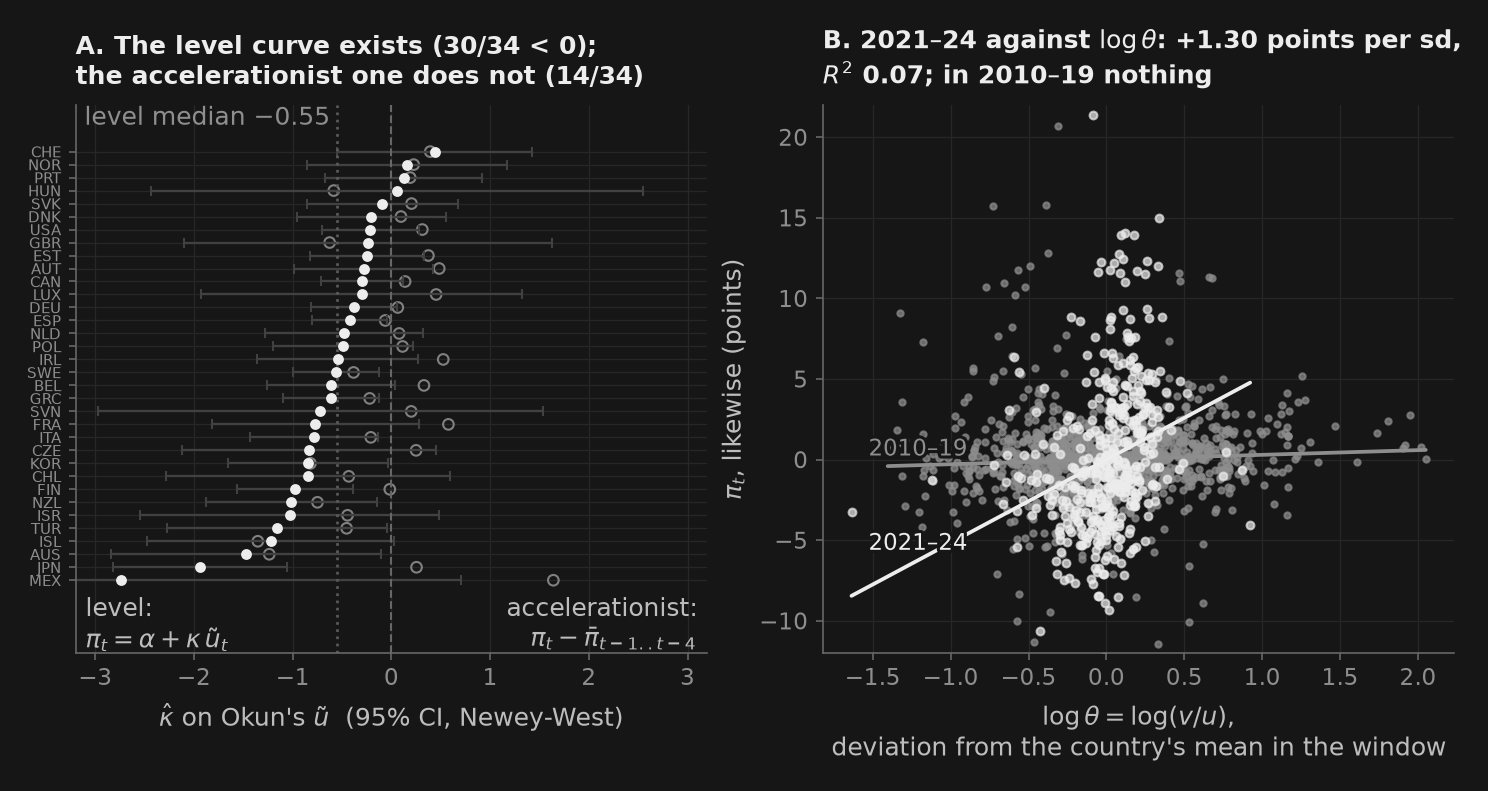

In [28]:
fig, (axK, axT) = _nbstyle.figura(1, 2, alto=True)

o = ph.sort_values("kappa")
yy = np.arange(len(o))
axK.errorbar(o["kappa"], yy, xerr=1.96 * o["se"], fmt="o", color=cols[0], ecolor=_nbstyle.gris("0.7"),
             elinewidth=1.1, capsize=2.2, ms=4.2, lw=0)
axK.scatter(o["kappa(accel)"], yy, s=26, facecolors="none", edgecolors=_nbstyle.gris("0.35"), lw=1.0)
med = float(o["kappa"].median())
axK.axvline(med, color=_nbstyle.gris("0.55"), ls=":", lw=1.3)
axK.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
axK.set_yticks(yy); axK.set_yticklabels(o.index, fontsize=7.2); axK.set_ylim(-5.6, len(o) + 2.6)
axK.set_xlim(-3.2, 3.2)
axK.set_xlabel("$\\hat\\kappa$ on Okun's $\\tilde u$  (95% CI, Newey-West)")
axK.set_title(f"A. The level curve exists ({n_lev}/{len(lev)} < 0);\n"
              f"the accelerationist one does not ({n_acc}/{len(acc)})")
# The two markers, named below the bottom row (where they sit farthest apart),
# and the median at the top of its line, instead of a legend.
axK.annotate("level:\n$\\pi_t = \\alpha + \\kappa\\,\\tilde u_t$", xy=(-3.1, -1.1),
             ha="left", va="top", color=_nbstyle.TEXTO)
axK.annotate("accelerationist:\n$\\pi_t - \\bar\\pi_{t-1..t-4}$", xy=(3.1, -1.1),
             ha="right", va="top", color=_nbstyle.TEXTO)
axK.annotate(f"level median ${med:+.2f}$", xy=(med, len(o) + 0.6), xytext=(-3, 0),
             textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)

for w, col, s_, lab_ in (("2010-19", _nbstyle.NOTA, 9, "2010–19"), ("2021-24", cols[0], 14, "2021–24")):
    g = epi[epi["window"] == w]
    axT.scatter(g["log_theta"], g["pi"], s=s_, color=col, alpha=0.7, zorder=2)
    b = np.polyfit(g["log_theta"], g["pi"], 1)
    _xx = np.linspace(g["log_theta"].min(), g["log_theta"].max(), 20)
    axT.plot(_xx, np.polyval(b, _xx), color=col, lw=1.8, ls="-", label=lab_)
axT.set_xlabel("$\\log\\theta = \\log(v/u)$,\ndeviation from the country's mean in the window")
axT.set_ylabel("$\\pi_t$, likewise (points)")
axT.set_ylim(-12, 22)
_pt = slopes.loc[("2021-24", "pi", "log_theta")]
axT.set_title(f"B. 2021–24 against $\\log\\theta$: {_pt['per sd(x)']:+.2f} points per sd,\n"
              f"$R^2$ {_pt['R2']:.2f}; in 2010–19 nothing")
_nbstyle.etiquetar(axT, donde=-1.2)
plt.show()


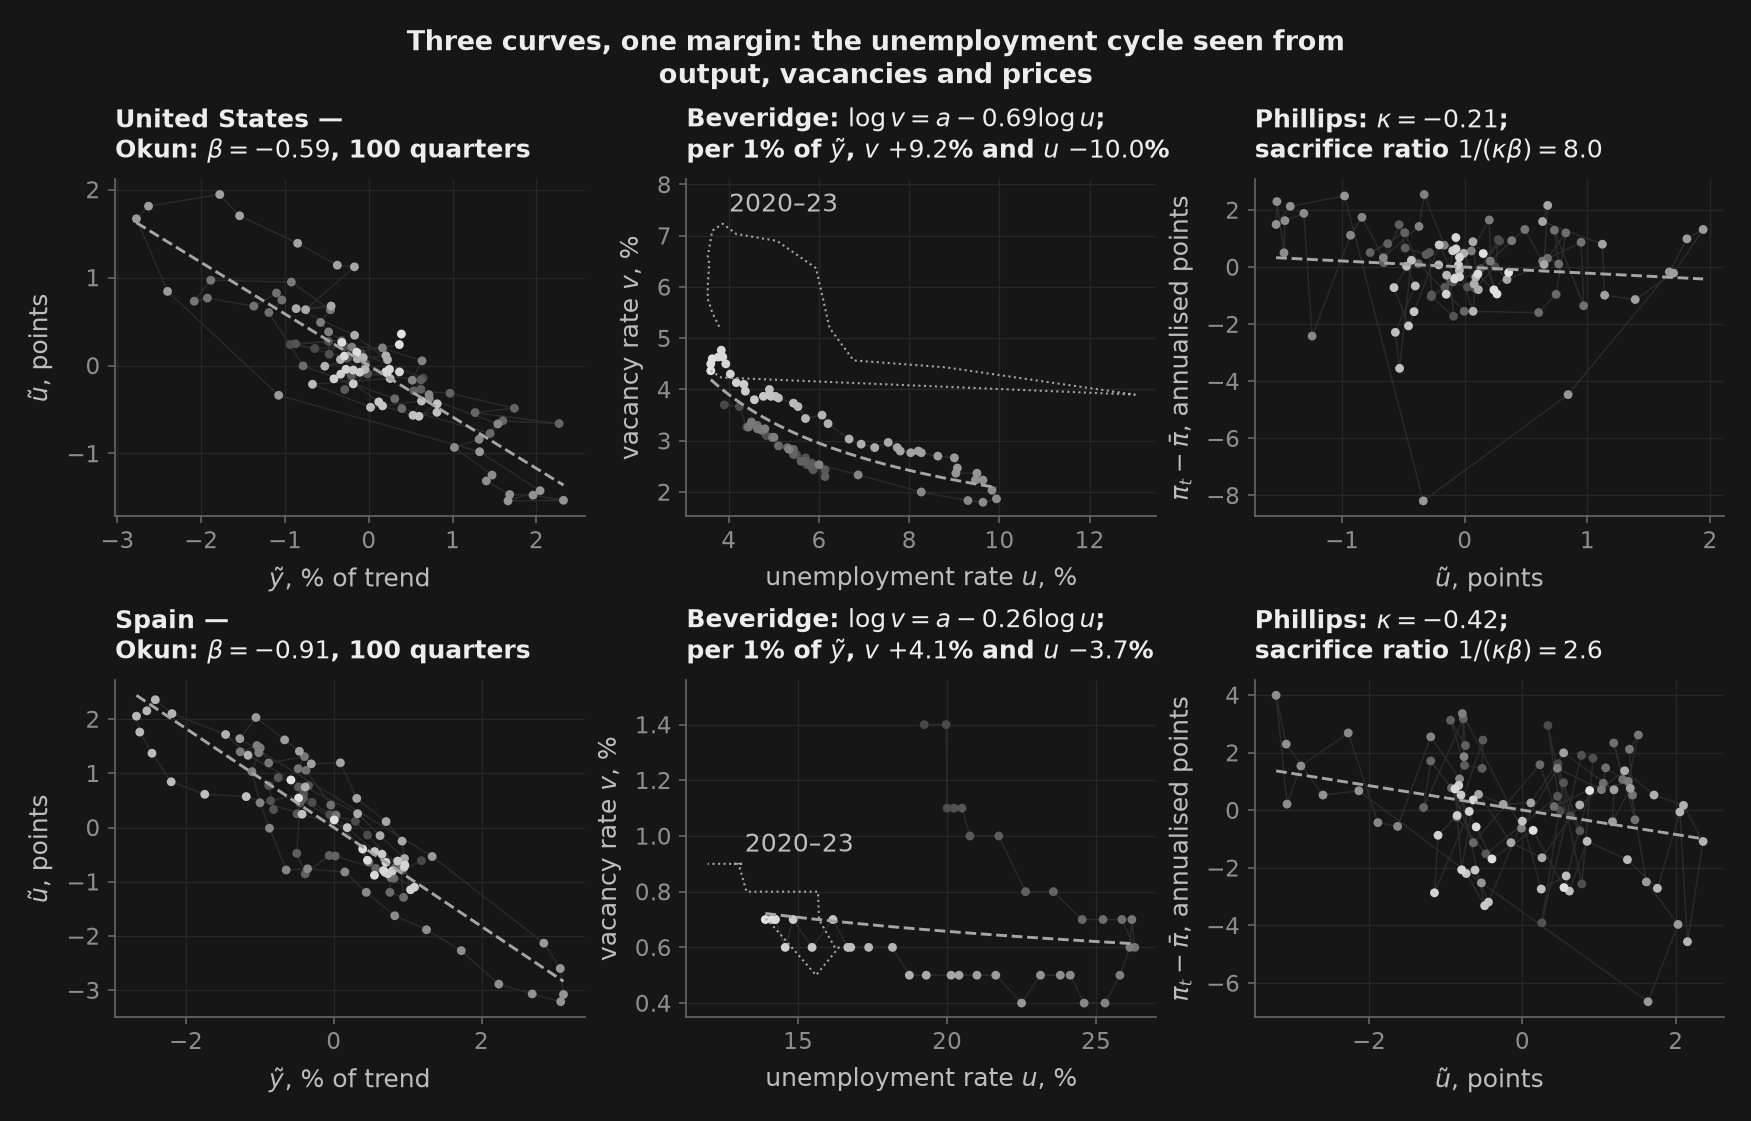

In [29]:
# Three curves, one margin: the same unemployment cycle seen from output (Okun,
# §5.1), from vacancies (Beveridge, §5.2) and from prices (Phillips, §5.3), in
# the two countries the lesson has been following. Faint for the first
# quarters and full ink for the last, as in T01_B §5.2, so that each cloud reads
# as a path. The 2020-23 loop is dotted: it is the episode, not the cycle.
HEROES = (("USA", "United States"), ("ESP", "Spain"))


def _path(ax, x, y):
    ax.plot(x, y, color=_nbstyle.gris("0.85"), lw=0.7, ls="-", zorder=1)
    ax.scatter(x, y, c=np.linspace(0.22, 0.95, len(x)), cmap="mav_seq",
               vmin=0, vmax=1, s=18, zorder=2, edgecolor="none")


fig, axes = _nbstyle.figura(2, 3)
for row, (code, name) in enumerate(HEROES):
    axO, axB, axP = axes[row]
    # Okun: the same (ỹ, ũ) pair §5.1 estimated; the line is its beta.
    d = pd.concat([volumen("gdp", code).dropna().rename("y"), URATE[code].rename("u")],
                  axis=1, sort=True).dropna().loc[:HASTA]
    yc = np.asarray(hp_filter(100.0 * np.log(d["y"]))[0])
    uc = u_cycle(code, URATE[code]).to_numpy()
    _p = np.polyfit(yc, uc, 1)
    assert abs(_p[0] - ok.loc[code, "beta"]) < 1e-9
    _path(axO, yc, uc)
    gx = np.linspace(yc.min(), yc.max(), 20)
    axO.plot(gx, np.polyval(_p, gx), color=_nbstyle.S2["color"], lw=1.4, ls="--")
    axO.set_xlabel("$\\tilde y$, % of trend"); axO.set_ylabel("$\\tilde u$, points")
    axO.set_title(f"{name} —\nOkun: $\\beta = {ok.loc[code, 'beta']:+.2f}$, "
                  f"{int(ok.loc[code, 'n'])} quarters")
    # Beveridge: levels before 2020 with T01_B's curve, and the 2020-23 loop on top.
    s = lab.loc[code][["urate", "vrate"]].dropna()
    pre, loop = s.loc[:HASTA], s.loc["2019-10-01":"2023-12-31"]
    _path(axB, pre["urate"].to_numpy(), pre["vrate"].to_numpy())
    axB.plot(loop["urate"], loop["vrate"], color=_nbstyle.S2["color"], lw=1.0, ls=":", zorder=3)
    # The loop, named at its highest point (the vacancy peak): the only stretch
    # of it that leaves the cloud. A little headroom so the name fits.
    _i = int(np.argmax(loop["vrate"].to_numpy()))
    axB.annotate("2020–23", (loop["urate"].iloc[_i], loop["vrate"].iloc[_i]), xytext=(3, 3),
                 textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TEXTO)
    gx = np.linspace(pre["urate"].min(), pre["urate"].max(), 40)
    _a = np.log(pre["vrate"]).mean() - bv.loc[code, "b"] * np.log(pre["urate"]).mean()
    # The curve's equation goes in the title: there is no clean spot on the cloud.
    axB.plot(gx, np.exp(_a + bv.loc[code, "b"] * np.log(gx)), color=_nbstyle.S2["color"], lw=1.4, ls="--")
    axB.set_xlabel("unemployment rate $u$, %"); axB.set_ylabel("vacancy rate $v$, %")
    axB.set_title(f"Beveridge: $\\log v = a {bv.loc[code, 'b']:+.2f}\\log u$;\n"
                  f"per 1% of $\\tilde y$, $v$ ${bv.loc[code, 'el(v)']:+.1f}$% and "
                  f"$u$ ${bv.loc[code, 'el(u)']:+.1f}$%")
    _y0, _y1 = axB.get_ylim(); axB.set_ylim(_y0, _y1 + 0.10 * (_y1 - _y0))
    # Phillips: pi minus its mean (the anchor) against the same ũ; the line is kappa.
    m = phillips_sample(code, URATE[code])
    dpi = (m["pi"] - m["pi"].mean()).to_numpy()
    _q = np.polyfit(m["u"].to_numpy(), dpi, 1)
    assert abs(_q[0] - ph.loc[code, "kappa"]) < 1e-9
    _path(axP, m["u"].to_numpy(), dpi)
    gx = np.linspace(m["u"].min(), m["u"].max(), 20)
    axP.plot(gx, np.polyval(_q, gx), color=_nbstyle.S2["color"], lw=1.4, ls="--")
    axP.set_xlabel("$\\tilde u$, points"); axP.set_ylabel("$\\pi_t - \\bar\\pi$, annualised points")
    axP.set_title(f"Phillips: $\\kappa = {ph.loc[code, 'kappa']:+.2f}$;\nsacrifice ratio "
                  f"$1/(\\kappa\\beta) = {sac.loc[code, 'ratio']:.1f}$")
fig.suptitle("Three curves, one margin: the unemployment cycle seen from\n"
             "output, vacancies and prices")
plt.show()


### 5.4 Macroeconomic Experiment 1: The Great Recession vs. COVID-19 Three-Margin Decomposition & Filter Distortion Stress Test

#### Economic Motivation & The Lucas Critique
In §2 we established the foundational arithmetic accounting identity:

$$ \Delta\log Y = \Delta\log(Y/H) + \Delta\log(H/E) + \Delta\log E $$

Every economic crisis is an empirical mixture of these three margins: labor productivity ($Y/H$), the intensive margin (hours per worker $H/E$), and the extensive margin (employment $E$).

Why do two economies facing comparable external contractions exhibit diametrically opposed adjustment patterns?
1. **The 2008 Great Financial Crisis (GFC):** In 2008, Germany hoarded labor via *Kurzarbeit* (state-subsidized short-time work schemes) and firm-level working-time accounts (*Arbeitszeitkonten*), compressing average hours worked ($H/E$) while holding employment ($E$) virtually flat. In Spain, an institutional regime of extreme dual Employment Protection Legislation (EPL) meant that firms bore minimal dismissal costs for temporary workers (over 30% of the workforce); Spanish firms absorbed the shock through brutal employment destruction ($E$).
2. **The Countercyclical Productivity Paradox:** Because the Spanish workers dismissed during the GFC were disproportionately low-tenure, low-skilled workers in construction and services with below-average productivity, aggregate measured labor productivity ($Y/H$) mechanically surged (+3.1 log points) during a devastating recession! This is a pure composition effect, not a technological boom.
3. **The 2020 COVID-19 Pandemic Regime Switch:** During COVID-19, Spain instituted ERTEs (*Expedientes de Regulación Temporal de Empleo*), functionally importing the German *Kurzarbeit* model. In accordance with the **Lucas Critique** (Lucas 1976), changing the labor policy rule endogenously transformed private sector behavior: Spain's 2020 downturn was absorbed overwhelmingly along the intensive margin ($\Delta\log(H/E) \approx -21.5\%$), mimicking Germany!
4. **Filter Distortion Stress Test:** How does econometric detrending distort structural moments during extreme crises? Confronted with the massive 2020 non-Gaussian tail shock, the two-sided HP filter ($\lambda=1600$) suffers severe boundary distortion, pulling the trend downward and retroactively manufacturing artificial cyclical booms in the pre-crisis quarters (revising 2019Q4 output gap by over +2.7 percentage points).

#### Guided Student Tasks:
1. **Implement Exact Three-Margin Decomposition:** Write `three_margin_decomposition(code, t_peak, t_trough)` extracting chained real GDP ($Y = \text{gdp}/\text{gdp\_defl} \times 100$), employment ($E$), and hours worked ($H$) from `_datos.gasto()` and `_datos.mercado_laboral()`. Verify the exact arithmetic identity $\Delta\log Y = \Delta\log(Y/H) + \Delta\log(H/E) + \Delta\log E$.
2. **Stress-Test 2008 GFC (Germany vs. Spain):** Decompose the peak-to-trough contraction (2008Q1 to 2009Q2 for DEU; 2008Q1 to 2009Q3 for ESP). Quantify the intensive vs. extensive margin shares and verify the countercyclical Spanish productivity paradox.
3. **Analyze 2020 COVID-19 Shock:** Decompose the 2019Q4 to 2020Q2 collapse. Document how job-retention schemes (ERTEs / Kurzarbeit) shifted the burden of adjustment to the intensive margin in both economies.
4. **Evaluate Filter End-Point Sensitivity:** Compute HP-filtered cycles on 2015–2019 vs. 2015–2021 for Germany and Spain. Quantify the retrospective revision to pre-crisis gaps caused by the pandemic tail shock.

=== Macroeconomic Experiment 1: Three-Margin Decomposition ===
               Country  Delta log Y (%)  Productivity Y/H (%)  Intensive H/E (%)  Extensive E (%)  Identity Residual
Episode                                                                                                             
DEU 2008 GFC       DEU            -7.04                 -3.63              -3.77            +0.36              +0.00
ESP 2008 GFC       ESP            -4.19                 +3.07              +1.72            -8.97              +0.00
DEU 2020 COVID     DEU           -11.26                 -2.97              -7.01            -1.28              +0.00
ESP 2020 COVID     ESP           -24.91                 +5.12             -21.49            -8.53              +0.00


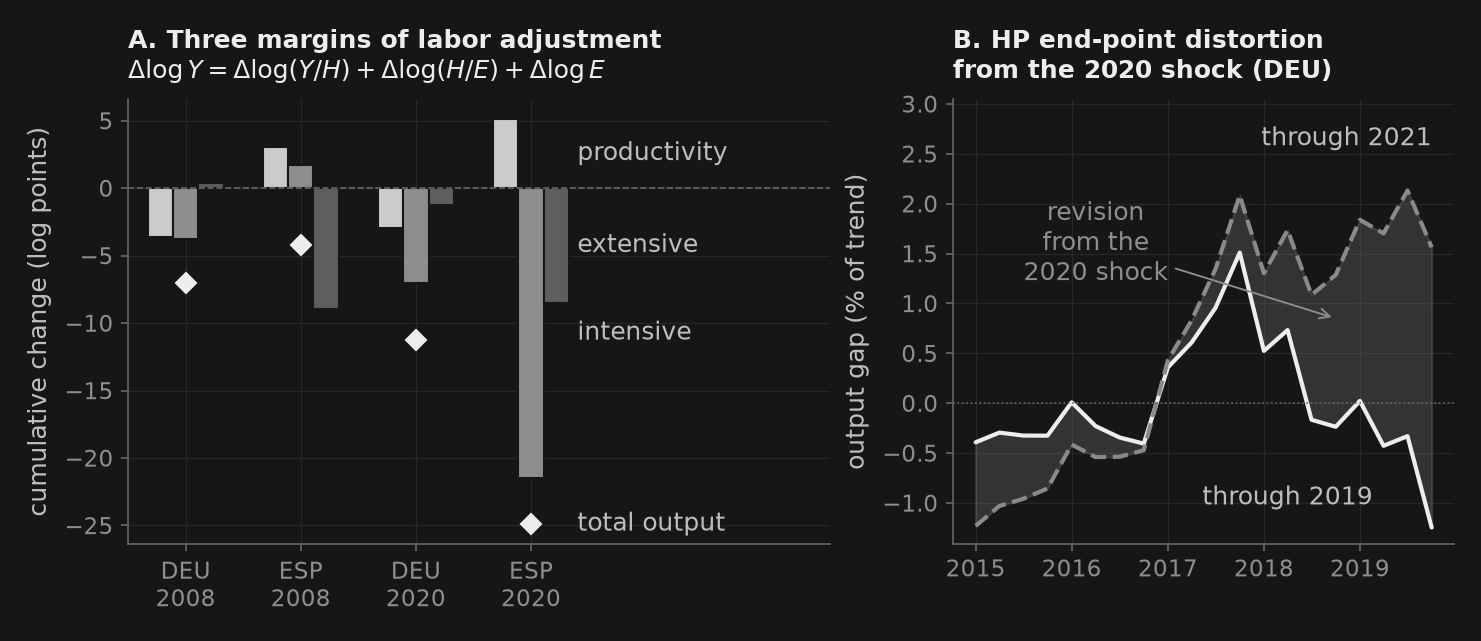

In [30]:
# --- Macroeconomic Experiment 1: Three-Margin Labor Decomposition ---

def three_margin_decomposition(code, t_peak, t_trough):
    """Peak-to-trough three-margin decomposition of output growth.

    Identifies:
      dy = d_prod + d_intens + d_extens
    where:
      dy = Delta log(Y)
      d_prod = Delta log(Y/H) (Productivity)
      d_intens = Delta log(H/E) (Hours per worker / Intensive margin)
      d_extens = Delta log(E) (Employment / Extensive margin)
    """
    pib = gas.xs(code)["gdp"] / gas.xs(code)["gdp_defl"] * 100.0
    l_df = lab.xs(code)

    y = np.log(pib)
    e = np.log(l_df["emp"])
    h = np.log(l_df["hours"])

    dy = 100.0 * (y.loc[t_trough] - y.loc[t_peak])
    de = 100.0 * (e.loc[t_trough] - e.loc[t_peak])
    dh = 100.0 * (h.loc[t_trough] - h.loc[t_peak])

    d_prod = dy - dh          # Output per hour
    d_intens = dh - de        # Hours per worker
    d_extens = de             # Employment

    return {
        "code": code,
        "peak": t_peak,
        "trough": t_trough,
        "dy": dy,
        "d_prod": d_prod,
        "d_intens": d_intens,
        "d_extens": d_extens,
    }


# Evaluate GFC (2008) and COVID-19 (2020) episodes
esp_gfc = three_margin_decomposition("ESP", "2008-01-01", "2009-07-01")
deu_gfc = three_margin_decomposition("DEU", "2008-01-01", "2009-04-01")
esp_cov = three_margin_decomposition("ESP", "2019-10-01", "2020-04-01")
deu_cov = three_margin_decomposition("DEU", "2019-10-01", "2020-04-01")

# Format comparative decomposition table
exp_results = [
    ("DEU 2008 GFC", deu_gfc),
    ("ESP 2008 GFC", esp_gfc),
    ("DEU 2020 COVID", deu_cov),
    ("ESP 2020 COVID", esp_cov),
]

df_decomp = pd.DataFrame([
    {
        "Episode": label,
        "Country": r["code"],
        "Delta log Y (%)": r["dy"],
        "Productivity Y/H (%)": r["d_prod"],
        "Intensive H/E (%)": r["d_intens"],
        "Extensive E (%)": r["d_extens"],
        "Identity Residual": r["dy"] - (r["d_prod"] + r["d_intens"] + r["d_extens"]),
    }
    for label, r in exp_results
]).set_index("Episode")

print("=== Macroeconomic Experiment 1: Three-Margin Decomposition ===")
print(df_decomp.to_string(float_format=lambda x: f"{x:+.2f}"))

# Visualize: A (three margins) and B (HP filter end-point distortion)
# On export to a slide the figure inherits the slot's size; in the notebook it
# keeps the usual two-panel size.
_ranura = plt.rcParams["figure.figsize"] if _nbstyle.PERFIL == "lamina" else None
fig, (ax_m, ax_f) = _nbstyle.figura(1, 2, gridspec_kw={"width_ratios": [1.4, 1]},
                                    figsize=_ranura)

labels = [item[0] for item in exp_results]
x_pos = np.arange(len(labels))
w = 0.22

d_prods = [item[1]["d_prod"] for item in exp_results]
d_intenss = [item[1]["d_intens"] for item in exp_results]
d_extenss = [item[1]["d_extens"] for item in exp_results]
d_ys = [item[1]["dy"] for item in exp_results]

ax_m.bar(x_pos - w, d_prods, w, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO)
ax_m.bar(x_pos, d_intenss, w, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO)
ax_m.bar(x_pos + w, d_extenss, w, color=_nbstyle.BARRA_COLORES[2], edgecolor=_nbstyle.FONDO)
ax_m.plot(x_pos, d_ys, marker="D", color=_nbstyle.TINTA, linestyle="",
          markersize=plt.rcParams["lines.markersize"] + 1.5)

ax_m.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls="--")
ax_m.set_xticks(x_pos)
# Country and year name the episode, and two short lines fit under the 0.4-inch
# bars of the slot.
ax_m.set_xticklabels([f"{e.split()[0]}\n{e.split()[1]}" for e in labels])
ax_m.set_ylabel("cumulative change (log points)")
# The identity goes in the title (the notebook keeps it; on the slide the frame
# head says the same), so the bars' names fit beside them.
ax_m.set_title("A. Three margins of labor adjustment\n"
               r"$\Delta\log Y=\Delta\log(Y/H)+\Delta\log(H/E)+\Delta\log E$")
# The names to the right of the last episode (the one with the longest bars), at
# the height of the bar or dot they name, instead of a legend.
ax_m.set_xlim(-0.5, len(labels) + 1.6)
for label, y in (("productivity", d_prods[-1] / 2.0),
                 ("intensive", d_intenss[-1] / 2.0),
                 ("extensive", d_extenss[-1] / 2.0),
                 ("total output", d_ys[-1])):
    ax_m.annotate(label, xy=(x_pos[-1] + w * 1.5, y), xytext=(4, 0),
                  textcoords="offset points", ha="left", va="center", color=_nbstyle.TEXTO)

# Panel B: HP filter end-point distortion (Germany)
pib_deu = gas.xs("DEU")["gdp"] / gas.xs("DEU")["gdp_defl"] * 100.0
y_deu_pre = 100.0 * np.log(pib_deu.loc["2015-01-01":"2019-12-31"])
y_deu_full = 100.0 * np.log(pib_deu.loc["2015-01-01":"2021-12-31"])

hp_pre, _ = hp_filter(y_deu_pre, lamb=1600)
hp_full, _ = hp_filter(y_deu_full, lamb=1600)

dates_plot = hp_pre.index
ax_f.plot(dates_plot, hp_pre, label="through 2019", color=cols[0])
ax_f.plot(dates_plot, hp_full.loc[dates_plot], label="through 2021", color=cols[3], ls="--")
ax_f.fill_between(dates_plot, hp_pre, hp_full.loc[dates_plot], color=cols[3], alpha=0.25)

ax_f.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax_f.set_ylabel("output gap (% of trend)")
ax_f.set_title("B. HP end-point distortion\nfrom the 2020 shock (DEU)")
# The two samples' names go in the panel's two clean pockets: under the short
# line, and in a lane opened above for the long one.  `etiquetar` writes them
# tight against the line, and at slot width the long sample's quarterly zigzag
# eats them.
_techo = ax_f.get_ylim()[1]
ax_f.set_ylim(top=_techo + 0.75)
ax_f.annotate("through 2019", xy=(pd.Timestamp("2018-04-01"), -0.95),
              ha="center", va="center", color=_nbstyle.TEXTO)
ax_f.annotate("through 2021", xy=(dates_plot[-1], _techo + 0.35),
              ha="right", va="center", color=_nbstyle.TEXTO)
# The band's name in the empty top-left corner, with an arrow to it: written
# inside, it crossed the short-sample line.
ax_f.annotate("revision\nfrom the\n2020 shock", xy=(pd.Timestamp("2018-10-01"), 0.85),
              xytext=(pd.Timestamp("2016-04-01"), 1.6), ha="center", va="center",
              color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
plt.show()


In [31]:
# --- Macroeconomic Experiment 1: Automated Verification & Diagnostic Assertions ---

# 1. Verify exact arithmetic identity for all decompositions
for label, r in exp_results:
    residual = abs(r["dy"] - (r["d_prod"] + r["d_intens"] + r["d_extens"]))
    assert residual < 1e-6, f"Identity failure in {label}: residual = {residual}"

# 2. Verify GFC Spain productivity paradox & extensive collapse
assert esp_gfc["d_prod"] > 0, "Spain measured productivity must rise in 2008 GFC (composition effect)"
assert esp_gfc["d_extens"] < -5.0, "Spain extensive margin must show severe contraction in 2008 GFC"

# 3. Verify GFC Germany Kurzarbeit labor hoarding (intensive adjustment)
assert deu_gfc["d_intens"] < -2.0, "Germany must adjust heavily via hours per worker in 2008 GFC"
assert deu_gfc["d_extens"] > -1.0, "Germany employment must remain resilient in 2008 GFC"

# 4. Verify COVID-19 institutional shift (intensive margin dominates in both countries)
assert esp_cov["d_intens"] < -15.0, "Spain intensive margin must collapse in 2020 COVID due to ERTEs"
assert deu_cov["d_intens"] < -5.0, "Germany intensive margin must absorb COVID shock via Kurzarbeit"

# 5. Verify HP filter end-point distortion magnitude
rev_2019q4 = float(hp_full.loc["2019-10-01"] - hp_pre.loc["2019-10-01"])
assert rev_2019q4 > 1.5, f"Expected >1.5 pp revision in 2019Q4 HP gap, got {rev_2019q4:.2f} pp"

print("✓ Macroeconomic Experiment 1: All empirical and structural assertions verified successfully.")

✓ Macroeconomic Experiment 1: All empirical and structural assertions verified successfully.


#### Experiment 1 Findings & Theoretical Takeaways

1. **Institutions Rule the Margin of Adjustment:**
   - In the 2008 GFC, Germany's output drop of $-7.0\%$ was absorbed predominantly by shorter weeks ($-3.8\%$) and measured productivity ($-3.6\%$), with employment virtually unchanged ($+0.4\%$). German firms hoarded skilled labor because *Kurzarbeit* subsidized wage costs while preserving match capital.
   - Spain's 2008 output contraction of $-4.2\%$ was borne almost entirely by employment destruction ($-9.0\%$). Spain's EPL duality allowed firms to shed temporary workers with near-zero severance costs.
2. **The Countercyclical Productivity Paradox is a Composition Effect:**
   - Spanish output fell less than total hours worked because the destroyed jobs were in low-productivity sectors (construction, services). The statistical purge of the least productive workers caused aggregate output per hour to rise by $+3.1\%$ during the worst recession in modern Spanish history.
3. **The Lucas Critique in Action (2020 ERTEs):**
   - When COVID-19 hit in 2020, Spain did not repeat its 2008 adjustment. The Spanish government established ERTEs (*Expedientes de Regulación Temporal de Empleo*), directly subsidizing hours reductions and preventing layoffs. As predicted by the Lucas Critique, private sector behavior shifted endogenously: Spain absorbed $-21.5\%$ of its $-24.9\%$ GDP drop via the intensive margin ($H/E$), proving that labor market parameters are policy-dependent rather than technological invariants.
4. **The Peril of HP Filtering Around Tail Shocks:**
   - As demonstrated in Panel B, adding the extreme 2020 pandemic observations retroactively shifts the estimated HP output gap in 2019Q4 upwards by $+2.81$ percentage points. The two-sided filter pulls down the estimated potential output trend, falsely manufacturing a large cyclical boom right before the pandemic. For DSGE/RBC structural calibration, relying on two-sided filters around crisis episodes introduces profound Slutsky-type parameter bias.

## 6. Was any of it knowable at the time?

Every number so far was computed on today's data with today's full sample. A policymaker had neither. This section rebuilds the output gap **as it stood in every monthly edition from July 1999 to March 2020**, for the 39 economies in T01_B §4.1's archive whose history reaches back far enough, and asks how much of what we just measured was visible while it mattered. Editions stop in March 2020 and reference periods at 2019Q4, for §1.1's reason applied one level up: a *final* gap drawn through the pandemic is not the yardstick anything should be scored against.

A note on the archive, because it decides one of the figures below. For twelve of the forty-two areas the early editions carry the series **unadjusted** — 501 of the 11,434 that T01_B §4.1's screen scores, out of an archive of 11,503 — and an HP trend drawn through a seasonal factor is not an output gap. This section does with them exactly what T01_B §4.1 does: deseasonalize all 11,503 — the whole archive, including the 69 the screen never gets to score — with one and the same quarterly-dummy filter fitted within each edition, dropping none. Dropping the 501 — which is what this section used to do — deletes 149 of the 6,945 estimates below, and deletes them where the statistician weighs most: across the seven areas that lose them, the data part of the revision is 1.35 pp on the estimates that would go and 0.83 pp on the ones that stay, while the filter part goes the other way. The treatment was not neutral for the split this section measures, so the two lessons share it.

Orphanides & van Norden (2002) showed for the United States that the real-time output gap is revised so heavily that it is nearly useless for policy — and, crucially, that most of the revision is **not** the fault of the statisticians. There are two separate problems, and they can be told apart:

| | what it uses | what it isolates |
|---|---|---|
| **final** | today's data, whole sample to 2019Q4 | the answer we believe now |
| **quasi-real-time** | today's data, truncated at $t$ | the **filter end-point** problem: an HP trend at the end of a sample has no future to lean on |
| **real-time** | the data actually published at $t$ | adds the **data revision** problem on top |

and because $(\text{final} - \text{real-time}) = \underbrace{(\text{final} - \text{quasi})}_{\text{end-point}} + \underbrace{(\text{quasi} - \text{real-time})}_{\text{data}}$ exactly, the two sources can be added up and compared. This is where T01_B §4.1's archive earns its keep a second time: there it measured whether revisions are news or noise, and here it measures what those revisions did to the one number a central bank actually wants.

In [32]:
from puremacro.fetch.realtime import (VintagePanel, seasonal_signature,
                                      SEASONAL_MIN_OBS, SEASONAL_WINDOW)

VINTAGE_SNAPSHOT = DATOS / "oecd_stes_vintages_gdp.csv.gz"
#: The archive carries an unadjusted series in some early editions, and an HP
#: trend drawn through a seasonal is not an output gap. The SCREEN that detects
#: them lives in puremacro, and the TREATMENT is T01_B §4.1's: both lessons
#: deseasonalize EVERY edition in the archive with one and the same
#: quarterly-dummy filter fitted within each edition, and drop none. There is
#: no longer any way for them to disagree — neither about which editions are
#: unadjusted, nor about what to do with them.
MIN_RT = 40


def real_time_panel(path):
    s = pd.read_csv(path, dtype={"edition": str})
    return VintagePanel(df=pd.DataFrame({
        "country": s["code"].astype(str), "variable": s["variable"].astype(str),
        "date": pd.PeriodIndex(s["date"].astype(str), freq="Q").to_timestamp(),
        "vintage": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": pd.to_numeric(s["value"]), "provider": "oecd_stes",
        "series_id": s["code"].astype(str) + ".Q.B1GQ_Q...", "units": "level"}))


# The body of the function is T01_B §4.1's, character for character: it is the
# treatment and not the screen, so it lives in the notebook and in plain sight
# — the screen is the part that lives in puremacro — and the two lessons have
# to apply the same one. The only thing that changes is the docstring's last
# sentence, which points at T01_B §4.1 because the X-13 check lives there and
# not here.
def deseasonalize_editions(p, sig=None, window=SEASONAL_WINDOW,
                           min_obs=SEASONAL_MIN_OBS):
    """One and the same seasonal filter over EVERY edition of the archive.

    The filter is the exact reverse of the screen: `seasonal_signature` detects
    an unadjusted edition by comparing the four quarterly means of the log
    growth *of that same edition*, and this subtracts those four means. On the
    level it amounts to dividing by a multiplicative seasonal factor, because
    the running sum of four centred means is periodic with period four; on the
    growth rate — which is what the Mankiw-Shapiro regression uses — it amounts
    to a quarterly-dummy adjustment.

    Three properties make it admissible on a real-time archive:

    1. **It does not look ahead.** Each edition is adjusted with the quarters
       that edition contained, and none after. The May 2001 edition is
       deseasonalized with what was known in May 2001.
    2. **It is invariant to rebasing.** Multiplying a whole edition by a
       constant leaves its log growth unchanged, hence its quarterly means and
       the factor subtracted from it.
    3. **It is a no-op where the office already did the work.** Already
       adjusted editions keep a residual seasonal of tenths of a point;
       removing it moves them in the fourth decimal.

    It is deliberately blunt — it chases neither moving seasonality nor
    calendar effects nor outliers, which is what X-13 does — and deliberately
    cheap: eleven thousand editions in a couple of seconds, no external
    binaries, on a tablet. T01_B §4.1 checks it against X-13 where most is at
    stake.

    Returns ``(VintagePanel, receipt)``; the receipt says, area by area, how
    much seasonality its worst edition carried before and after.
    """
    lo, hi = pd.Timestamp(window[0]), pd.Timestamp(window[1])
    pieces, short_n = [], 0
    for (country, var), sub in p.df.groupby(["country", "variable"], sort=True):
        piv = (sub.pivot_table(index="date", columns="vintage", values="value")
                  .sort_index())
        lg = np.log(piv)
        g = lg.diff()
        q = pd.Index(g.index.quarter)
        inside = (g.index >= lo) & (g.index < hi)
        qi = q[inside]
        m = g[inside].groupby(qi).mean().reindex([1, 2, 3, 4])
        n_q = g[inside].groupby(qi).count().reindex([1, 2, 3, 4]).fillna(0)
        # The very few editions that do not reach min_obs inside the window —
        # the earliest ones, ending in 1998 — are estimated on their whole
        # sample, which for them is entirely pre-pandemic anyway.
        short = n_q.sum() < min_obs
        if short.any():
            whole = g.groupby(q).mean().reindex([1, 2, 3, 4])
            mask = short.to_numpy()
            m.loc[:, mask] = whole.loc[:, mask]
            short_n += int(short.sum())
        m = m.fillna(0.0)
        m = m - m.mean(axis=0)      # centred: the profile goes, the mean stays
        factor = m.cumsum()          # periodic by construction: factor[4] = 0
        key = pd.MultiIndex.from_arrays(
            [sub["date"].dt.quarter, sub["vintage"]])
        pieces.append(sub.assign(
            value=sub["value"].to_numpy()
            * np.exp(-factor.stack().reindex(key).to_numpy())))
    out = pd.concat(pieces, ignore_index=True)
    adjusted = VintagePanel(df=out,
                            metadata={**p.metadata,
                                      "seasonal": "quarterly dummies within edition",
                                      "short_editions": short_n})
    # `sig` arrives ready-made because the cell already computed it for the
    # screen: scoring eleven thousand editions twice is a quarter of a second on
    # a desktop and considerably more on a tablet, for exactly the same numbers.
    before = seasonal_signature(p) if sig is None else sig
    after = seasonal_signature(adjusted)
    receipt = pd.concat(
        [before.groupby("country")["seasonal_range"].max().rename("range_before"),
         after.groupby("country")["seasonal_range"].max().rename("range_after"),
         before.groupby("country")["unadjusted"].sum().rename("flagged")],
        axis=1)
    return adjusted, receipt


if not _here(VINTAGE_SNAPSHOT):
    raise RuntimeError(
        f"No real-time archive at {VINTAGE_SNAPSHOT}. It is written by T01_B "
        f"§4.1 and travels in the course's data_curso/ folder; copy that folder "
        f"next to this notebook.")
raw = real_time_panel(VINTAGE_SNAPSHOT)
n_rows = len(raw.df)
# Two counts that must not be confused, because the prose uses both: how many
# editions the archive carries, and how many the screen SCORES. The screen
# needs 16 quarters inside 1995-2019 to estimate credible quarterly means, so
# the very earliest editions — the ones that end in 1998 — go unscored. The
# filter, by contrast, passes over every one of them.
n_editions = int(raw.df.groupby(["country", "variable", "vintage"]).ngroups)
sig = seasonal_signature(raw)
rev, receipt = deseasonalize_editions(raw, sig=sig)
# Which (area, edition) pairs the screen flags, so the cell below can say what
# dropping them would have cost. Dropping deletes exactly these and touches
# nothing else, so the cost is counted on the same table, with no second panel.
FLAGGED = set(map(tuple, sig.loc[sig["unadjusted"],
                                 ["country", "vintage"]]
                  .itertuples(index=False, name=None)))
raw = None          # 1.25 million rows that are no longer needed: on a tablet
                    # that is the difference between running and paging.

n_flagged = int(sig["unadjusted"].sum())
print(f"Real-time archive: {len(rev.countries)} areas, {len(rev):,} "
      f"(reference quarter x edition) observations.")
print(f"Screen (T01_B §4.1): {n_flagged} of {len(sig):,} scored editions "
      f"carry the unadjusted series,\n  in "
      f"{sig.loc[sig['unadjusted'], 'country'].nunique()} of "
      f"{len(rev.countries)} areas. The archive carries {n_editions:,} "
      f"editions; the\n  {n_editions - len(sig)} the screen does not score "
      f"fall short of 16 quarters inside 1995-2019.")
print(f"Treatment (T01_B §4.1's own): a quarterly-dummy filter fitted within "
      f"each edition,\n  over all {n_editions:,} of them —including the ones "
      f"the screen does not score— and not over\n  the {n_flagged} flagged "
      f"ones. {n_rows:,} rows in and {len(rev.df):,} out: none is dropped. "
      f"The worst area's\n  seasonality goes from "
      f"{receipt['range_before'].max():.1f} pp to "
      f"{receipt['range_after'].max():.2f} pp.")

# Guards: the screen has to find something, the filter has to leave the whole
# archive standing, and the seasonality the screen measures has to be gone.
assert n_flagged > 0
assert len(rev.df) == n_rows
assert len(rev.countries) == 42
assert n_editions == 11503 and len(sig) == 11434   # archive / scored
assert float(receipt["range_after"].max()) < 1e-6

Real-time archive: 42 areas, 1,249,388 (reference quarter x edition) observations.
Screen (T01_B §4.1): 501 of 11,434 scored editions carry the unadjusted series,
  in 12 of 42 areas. The archive carries 11,503 editions; the
  69 the screen does not score fall short of 16 quarters inside 1995-2019.
Treatment (T01_B §4.1's own): a quarterly-dummy filter fitted within each edition,
  over all 11,503 of them —including the ones the screen does not score— and not over
  the 501 flagged ones. 1,249,388 rows in and 1,249,388 out: none is dropped. The worst area's
  seasonality goes from 61.8 pp to 0.00 pp.


In [33]:
# The same 2019Q4 cut as the rest of the lesson, and for the same reason: an
# HP trend drawn through 2020 is contaminated on both sides of it, and here it
# would contaminate the FINAL gap that every real-time estimate is scored
# against. So reference periods stop at 2019Q4 and editions stop at 2020-03,
# which is the last one whose newest quarter is still inside the sample.
LAST_Q = pd.Timestamp(HASTA)
LAST_ED = pd.Timestamp("2020-03-01")

rows = []
for code, sub in rev.df.groupby("country", sort=True):
    piv = (sub.pivot_table(index="date", columns="vintage", values="value")
              .sort_index().loc["1980-01-01":HASTA])
    final = piv[piv.columns.max()].dropna()
    if len(final) < 60:
        continue
    lf = 100.0 * np.log(final)
    gap_final = pd.Series(np.asarray(hp_filter(lf)[0]), index=lf.index)
    for v in piv.columns:
        if v > LAST_ED:
            continue
        col = piv[v].dropna()
        col = col[col.index <= v]           # nothing published after the edition
        if len(col) < MIN_RT:
            continue
        t = col.index[-1]                   # the quarter this edition just added
        if t not in gap_final.index:
            continue
        trunc = lf[lf.index <= t]
        if len(trunc) < MIN_RT:
            continue
        rows.append({
            "code": code, "vintage": v, "date": t,
            "rt": float(np.asarray(hp_filter(100.0 * np.log(col))[0])[-1]),
            "qrt": float(np.asarray(hp_filter(trunc)[0])[-1]),
            "final": float(gap_final.loc[t])})
rt = pd.DataFrame(rows)
rt["rev_total"] = rt["final"] - rt["rt"]
rt["rev_endpoint"] = rt["final"] - rt["qrt"]
rt["rev_data"] = rt["qrt"] - rt["rt"]
rt["flagged"] = [(c, v) in FLAGGED
                 for c, v in zip(rt["code"], rt["vintage"])]
assert (rt["rev_endpoint"] + rt["rev_data"] - rt["rev_total"]).abs().max() < 1e-9
print(f"{len(rt):,} real-time output gap estimates across "
      f"{rt['code'].nunique()} areas, from the editions of "
      f"{rt['vintage'].min():%Y-%m} to {rt['vintage'].max():%Y-%m}.\n")


def _rmse(x):
    return float(np.sqrt(np.mean(np.square(x))))


def _shares(g):
    """Split var(total revision) between its two additive parts, exactly.

    Since total = end-point + data, cov(part, total) / var(total) for the two
    parts sums to exactly 1 — which the naive var(part)/var(total) does not,
    because the two parts are correlated. A share above 1 is then meaningful
    rather than an arithmetic embarrassment: it says the other part moves
    against the total, i.e. data revisions partly OFFSET the filter's error.
    """
    v = g["rev_total"].var()
    return (float(g["rev_endpoint"].cov(g["rev_total"]) / v),
            float(g["rev_data"].cov(g["rev_total"]) / v))


ov = rt.groupby("code").apply(lambda g: pd.Series({
    "n": len(g),
    "sd(final gap)": g["final"].std(ddof=1),
    "corr(rt, final)": g["rt"].corr(g["final"]),
    "rmse(revision)": _rmse(g["rev_total"]),
    "noise/signal": _rmse(g["rev_total"]) / g["final"].std(ddof=1),
    "share end-point": _shares(g)[0],
    "share data": _shares(g)[1],
    "wrong sign": float((np.sign(g["rt"]) != np.sign(g["final"])).mean()),
}), include_groups=False)
assert (ov["share end-point"] + ov["share data"] - 1.0).abs().max() < 1e-9
print(ov.sort_values("noise/signal", ascending=False).round(2).to_string())

m = ov.median(numeric_only=True)
print(f"\n--- the median economy ---")
print(f"  the revision to the gap is {m['noise/signal']:.2f} times as big as the "
      f"gap's own standard deviation")
print(f"  real-time and final gaps correlate {m['corr(rt, final)']:.2f}")
print(f"  they disagree about the SIGN of the gap "
      f"{m['wrong sign']:.0%} of the time — whether the economy was above or "
      f"below trend at all")
print(f"  and the revision splits {m['share end-point']:.0%} / "
      f"{m['share data']:.0%} between the filter's end-point problem and the "
      f"data revision — the statisticians are the smaller half by a long way")
_offset = int((ov["share data"] < 0).sum())
if _offset:
    print(f"  in {_offset} areas the data share is NEGATIVE: revisions to the "
          f"data on average push the gap back TOWARDS the final answer, "
          f"partly offsetting the filter")
_worst, _best = ov["wrong sign"].idxmax(), ov["wrong sign"].idxmin()
assert ov.loc[_best, "n"] == ov["n"].min()   # the best is also the shortest
print(f"\n  worst: {_worst} gets the sign wrong "
      f"{ov.loc[_worst, 'wrong sign']:.0%} of the time, on "
      f"{int(ov.loc[_worst, 'n'])} estimates. Best: {_best} at\n  "
      f"{ov.loc[_best, 'wrong sign']:.0%}, on only {int(ov.loc[_best, 'n'])} — "
      f"the shortest sample in the panel, against a median of "
      f"{int(ov['n'].median())}: the two\n  ends of this column do not carry "
      f"the same weight.")

# And what this section's previous treatment — dropping the flagged editions —
# would have cost, measured on this same table: dropping deletes exactly the
# rows whose edition is flagged and leaves the rest untouched.
_count = rt[rt["flagged"]].groupby("code").size().sort_values(ascending=False)
_those = rt[rt["code"].isin(_count.index)]
_by = _those.groupby(["code", "flagged"])["rev_data"].apply(_rmse).unstack()
_out_data = _rmse(_those.loc[_those["flagged"], "rev_data"])
_in_data = _rmse(_those.loc[~_those["flagged"], "rev_data"])
print(f"\n--- what dropping them instead of adjusting them would have cost ---")
print(f"  {int(_count.sum())} of these {len(rt):,} estimates would go, in "
      f"{len(_count)} of the {rt['code'].nunique()} areas "
      f"({', '.join(f'{c} {n}' for c, n in _count.items())}),")
print(f"  all of them from editions of "
      f"{rt.loc[rt['flagged'], 'vintage'].min():%Y-%m} to "
      f"{rt.loc[rt['flagged'], 'vintage'].max():%Y-%m}. And they would go "
      f"exactly where the statistician weighs most:")
print(f"  across those {len(_count)} areas the data part of the revision is "
      f"{_out_data:.2f} pp on the estimates that would")
print(f"  be dropped and {_in_data:.2f} pp on the ones that stay "
      f"({_out_data / _in_data:.1f} times, and in "
      f"{int((_by[True] > _by[False]).sum())} of {len(_count)}), while the "
      f"filter part goes")
print(f"  the other way "
      f"({_rmse(_those.loc[_those['flagged'], 'rev_endpoint']):.2f} against "
      f"{_rmse(_those.loc[~_those['flagged'], 'rev_endpoint']):.2f}). Dropping "
      f"was not neutral for the split this section measures.")

# §6's headline figures, each with its guard.
assert rt["code"].nunique() == 39
assert abs(m["noise/signal"] - 1.05) < 0.05
assert abs(m["corr(rt, final)"] - 0.53) < 0.05
assert m["wrong sign"] > 0.2
assert abs(m["wrong sign"] - 0.35) < 0.03
assert m["share end-point"] > 0.5
assert abs(m["share end-point"] - 0.92) < 0.03
assert _offset == 10
assert _out_data > _in_data

6,945 real-time output gap estimates across 39 areas, from the editions of 1999-07 to 2020-03.

          n  sd(final gap)  corr(rt, final)  rmse(revision)  noise/signal  share end-point  share data  wrong sign
code                                                                                                              
GRC   124.0           1.63            -0.03            4.05          2.48             1.16       -0.16        0.24
SVN   116.0           1.21             0.34            2.23          1.84             0.91        0.09        0.54
EST   110.0           1.25             0.35            2.20          1.76             0.74        0.26        0.27
ESP   178.0           1.45             0.16            2.19          1.51             1.03       -0.03        0.31
NZL   245.0           0.94             0.17            1.35          1.43             0.74        0.26        0.55
LVA    45.0           0.72             0.49            1.00          1.40            -0.02        1

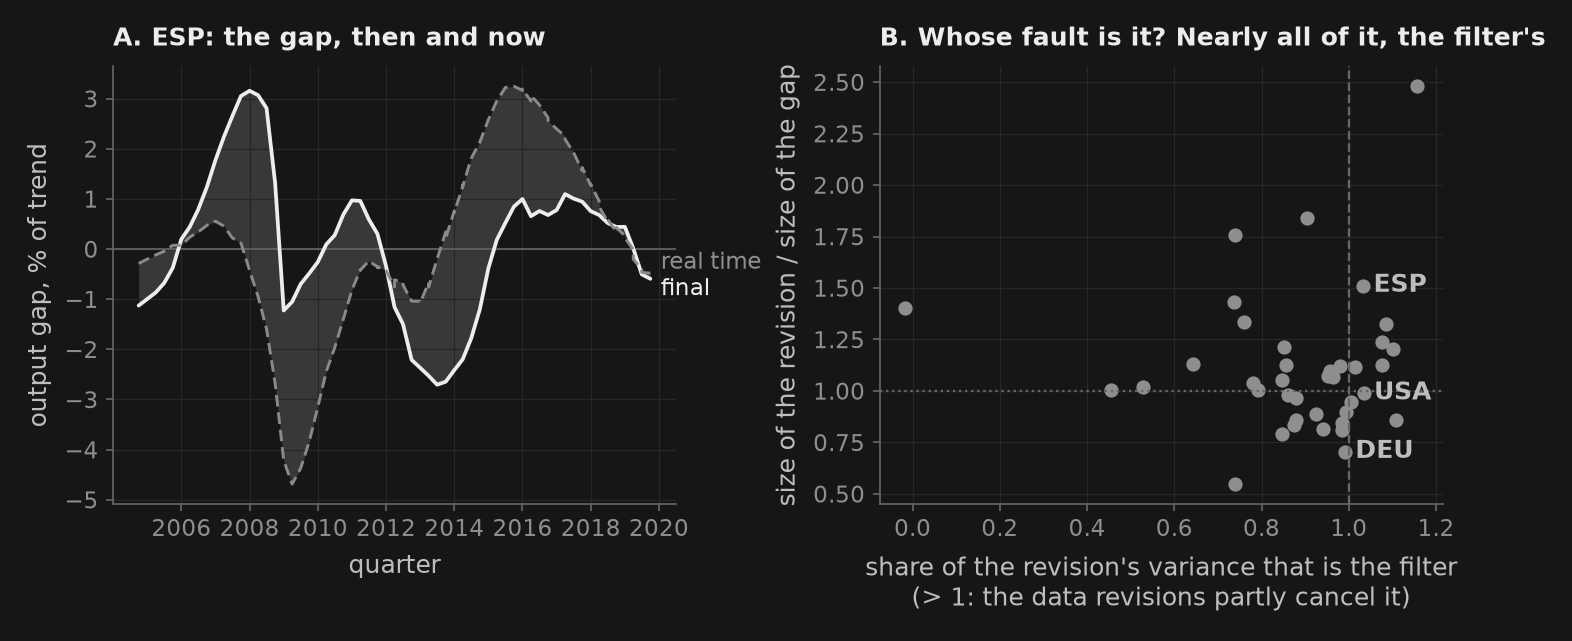

In [34]:
fig, (ax1, ax3) = _nbstyle.figura(1, 2)

FOCO = "ESP" if "ESP" in set(rt["code"]) else sorted(set(rt["code"]))[0]
one = rt[rt["code"] == FOCO].sort_values("date")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax1.plot(one["date"], one["final"], color=cols[0], lw=1.8, label="final")
ax1.plot(one["date"], one["rt"], color=cols[3], lw=1.4, ls=(0, (4, 2)), label="real time")
ax1.fill_between(one["date"], one["rt"], one["final"], color=_nbstyle.BANDA, lw=0, zorder=0)
ax1.set_ylabel("output gap, % of trend"); ax1.set_xlabel("quarter")
ax1.set_title(f"A. {FOCO}: the gap, then and now")

ax3.scatter(ov["share end-point"], ov["noise/signal"], s=34, color=_nbstyle.NOTA,
            zorder=2)
# Only the three countries outside the central cluster get a name; the rest
# would not be legible among 39 dots.
for code in ("USA", "ESP", "DEU"):
    if code in ov.index:
        ax3.annotate(code, (ov.loc[code, "share end-point"],
                            ov.loc[code, "noise/signal"]),
                     xytext=(5, -3), textcoords="offset points",
                     color=_nbstyle.TEXTO, fontweight="bold")
ax3.axvline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.1)
ax3.axhline(1.0, color=_nbstyle.SPINE, ls=":", lw=1.1)
ax3.set_xlabel("share of the revision's variance that is the filter\n"
               "(> 1: the data revisions partly cancel it)")
ax3.set_ylabel("size of the revision / size of the gap")
ax3.set_title("B. Whose fault is it? Nearly all of it, the filter's")
_nbstyle.etiquetar(ax1, donde="fin", fuera=True)
plt.show()


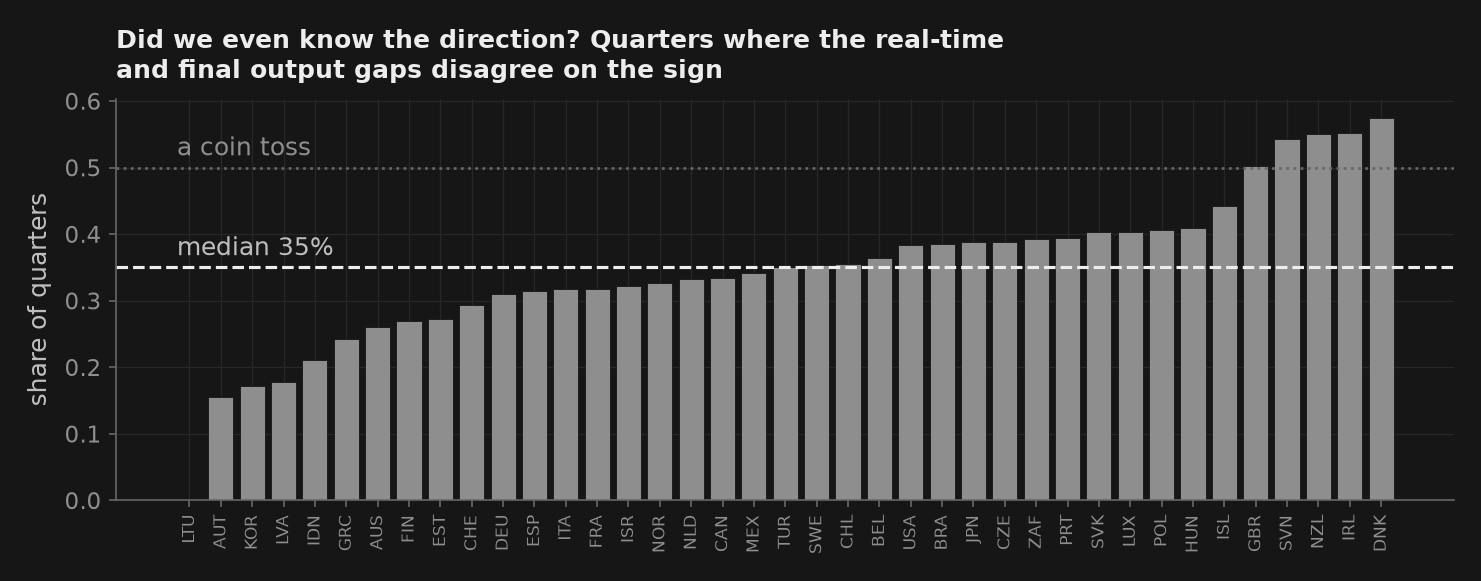

In [35]:
fig, ax = _nbstyle.figura(figsize="ancho")
o = ov.sort_values("wrong sign")
x = np.arange(len(o))
ax.bar(x, o["wrong sign"], color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.4)
med = float(o["wrong sign"].median())
ax.axhline(med, color=cols[0], ls="--", lw=1.5)
ax.axhline(0.5, color=_nbstyle.SPINE, ls=":", lw=1.3)
ax.set_xticks(x); ax.set_xticklabels(o.index, rotation=90, fontsize=8.4)
ax.set_ylabel("share of quarters")
ax.set_title("Did we even know the direction? Quarters where the real-time\n"
             "and final output gaps disagree on the sign")
# The two lines, named at their left end (where the bars are low).
ax.annotate(f"median {med:.0%}", xy=(x[0] - 0.4, med), xytext=(0, 3),
            textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TEXTO)
ax.annotate("a coin toss", xy=(x[0] - 0.4, 0.5), xytext=(0, 3),
            textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
plt.show()


### What §6 does to §1-§5

It does not undo them. The facts in §4 are computed on the final data and they are the right facts to ask a model to reproduce, because a model is a statement about the economy and not about the statistical office. But it settles the question of what those facts were worth *at the time*, and the answer is: much less than the confidence with which they were quoted.

Three things to carry forward:

1. **The gap is not observable.** The median economy's real-time output gap is revised by **1.05 times its own standard deviation** — the correction is bigger than the thing being corrected —, correlates 0.53 with the final estimate and disagrees with it about the *sign* 35% of the time. A policy rule with the output gap on the right-hand side is a rule with a coin toss in it, which is exactly Orphanides' (2001) reading of the Great Inflation: the Fed of the 1970s was not misreading its own model, it was reading a gap that later turned out not to have been there.
2. **Blame the filter, not the statisticians.** The variance of the revision splits **92 / 8** between the filter's end point and the data, in the median economy — and in ten areas the data share is *negative*, meaning revisions to GDP on average push the estimated gap back towards the answer we now believe, partly cancelling the filter's error rather than adding to it. The mechanism is easy to see: the HP trend at the end of a sample has no future to lean on, so it is fitted to the last few observations and moves every time one arrives. T01_B §4.1 showed GDP revisions themselves are small — a median standard deviation under one percentage point of quarterly growth; it is the *filter* that turns something that small into a gap that swings. That 8% is also the honest version rather than the flattering one: dropping the raw editions instead of adjusting them deletes exactly the estimates where the data weigh most — 1.35 pp of data revision against 0.83 pp on the ones that stay — and so shrinks the half credited to the statistician. Hamilton's critique in §3 was about spurious dynamics. This is the other, more expensive problem with the same filter, and unlike the first it is not a matter of taste.
3. **The two problems are separable, and only one of them is fixable by better data.** Which is the case for real-time evaluation of any detrending method — and the reason `puremacro` keeps the vintages rather than the latest series.

## 7. Exercises
1. **The denominator.** Recompute §2's growth accounting with $Y/E$ in place of $Y/H$ — that is, fold `g_hours` into productivity. (a) Which countries' productivity growth changes most, and what do they have in common? (b) Germany's hours per worker fell 0.46% a year. Over the 25-year sample, how much of the "German productivity miracle" is that term? (c) Why is $Y/E$ the *right* measure for some questions? Name one.
2. **Repair or drop.** §1.2 repairs Chile and Costa Rica with factors of 13 and 1/4. (a) Show that the two repaired working weeks agreeing to within an hour is genuine evidence and not something the procedure forced — what would you have seen if the factor had been wrong? (b) A colleague says the safe thing is to drop both countries. What exactly is lost, and what is the cost of the alternative error — leaving Chile in unrepaired? Quantify the second: what does unrepaired Chile do to §2's cross-country distribution of productivity growth?
3. **Filters.** (a) Redo §3 with $\lambda = 6.25$ and $\lambda = 129{,}600$. Does the *sign* count (28 of 31) change? (b) Vary Hamilton's horizon $h$ (4, 8, 12): what happens to the warm-up loss and to the amplitude of the cycle? (c) Portugal and New Zealand are the two countries whose answer depends on the filter. Look at their series and say which filter you would trust for each, and why "use them all and report the spread" is not a cop-out.
4. **Spain.** §5 shows Spanish measured productivity rising 7.2 log points during a recession that cost 12.9 log points of employment. (a) Write down a two-sector model — construction with low productivity, everything else with high — and show algebraically that destroying construction jobs raises measured aggregate $Y/H$ with no change in either sector's productivity. (b) What would you need from T01_B's `qna_produccion.csv` to measure how much of the 7.2 is this composition effect? (c) Is the remainder "real" productivity growth?
5. **The 2020 cut.** Set `HASTA = None` and rerun §4. $\sigma(c)/\sigma(y)$ rises everywhere and several countries cross 1; the spectral band share falls. Explain both, and then make the harder argument: is there a principled reason to include 2020 in a business cycle statistic, or is excluding it a choice we should be uncomfortable with?
6. **Government and measured productivity.** §1.3 claims general government value added has ~zero measured productivity growth by construction. (a) Explain the SNA convention that makes this true. (b) The raw cross-country correlation between `va_public`'s share and productivity growth is $-0.39$ in this panel. Give two reasons that is not evidence for the claim. (Hint: which countries in this panel have both small governments and large productivity growth, and why?) (c) Design a test that would be evidence, and say what data it needs that we do not have.
7. **Okun.** §5.1 estimates $\tilde{u}_t = \alpha + \beta\,\tilde{y}_t$ for 34 countries and finds $\beta$ negative in all 34, with a median of $-0.25$ and Spain at $-0.91$. (a) The correlation between $\beta$ and $\sigma(E)/\sigma(Y)$ is $-0.42$. Explain why that is *almost* a tautology — and then identify the part that is not, by writing $E = (1-u)\,L$ and asking what a country does with $L$. Name two countries in the table whose $\beta$ is flat *despite* a violent employment margin, and say what happened to their labour force. (b) New Zealand has the panel's largest $\sigma(E)/\sigma(Y)$ at $1.59$ and one of the flattest Okun coefficients. Given §3's diagnosis of its hours series, would you report that as a finding about New Zealand? (c) Redo §5.1 with the unemployment rate from T01_B's labour block instead of `oecd_urate_q.csv`. The median $R^2$ falls from $0.43$ to about $0.21$ and Spain's $\beta$ moves. Which of those two changes is evidence that the shorter sample is worse, and which is not?
8. **Real time.** (a) In §6, why does truncating *final* data at $t$ (the quasi-real-time gap) already produce most of the revision? Draw the HP trend near the end of a sample to see it. (b) Would the Hamilton filter do better in real time? Predict first, then test it by swapping `hp_filter` for `hamilton_filter` in §6. (c) The archive's vintage dates are OECD ingestion months, not national release dates (T01_B §4.1). Does that bias the real-time exercise, and in which direction? (d) §6 deseasonalizes the archive's 11,503 editions with T01_B §4.1's quarterly-dummy filter. Replace it with `drop_unadjusted_editions` — the previous treatment, which drops the 501 flagged ones — and rerun the section: the sample falls from 6,945 estimates to 6,796 and the variance split moves from 92/8 to 95/5 in the median economy. Explain why dropping moves the split *towards the filter* precisely when what it drops are the contaminated editions, and say which of the two numbers you would report.
9. **Stocks.** `volumen("inv", ...)` is gross fixed capital formation; `volumen("capform", ...)` adds inventories. Redo $\sigma(i)/\sigma(y)$ with the second. Why does it rise, and why does T01_B nevertheless write the identity with `capform`?
10. **Put §5 and §6 together.** Rebuild §5's peak-to-trough decomposition for Germany using only the data available in 2009Q4. Would you have known, in real time, that Germany was hoarding labour rather than suffering a productivity collapse?
11. **Beveridge: Shimer's filter and the direction of the loop.** (a) Repeat §5.2's $\sigma(\tilde\theta)/\sigma(\tilde y)$ with $\lambda = 10^5$ — Shimer's (2005): `hp_filter(x, lamb=1e5)` — for the 20 countries, and then against §2's productivity $Y/H$ instead of output, for the ones with hours. Does the median change, and in which direction? Why does a larger $\lambda$ move $\theta$ more than output? (b) Compute the signed area of each country's $(\log u, \log v)$ path — the shoelace formula, $\tfrac12\sum_t (x_t y_{t+1} - x_{t+1} y_t)$ closing the polygon — on the HP cycles before 2020 and on the 2019Q4–2023Q4 levels. In how many countries is it positive (counterclockwise)? Does it agree, country by country, with §5.2's asymmetry $\mathrm{corr}(\tilde v_t,\tilde u_{t+1}) < \mathrm{corr}(\tilde v_t,\tilde u_{t-1})$, and what do the countries where it does not have in common?
12. **Phillips: did it flatten, and with which price index?** (a) §5.3 finds that the median $\kappa$ goes from $-0.55$ to $-0.19$ between 1995–2007 and 2010–2019, but that only 18 of 31 countries flatten and 13 steepen. Explain how the median can flatten without the panel doing so, and why the median change *within* each country ($+0.20$) is the honest statistic. (b) Remove the $|\pi|>25$ rule and redo the count. What part of the fact survives, and what does it say about a fact that moves with a handful of country-quarters? (c) Redo the level curve for the United States with `CPIAUCSL.csv` (quarterly mean of the monthly index) in year-on-year inflation, $100\log(P_t/P_{t-4})$, on both sides. How much does $\kappa$ change? Separate the part of the change that is the basket from the part that is going from quarterly to year-on-year.
13. **The sacrifice ratio and the factor it is missing.** The textbook accelerationist ratio, $1/(4\kappa\beta)$ point-years per permanent point, assumes $\pi_t = \pi_{t-1} + \kappa\tilde u_t$. With §5.3's expectation, $\bar\pi$ = the mean of four lags, (a) write the polynomial $1 - \tfrac14(L + L^2 + L^3 + L^4)$, factor out $(1-L)$ and compute how much inflation falls *permanently* per accumulated point-quarter of $\pi - \bar\pi$; check it by simulating a constant $\tilde u$ for 40 quarters. What does that do to §5.3's median of 2.4 point-years? (b) Now set $\rho = 0.36$ instead of 1. How much does inflation fall with a permanent gap, and what happens when the gap closes? Whose sacrifice ratio is it then: the economy's or the anchor's?

14. **The United States in §3 and §4, now that it is possible.** §1.4 establishes that the `OUTNFB/HOANBS` pair measures the same concept as the panel's market sector, which removes §1.3's objection to putting it in the quarterly tables. (a) Build the **quarterly** market sector for the panel — the labour block now carries `hours_agri` and `hours_public`, and `produccion()` carries `va_agri` and `va_public` — and remember that an aggregate's real value added is not the sum of its parts' volumes: use a Törnqvist index with nominal shares. (b) Recompute §3's table on that concept and place the United States in it with its own BLS pair. Is it still the most countercyclical economy in the panel, as §1.3 said the splice would make it look? (c) The panel median barely moves when the concept changes while almost everyone's *mean* productivity rises (§1.4). Explain why a composition change can move a mean a great deal and a cyclical correlation almost not at all. (d) Japan cannot enter here by any route. Say what would be needed — which series, published by whom, at what frequency — and why building it from the Japanese labour force survey would not be the same thing.

## 8. Explore with AI
Try these with the offline tutor (or any AI assistant):
- "Why did Hamilton (2018) argue against the HP filter? Give the intuition in one sentence."
- "If measured productivity rises during a recession, name three explanations and say which one leaves technology alone."
- "Why is the end-point problem of the HP filter worse than the data revisions for a real-time output gap?"
- "Okun, Beveridge and Phillips are three statements about the same employment margin. Say in one sentence what question each one answers, and why the slope of the Beveridge curve is not enough to predict Okun's coefficient."

In [36]:
print(tutor("Measured labour productivity rose in Spain during the 2008-2011 "
            "recession while employment fell 13%. Explain in two sentences why "
            "that is a composition effect rather than technical progress."))

[offline tutor] No local LLM engine is installed on this machine. Install one with `pip install "puremacro[local-llm]"` along with a small model (for example via Ollama or MLX), or use the AI-exploration questions below with your preferred assistant. The rest of the notebook works without the tutor.
(engine detail: LocalLLMUnavailable)


**Summary.** We measured labour input from the accounts that measure GDP — repairing two countries whose hours arrived on the wrong time base, and naming the two economies the flow does not cover instead of splicing them in — and built output per hour for 31 countries. Growth split exactly into three margins, and the split turned out to be the interesting object: Mexico grew on employment with negative productivity growth, Czechia on productivity with none. We then asked whether the detrending filter changes an answer rather than a number: it moves $\mathrm{corr}(Y, Y/H)$ by up to 0.59 but flips its sign in only two of 31 countries, so procyclical productivity survives Hamilton's critique — while Spain's *countercyclical* productivity survives it too, and §5 explained why in one line. The canonical cycle facts became a distribution over 31 countries rather than a list, with hours more volatile than heads everywhere. We took the Great Recession apart country by country and found Germany losing it through hours with employment rising, Spain through 13 log points of employment with measured productivity rising 7. Okun's law compressed that margin mix into one number — $\beta$ negative in 34 of 34 countries, median $-0.25$, Spain $-0.91$ — and the other two labour-market curves said how that unemployment is produced and what it buys: tightness $v/u$ is 11 times as volatile as output across 20 countries, two thirds of it vacancies, which fall a quarter before unemployment rises, and the slope of the Beveridge curve does not predict Okun's coefficient; the accelerationist Phillips curve is not there ($\kappa<0$ in 14 of 34 countries) because expectations are anchored ($\rho = 0.36$), the level one is (30 of 34, median $-0.55$), and one point-year of disinflation costs 5.3 point-years of output gap in the median country. And then we asked whether any of it was knowable at the time: on T01_B's real-time archive — deseasonalized edition by edition with the same filter as that lesson, rather than trimmed — the median economy's output gap is revised by 1.05 times its own standard deviation, disagrees with the final estimate about the *sign* 35% of the time, and 92% of that variance is the filter's end point rather than the statisticians. **Next module:** the neoclassical growth model by value function iteration.